# 🏭 Copiloto IA B2B — Procesamiento Inteligente de Pedidos · **V3**

**Tesis MIA Aplicada — Universidad de las Américas (UDLA), 2026**
**Autores:** Mateo Córdova · Juan Portero
**Estado:** PoC consolidado V3 — incorpora todas las observaciones docentes del 27 abril 2026

---

## 🆕 Novedades de la versión V3

Esta versión consolida los cambios del refactor V2 (Sub-Fase 1.4) y adicionalmente **resuelve las 11 observaciones del tutor académico** documentadas en `REVISION-CAPSTONE-IA-PEDIDOS-001`:

| # | Observación | Solución V3 |
|---|---|---|
| 01 | Política confianza ↔ revisión | ✅ Filtro determinístico `UMBRAL_CONFIANZA_AUTOMATICA` |
| 02 | Métrica ignora cantidad | ✅ Métrica dual: F1 identificación + F1 transaccional + MAE cantidad |
| 03 | Híbrido no es 50/50 | ✅ `BuscadorHibridoRRF` con Reciprocal Rank Fusion |
| 04 | Rewriter pierde números técnicos | ✅ Prompt V2 con heurísticas léxicas + 4 ejemplos |
| 05 | Memoria HITL "sin cuestionar" | ✅ Umbral similitud 0.85 + top_k=3 + reformulación |
| 06 | Feedback HITL pierde texto VLM | ✅ Resuelto en refactor anterior — confirmado |
| 07 | HTML sin escape | ✅ Resuelto vía `gr.DataFrame` — confirmado |
| 08 | Métricas inconsistentes | ✅ Una sola fuente: `metricas_oficiales_v*.json` |
| 09 | README ↔ código desalineados | ✅ Resuelto en documentación — confirmado |
| 10 | Lenguaje "bypass PII" | ✅ Reformulado bajo principio GDPR Art. 5(1)(c) |
| 11 | Memoria vs fine-tuning | ✅ Distinción explícita — confirmado |

## Mejoras avanzadas adicionales (no pedidas pero sumadas)

- 🧪 **Suite de tests pytest-style** (8 tests críticos integrados como celda).
- 🔍 **Categorización automática de errores** (alucinación / derivación innecesaria / cantidad incorrecta / no detectó ítem).
- 📊 **Ablation V3** que re-evalúa el sistema con todas las mejoras y produce comparativo V1 → V2 → V3.
- 📁 **Renombrado** `dataset_finetuning_hitl.jsonl` → `historial_correcciones_hitl.jsonl` (alineamiento semántico con OBS-11).

## Pipeline (alto nivel)

```
[Texto / Imagen / PDF / Excel]
       ↓
  Router Multi-formato
       ↓
  Query Rewriter V2 (preserva números técnicos)
       ↓
  Búsqueda Híbrida RRF (50/50 verdadero)
       ↓
  LLM + CoT + Memoria HITL (con umbral)
       ↓
  Validación Transaccional + Filtro Confianza Determinístico
       ↓
  JSON estructurado → ERP / HITL
```

## Métricas oficiales esperadas (V3)

Las métricas del Ablation V3 se cargan dinámicamente desde `metricas_oficiales_v3.json` cuando el run finaliza. Las cifras de V1 y V2 son históricas y persisten para comparación.

| Configuración | F1 Identificación | F1 Transaccional | Latencia |
|---|---|---|---|
| GPT-4o + Prompt V2 + RRF + Filtro Confianza (V3) | _se calcula_ | _se calcula_ | _se calcula_ |
| GPT-4o + Prompt V2 (V2 baseline) | 0.7667 | _no medido_ | 3.12s |
| GPT-4o + Prompt V1 (V1 baseline) | 0.6633 | _no medido_ | 3.51s |


In [ ]:
# @title 📦 1. Setup del Entorno (Solo Colab) — V4 Definitiva
# ==============================================================================
# CELDA 1: INSTALACIÓN DE DEPENDENCIAS (TODA LA STACK DEL PROYECTO)
# ------------------------------------------------------------------------------
# Verificación post-instalación con importlib.util.find_spec().
# Resuelve el problema histórico de Colab donde pip reporta éxito pero
# algunos paquetes no quedan disponibles para el kernel.
# ==============================================================================
import subprocess
import sys
import importlib.util


def _instalar_binarios_sistema() -> None:
    print("🔧 Instalando binarios de sistema (Tesseract + Poppler)...")
    subprocess.run(
        ["apt-get", "install", "-y",
         "tesseract-ocr", "tesseract-ocr-spa",
         "poppler-utils"],
        check=False,
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )


PAQUETES_PYTHON = [
    "langchain==0.3.27",
    "langchain-core==0.3.78",
    "langchain-openai==0.3.34",
    "langchain-community==0.3.27",
    "faiss-cpu>=1.8",
    "rank-bm25>=0.2.2",
    "tiktoken>=0.7",
    "pytesseract>=0.3.10",
    "opencv-python-headless>=4.8",
    "pydantic>=2.5,<3.0",
    "pydantic-settings>=2.1,<3.0",
    "gradio>=4.40",
    "pypdf>=4.0",
    "pdf2image>=1.17",
    "openpyxl>=3.1",
    "reportlab>=4.0",
]


PAQUETES_PARA_VERIFICAR = {
    "langchain":              "langchain",
    "langchain_core":         "langchain-core",
    "langchain_openai":       "langchain-openai",
    "langchain_community":    "langchain-community",
    "faiss":                  "faiss-cpu",
    "rank_bm25":              "rank-bm25",
    "tiktoken":               "tiktoken",
    "pydantic":               "pydantic",
    "pydantic_settings":      "pydantic-settings",
    "gradio":                 "gradio",
    "pypdf":                  "pypdf",
    "pdf2image":              "pdf2image",
    "openpyxl":               "openpyxl",
    "reportlab":              "reportlab",
}


def _instalar_paquetes_python() -> bool:
    print(f"\n🔧 Instalando {len(PAQUETES_PYTHON)} paquetes Python...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install",
         "--upgrade-strategy", "only-if-needed", *PAQUETES_PYTHON],
        capture_output=True, text=True,
    )
    if result.returncode == 0:
        for linea in result.stdout.splitlines():
            if linea.startswith("Successfully installed"):
                print(f"  {linea}")
                break
        return True
    else:
        print("❌ pip salió con error. Últimas líneas del STDERR:")
        print(result.stderr[-2000:])
        return False


def _verificar_instalacion():
    print("\n" + "=" * 60)
    print("🔍 VERIFICACIÓN POST-INSTALACIÓN (importlib.util)")
    print("=" * 60)
    faltantes = []
    for nombre_modulo, nombre_pip in PAQUETES_PARA_VERIFICAR.items():
        spec = importlib.util.find_spec(nombre_modulo)
        if spec is None:
            print(f"  ❌ {nombre_pip:<25} — NO ENCONTRADO")
            faltantes.append(nombre_pip)
        else:
            print(f"  ✅ {nombre_pip:<25} — OK")
    print("=" * 60)
    return len(faltantes) == 0, faltantes


_instalar_binarios_sistema()
pip_ok = _instalar_paquetes_python()
todos_ok, faltantes = _verificar_instalacion()

if todos_ok:
    print("\n" + "🎉 " * 15)
    print("✅ ENTORNO COMPLETO — TODAS LAS DEPENDENCIAS DISPONIBLES")
    print("🎉 " * 15)
    print("\n💡 Si Colab muestra banner amarillo de RESTART, hazlo y vuelve a Celda 2.")
else:
    print("\n" + "⚠️ " * 15)
    print(f"❌ FALTAN {len(faltantes)} PAQUETE(S): {faltantes}")
    print("⚠️ " * 15)
    print(f"\n🔧 SOLUCIÓN MANUAL: !pip install {' '.join(faltantes)}")


🔧 Instalando binarios de sistema (Tesseract + Poppler)...

🔧 Instalando 16 paquetes Python...

🔍 VERIFICACIÓN POST-INSTALACIÓN (importlib.util)
  ✅ langchain                 — OK
  ✅ langchain-core            — OK
  ✅ langchain-openai          — OK
  ✅ langchain-community       — OK
  ✅ faiss-cpu                 — OK
  ✅ rank-bm25                 — OK
  ✅ tiktoken                  — OK
  ✅ pydantic                  — OK
  ✅ pydantic-settings         — OK
  ✅ gradio                    — OK
  ✅ pypdf                     — OK
  ✅ pdf2image                 — OK
  ✅ openpyxl                  — OK
  ✅ reportlab                 — OK

🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 
✅ ENTORNO COMPLETO — TODAS LAS DEPENDENCIAS DISPONIBLES
🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 

💡 Si Colab muestra banner amarillo de RESTART, hazlo y vuelve a Celda 2.


In [ ]:
# @title ⚙️ 2. Configuración, Schemas y Orquestador  (V3)
# ==============================================================================
# CELDA 2: CONFIGURACIÓN GLOBAL + CONTRATOS DE DATOS
# ------------------------------------------------------------------------------
# CAMBIOS V3:
#   - Agregado UMBRAL_CONFIANZA_AUTOMATICA (resuelve OBS-01).
#   - Renombrado RUTA_DATASET_HITL → RUTA_HISTORIAL_HITL (semántica correcta).
# ==============================================================================
import os
import logging
from typing import Literal, Optional, List, Dict, Any
from pydantic import BaseModel, Field, ConfigDict
from pydantic_settings import BaseSettings, SettingsConfigDict


class AppSettings(BaseSettings):
    """Configuración del Copiloto IA B2B."""
    model_config = SettingsConfigDict(env_file=".env", extra="ignore")

    OPENAI_API_KEY: str = Field(default="")
    MODELO_LLM_PRINCIPAL: str = Field(default="gpt-4o")
    MODELO_LLM_VISION: str = Field(default="gpt-4o")
    MODELO_EMBEDDINGS: str = Field(default="text-embedding-3-small")

    # ── Hiperparámetros del retriever ──
    K_RETRIEVER: int = Field(default=15)
    K_MEMORIA_HITL: int = Field(default=3)              # ⬆ V3: 1 → 3 (OBS-05)
    UMBRAL_SIMILITUD_HITL: float = Field(default=0.85)  # 🆕 V3 (OBS-05)
    PESO_FAISS: float = Field(default=0.5)              # 🆕 V3 (OBS-03)
    PESO_BM25: float = Field(default=0.5)               # 🆕 V3 (OBS-03)
    RRF_K: int = Field(default=60)                      # 🆕 V3 (OBS-03)
    TEMPERATURA_LLM: float = Field(default=0.0)

    # ── Política de confianza determinística (OBS-01) ──
    UMBRAL_CONFIANZA_AUTOMATICA: Literal["Alta", "Media", "Baja"] = Field(
        default="Alta",
        description=(
            "Confianza mínima del LLM para automatizar al ERP. "
            "Cualquier valor por debajo dispara revisión humana determinística."
        ),
    )

    # ── Rutas ──
    RUTA_CATALOGO_CSV: str = Field(default="catalogo_erp_ideal.csv")
    RUTA_HISTORIAL_HITL: str = Field(                   # 🆕 renombrado (OBS-11)
        default="historial_correcciones_hitl.jsonl"
    )

    ENTORNO: Literal["colab", "local", "produccion"] = Field(default="colab")


def _cargar_api_key_colab(settings: AppSettings) -> AppSettings:
    if settings.OPENAI_API_KEY:
        return settings
    try:
        from google.colab import userdata
        api_key = userdata.get("OPENAI_API_KEY")
        if api_key:
            settings.OPENAI_API_KEY = api_key
            os.environ["OPENAI_API_KEY"] = api_key
    except (ImportError, Exception):
        pass
    return settings


settings = _cargar_api_key_colab(AppSettings())

if not settings.OPENAI_API_KEY:
    raise RuntimeError(
        "❌ OPENAI_API_KEY no encontrada. "
        "Configúrala en Colab Secrets, en .env, o como variable de entorno."
    )
os.environ["OPENAI_API_KEY"] = settings.OPENAI_API_KEY


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("copiloto_b2b")


# ─── Niveles de confianza ordenables ───
NivelConfianza = Literal["Alta", "Media", "Baja", "Alta (Humano)"]
NIVELES_CONFIANZA_ORDEN: Dict[str, int] = {
    "Baja": 1, "Media": 2, "Alta": 3, "Alta (Humano)": 4
}


def confianza_es_suficiente(confianza_reportada: str, umbral: str = None) -> bool:
    """
    Devuelve True si la confianza reportada cumple o excede el umbral configurado.
    Usado por el filtro determinístico en validar_inventario (OBS-01).
    """
    umbral = umbral or settings.UMBRAL_CONFIANZA_AUTOMATICA
    return (
        NIVELES_CONFIANZA_ORDEN.get(confianza_reportada, 0)
        >= NIVELES_CONFIANZA_ORDEN.get(umbral, 3)
    )


class PedidoIA(BaseModel):
    model_config = ConfigDict(extra="allow")
    analisis_previo: str = Field(default="")
    sku: str = Field(default="REVISION_MANUAL")
    cantidad_solicitada: int = Field(default=0, ge=0)
    confianza_ia: NivelConfianza = Field(default="Baja")
    razonamiento: str = Field(default="")
    estado_sistema: Optional[str] = Field(default=None)
    # 🆕 V3.3: trazabilidad input-output — fragmento del texto del cliente que generó este item
    texto_fuente: Optional[str] = Field(
        default=None,
        description="Fragmento del pedido del cliente que generó este item (trazabilidad UI)"
    )


class MetadatosOperativos(BaseModel):
    requiere_hitl: bool = False
    costo_usd: float = 0.0
    tokens_consumidos: int = 0
    error: Optional[str] = None
    latencia_segundos: float = 0.0


class RespuestaPipeline(BaseModel):
    pedidos: List[PedidoIA] = Field(default_factory=list)
    metadatos_operativos: MetadatosOperativos = Field(default_factory=MetadatosOperativos)


class OrquestadorPipeline:
    @staticmethod
    def validar_paso(variables_requeridas: List[str], modulo_actual: str, paso_previo: str) -> None:
        import inspect
        frame = inspect.currentframe().f_back
        ns = frame.f_globals if frame else {}
        faltantes = [var for var in variables_requeridas if var not in ns]
        if faltantes:
            raise RuntimeError(
                f"\n⛔ ALERTA DE SECUENCIA ROTA ⛔\n"
                f"Estás intentando ejecutar el '{modulo_actual}', "
                f"pero la memoria no encuentra los componentes: {faltantes}.\n"
                f"👉 SOLUCIÓN: Ejecuta primero la celda del '{paso_previo}' y reintenta."
            )


logger.info(f"✅ Configuración V3 cargada (Modelo: {settings.MODELO_LLM_PRINCIPAL})")
logger.info(f"   🔒 Umbral confianza automática: {settings.UMBRAL_CONFIANZA_AUTOMATICA}")
logger.info(f"   🔍 Pesos retriever: FAISS={settings.PESO_FAISS}, BM25={settings.PESO_BM25}")
logger.info(f"   🧠 Memoria HITL: top_k={settings.K_MEMORIA_HITL}, "
            f"umbral_similitud={settings.UMBRAL_SIMILITUD_HITL}")
logger.info(f"✅ Schemas Pydantic registrados: PedidoIA, MetadatosOperativos, RespuestaPipeline")


In [ ]:
# @title 📂 3. Generación del Catálogo Sintético (Simulación ERP)
# ==============================================================================
# CELDA 3: GENERACIÓN DE CATÁLOGO SINTÉTICO B2B
# ==============================================================================
import pandas as pd
import numpy as np
from typing import Tuple

OrquestadorPipeline.validar_paso(["settings", "logger"], "Módulo Catálogo", "Celda 2")


def generar_catalogo_b2b_con_stock(
    num_registros: int = 150,
    nombre_archivo: str = None,
    seed: int = 42,
) -> Tuple[pd.DataFrame, str]:
    nombre_archivo = nombre_archivo or settings.RUTA_CATALOGO_CSV
    np.random.seed(seed)

    categorias = {
        'Alambre de Púas': {
            'prefijo': 'ALM', 'unidades': 'Rollo',
            'jergas': ['pua', 'alambre de puas', 'pua perimetral',
                       'alambre para cercar', 'alambre con espinas', 'alambre espinoso']
        },
        'Malla Electrosoldada': {
            'prefijo': 'MLE', 'unidades': 'Plancha',
            'jergas': ['malla de construccion', 'malla soldada', 'parrilla',
                       'malla para hormigon', 'rejilla de metal', 'malla de acero']
        },
        'Postes de Concreto': {
            'prefijo': 'PST', 'unidades': 'Unidad',
            'jergas': ['poste de cemento', 'pilar', 'poste para cerca',
                       'poste para alambrado', 'viga de hormigon']
        },
        'Grapas Galvanizadas': {
            'prefijo': 'GRP', 'unidades': 'Caja',
            'jergas': ['grapas', 'clavos en U', 'grampas',
                       'sujetadores de alambre', 'grapas para cerca']
        },
        'Clavos de Acero': {
            'prefijo': 'CLV', 'unidades': 'Caja',
            'jergas': ['clavos', 'clavo corrugado', 'clavo para madera',
                       'clavos fuertes', 'puntillas de acero']
        }
    }

    calibres_o_tamanos = ['Fino', 'Estándar', 'Grueso', 'Calibre 12',
                          'Calibre 14', 'Alta Resistencia']
    datos = []

    for i in range(1, num_registros + 1):
        cat_nombre = np.random.choice(list(categorias.keys()))
        cat_info = categorias[cat_nombre]
        sku = f"{cat_info['prefijo']}-{1000 + i}"
        tamano = np.random.choice(calibres_o_tamanos)
        nombre_tecnico = f"{cat_nombre} {tamano} Tipo {np.random.randint(1, 5)}"
        jerga_base = np.random.choice(cat_info['jergas'])

        descripcion_jerga = np.random.choice([
            f"{jerga_base} {tamano.lower()}",
            f"{jerga_base} del tipo {tamano.lower()}",
            f"{jerga_base} de {tamano.lower()} (el normal)",
            f"{jerga_base} ({tamano.lower()})"
        ])

        precio = round(np.random.uniform(15.0, 250.0), 2)
        stock = int(np.random.choice(
            [0, np.random.randint(5, 50), np.random.randint(100, 500)],
            p=[0.1, 0.4, 0.5]
        ))

        datos.append({
            "SKU": sku, "Nombre_Tecnico": nombre_tecnico,
            "Categoria": cat_nombre, "Descripcion_Jerga": descripcion_jerga,
            "Unidad": cat_info['unidades'], "Precio_Referencia": precio,
            "Stock_Disponible": stock
        })

    df = pd.DataFrame(datos)
    df.to_csv(nombre_archivo, index=False, encoding='utf-8')

    n_agotados = int((df['Stock_Disponible'] == 0).sum())
    logger.info(f"✅ Catálogo generado: {num_registros} SKUs → {nombre_archivo}")
    logger.info(f"📊 Inventario: {n_agotados} agotados, {num_registros - n_agotados} disponibles")

    return df, nombre_archivo


df_catalogo, ruta_catalogo = generar_catalogo_b2b_con_stock(num_registros=150)
display(df_catalogo.head(5))


,SKU,Nombre_Tecnico,Categoria,Descripcion_Jerga,Unidad,Precio_Referencia,Stock_Disponible
0,GRP-1001,Grapas Galvanizadas Calibre 14 Tipo 3,Grapas Galvanizadas,grampas (calibre 14),Caja,155.68,43
1,PST-1002,Postes de Concreto Grueso Tipo 4,Postes de Concreto,viga de hormigon (grueso),Unidad,48.57,0
2,GRP-1003,Grapas Galvanizadas Alta Resistencia Tipo 2,Grapas Galvanizadas,clavos en U (alta resistencia),Caja,248.17,413
3,GRP-1004,Grapas Galvanizadas Fino Tipo 1,Grapas Galvanizadas,grampas de fino (el normal),Caja,108.97,32
4,PST-1005,Postes de Concreto Calibre 12 Tipo 3,Postes de Concreto,poste para alambrado (calibre 12),Unidad,124.69,406


In [ ]:
# @title 🔍 4. Buscador Híbrido RRF + Memoria HITL con Umbral  (V3)
# ==============================================================================
# CELDA 4: MOTOR DE RECUPERACIÓN HÍBRIDO + MEMORIA HITL
# ------------------------------------------------------------------------------
# CAMBIOS V3:
#   - OBS-03: Sustituida fusión heurística por Reciprocal Rank Fusion (RRF).
#     Referencia: Cormack et al., 2009. SIGIR'09.
#   - OBS-05: Memoria HITL ahora respeta umbral de similitud (0.85) y top_k=3.
#     Filtra lecciones que sean solo superficialmente parecidas.
# ==============================================================================
import json
from datetime import datetime
from pathlib import Path
from typing import List, Optional, Tuple

import pandas as pd
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

OrquestadorPipeline.validar_paso(
    ["settings", "logger", "df_catalogo"],
    "Módulo de Recuperación", "Celdas 2-3"
)


# =============================================================================
# 4.1 — BuscadorHibridoRRF (resuelve OBS-03)
# =============================================================================
class BuscadorHibridoRRF:
    """
    Buscador híbrido con Reciprocal Rank Fusion.

    Referencia académica:
        Cormack, G. V., Clarke, C. L. A., & Buettcher, S. (2009).
        "Reciprocal rank fusion outperforms Condorcet and individual rank
        learning methods". Proceedings of SIGIR'09, 758-759.

    Fórmula:
        score_RRF(d) = Σ_i  peso_i / (k + rank_i(d))

    donde rank_i(d) es la posición del documento d en el ranking del retriever i,
    y k=60 es el parámetro suavizador estándar de la literatura.

    Ventajas frente a fusión por orden de iteración (versión anterior):
      - No prioriza arbitrariamente FAISS sobre BM25.
      - Pesos parametrizables (default 50/50).
      - No requiere normalización de scores (RRF opera sobre rankings).
      - Estándar usado por Elasticsearch, OpenSearch, Pinecone, Vespa.
    """

    def __init__(
        self,
        faiss_retriever,
        bm25_retriever,
        top_k_final: int = 15,
        peso_faiss: float = None,
        peso_bm25: float = None,
        rrf_k: int = None,
    ):
        self.faiss_retriever = faiss_retriever
        self.bm25_retriever = bm25_retriever
        self.top_k_final = top_k_final
        self.peso_faiss = peso_faiss if peso_faiss is not None else settings.PESO_FAISS
        self.peso_bm25 = peso_bm25 if peso_bm25 is not None else settings.PESO_BM25
        self.rrf_k = rrf_k if rrf_k is not None else settings.RRF_K

        if abs(self.peso_faiss + self.peso_bm25 - 1.0) > 1e-6:
            raise ValueError(
                f"peso_faiss + peso_bm25 debe sumar 1.0; "
                f"recibido: {self.peso_faiss} + {self.peso_bm25}"
            )

    def invoke(self, query: str) -> List[Document]:
        docs_faiss = self.faiss_retriever.invoke(query)
        docs_bm25 = self.bm25_retriever.invoke(query)

        # Diccionarios de scoring y referencia
        scores: dict = {}
        docs_index: dict = {}

        # Aporte FAISS (peso × 1/(k+rank))
        for rank, doc in enumerate(docs_faiss):
            sku = doc.metadata.get("sku")
            if not sku:
                continue
            scores[sku] = scores.get(sku, 0.0) + self.peso_faiss / (self.rrf_k + rank)
            docs_index[sku] = doc

        # Aporte BM25
        for rank, doc in enumerate(docs_bm25):
            sku = doc.metadata.get("sku")
            if not sku:
                continue
            scores[sku] = scores.get(sku, 0.0) + self.peso_bm25 / (self.rrf_k + rank)
            if sku not in docs_index:
                docs_index[sku] = doc

        # Ordenar por score decreciente y truncar
        ranking_final = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        ranking_final = ranking_final[: self.top_k_final]

        # Telemetría útil para análisis
        skus_faiss = {d.metadata["sku"] for d in docs_faiss}
        skus_bm25 = {d.metadata["sku"] for d in docs_bm25}
        n_interseccion = len(skus_faiss & skus_bm25)
        n_solo_faiss = len(skus_faiss - skus_bm25)
        n_solo_bm25 = len(skus_bm25 - skus_faiss)
        logger.debug(
            f"[Retrieval RRF] query='{query[:60]}...' "
            f"intersección={n_interseccion}, "
            f"solo_faiss={n_solo_faiss}, solo_bm25={n_solo_bm25}, "
            f"total={len(ranking_final)}"
        )

        return [docs_index[sku] for sku, _ in ranking_final]


# Alias por retro-compatibilidad con código legacy del proyecto
BuscadorHibridoPersonalizado = BuscadorHibridoRRF


def inicializar_motor_busqueda_hibrido(
    df_erp: pd.DataFrame, top_k: Optional[int] = None
) -> BuscadorHibridoRRF:
    if df_erp is None or df_erp.empty:
        raise ValueError("El catálogo está vacío.")

    top_k = top_k or settings.K_RETRIEVER
    logger.info(
        f"Inicializando motor híbrido RRF "
        f"(top_k={top_k}, embeddings={settings.MODELO_EMBEDDINGS})..."
    )

    documentos = []
    for _, row in df_erp.iterrows():
        texto_vector = (
            f"SKU: {row['SKU']} | Producto Técnico: {row['Nombre_Tecnico']} | "
            f"Categoría: {row['Categoria']} | Jerga y Sinónimos: {row['Descripcion_Jerga']} | "
            f"Unidad de Venta: {row['Unidad']}"
        )
        documentos.append(Document(page_content=texto_vector, metadata={"sku": row['SKU']}))

    logger.info("Construyendo índice FAISS (semántico)...")
    embeddings = OpenAIEmbeddings(model=settings.MODELO_EMBEDDINGS)
    vectorstore = FAISS.from_documents(documentos, embeddings)
    faiss_retriever = vectorstore.as_retriever(search_kwargs={"k": top_k})

    logger.info("Construyendo índice BM25 (léxico)...")
    bm25_retriever = BM25Retriever.from_documents(documentos)
    bm25_retriever.k = top_k

    buscador = BuscadorHibridoRRF(
        faiss_retriever=faiss_retriever,
        bm25_retriever=bm25_retriever,
        top_k_final=top_k,
    )
    logger.info(
        f"✅ Motor híbrido RRF listo "
        f"({len(documentos)} productos · pesos {buscador.peso_faiss:.2f}/{buscador.peso_bm25:.2f})."
    )
    return buscador


# =============================================================================
# 4.2 — ServicioMemoriaHITL con umbral de similitud (resuelve OBS-05)
# =============================================================================
class ServicioMemoriaHITL:
    """
    Memoria HITL (In-Context Learning) con filtro de similitud y top_k.

    CAMBIOS V3 (OBS-05):
      - top_k = 3 (antes: 1) → el LLM ve variantes y puede decidir.
      - umbral_similitud = 0.85 (nuevo) → solo lecciones realmente cercanas.
      - Devuelve lista vacía cuando ninguna lección supera el umbral
        (la memoria NO debe contaminar inferencia con casos débilmente
         relacionados).
    """

    def __init__(
        self,
        ruta_jsonl: Optional[str] = None,
        top_k: Optional[int] = None,
        umbral_similitud: Optional[float] = None,
    ):
        self.ruta_jsonl = Path(ruta_jsonl or settings.RUTA_HISTORIAL_HITL)
        self.top_k = top_k if top_k is not None else settings.K_MEMORIA_HITL
        self.umbral_similitud = (
            umbral_similitud if umbral_similitud is not None
            else settings.UMBRAL_SIMILITUD_HITL
        )
        self._vectorstore: Optional[FAISS] = None
        self._cargar_si_existe()

    def _cargar_si_existe(self) -> None:
        if not self.ruta_jsonl.exists():
            logger.info(f"Memoria HITL: archivo no existe ({self.ruta_jsonl}). En blanco.")
            return

        try:
            lineas = self.ruta_jsonl.read_text(encoding="utf-8").splitlines()
            lineas = [l for l in lineas if l.strip()]
            if not lineas:
                logger.info("Memoria HITL: vacía.")
                return

            docs = []
            for linea in lineas:
                registro = json.loads(linea)
                docs.append(Document(
                    page_content=registro.get("input_crudo", ""),
                    metadata={"correccion_json": registro.get("ground_truth_humano")}
                ))

            embeddings = OpenAIEmbeddings(model=settings.MODELO_EMBEDDINGS)
            self._vectorstore = FAISS.from_documents(docs, embeddings)
            logger.info(
                f"✅ Memoria HITL: {len(docs)} correcciones históricas "
                f"(top_k={self.top_k}, umbral={self.umbral_similitud})."
            )
        except Exception as e:
            logger.error(f"Error cargando HITL: {e}")
            self._vectorstore = None

    def buscar_lecciones(self, texto_cliente: str) -> List[Tuple[Document, float]]:
        """
        Devuelve [(doc, similitud_estimada), ...] para hasta top_k lecciones
        que SUPEREN el umbral de similitud. Lista vacía si ninguna califica.

        Conversión distancia→similitud: similitud = 1 / (1 + distancia_L2).
        """
        if self._vectorstore is None:
            return []
        try:
            resultados = self._vectorstore.similarity_search_with_score(
                texto_cliente, k=self.top_k
            )
            lecciones_filtradas = [
                (doc, 1.0 / (1.0 + dist))
                for doc, dist in resultados
                if (1.0 / (1.0 + dist)) >= self.umbral_similitud
            ]
            return lecciones_filtradas
        except Exception as e:
            logger.warning(f"Error consultando HITL: {e}")
            return []

    def guardar_correccion(
        self, texto_cliente: str, prediccion_ia: str, correccion_humana: str
    ) -> bool:
        if not texto_cliente or not correccion_humana:
            return False

        registro = {
            "timestamp": datetime.now().isoformat(),
            "input_crudo": texto_cliente,
            "prediccion_ia": prediccion_ia,
            "ground_truth_humano": correccion_humana,
        }

        try:
            with open(self.ruta_jsonl, "a", encoding="utf-8") as f:
                f.write(json.dumps(registro, ensure_ascii=False) + "\n")
            self._cargar_si_existe()
            logger.info("✅ Corrección HITL guardada y memoria actualizada.")
            return True
        except Exception as e:
            logger.error(f"Error guardando HITL: {e}")
            return False

    @property
    def esta_activa(self) -> bool:
        return self._vectorstore is not None


retriever_hibrido = inicializar_motor_busqueda_hibrido(df_catalogo)
memoria_hitl = ServicioMemoriaHITL()
logger.info(f"📡 Memoria HITL: {'ACTIVA' if memoria_hitl.esta_activa else 'EN BLANCO'}")


In [ ]:
# @title 🧠 5. Pipeline Core V3: Rewriter V2 + Extractor V2 + Filtro Confianza
# ==============================================================================
# CELDA 5: PIPELINE DE INFERENCIA RAG  (V3)
# ------------------------------------------------------------------------------
# CAMBIOS V3:
#   - OBS-01: validar_inventario incluye filtro determinístico de confianza.
#   - OBS-04: PROMPT_REWRITER_V2 con heurísticas léxicas para preservar números
#             técnicos (calibre, tipo, pulgadas, mm, dimensiones).
#   - OBS-05: bloque de memoria HITL reformulado de "úsala sin cuestionar"
#             a "úsala como referencia y verifica que aplique".
#   - PROMPT_EXTRACTOR_V2 (ya calibrado anti over-conservatism) ahora es
#     el activo desde el inicio, sin necesidad de hot-swap.
# ==============================================================================
import time
from typing import Tuple

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_community.callbacks import get_openai_callback

OrquestadorPipeline.validar_paso(
    ["retriever_hibrido", "memoria_hitl", "df_catalogo", "confianza_es_suficiente"],
    "Pipeline Core V3", "Celdas 2-4"
)


# =============================================================================
# 5.1 — Singleton del LLM (sin cambios)
# =============================================================================
_llm_singleton: Optional[ChatOpenAI] = None

def obtener_llm(modelo: Optional[str] = None) -> ChatOpenAI:
    global _llm_singleton
    modelo_solicitado = modelo or settings.MODELO_LLM_PRINCIPAL
    if _llm_singleton is None or _llm_singleton.model_name != modelo_solicitado:
        _llm_singleton = ChatOpenAI(
            model=modelo_solicitado,
            temperature=settings.TEMPERATURA_LLM,
        )
        logger.debug(f"LLM instanciado: {modelo_solicitado}")
    return _llm_singleton


# =============================================================================
# 5.2 — PROMPT_REWRITER_V2 (resuelve OBS-04)
# =============================================================================
PROMPT_REWRITER_V2 = """Eres un experto en la industria del acero. Tu objetivo es \
purificar el texto del cliente para un motor de búsqueda vectorial.

REGLAS:
1. ELIMINA verbos de compra: "necesito", "cotiza", "quiero", "mándame", "despachen".

2. ELIMINA números SOLO cuando representen CANTIDADES DE COMPRA:
   - "12 rollos" → eliminar "12"
   - "5 cajas" → eliminar "5"
   - "necesito 20 unidades" → eliminar "20"

3. CONSERVA SIEMPRE los números que sean ATRIBUTOS TÉCNICOS DEL PRODUCTO:
   - calibres: "calibre 12", "calibre 14"
   - tipos: "tipo 4", "tipo 2"
   - dimensiones: "2 pulgadas", "10 mm", "5/8"
   - mallas: "malla 10x10"
   - referencias: "alambre 16AWG"

4. Si dudas si un número es cantidad o atributo, OBSERVA el contexto:
   - Si va seguido de unidad de venta (rollos, cajas, unidades, metros) → es CANTIDAD.
   - Si va seguido de "calibre", "tipo", "pulgadas", "mm", "x" → es ATRIBUTO.

EJEMPLOS:

Entrada: "Cotiza 12 grapas de calibre 14 y 5 postes tipo 4"
Salida:  "grapas calibre 14, postes tipo 4"

Entrada: "necesito 20 metros de malla 10x10 calibre 12"
Salida:  "malla 10x10 calibre 12"

Entrada: "10 rollos pua"
Salida:  "alambre pua"

Entrada: "8 unidades de tubo 2 pulgadas"
Salida:  "tubo 2 pulgadas"

Texto Original: "{pedido}"
Texto Técnico Limpio:"""

PROMPT_REWRITER = PROMPT_REWRITER_V2


def reescribir_query(texto_cliente: str) -> Tuple[str, float, int]:
    prompt = ChatPromptTemplate.from_template(PROMPT_REWRITER)
    chain = prompt | obtener_llm() | StrOutputParser()

    with get_openai_callback() as cb:
        try:
            texto_limpio = chain.invoke({"pedido": texto_cliente}).strip()
            return texto_limpio, cb.total_cost, cb.total_tokens
        except Exception as e:
            logger.warning(
                f"Query rewriter falló ({type(e).__name__}: {e}). "
                f"Fallback al texto original."
            )
            return texto_cliente, 0.0, 0


# =============================================================================
# 5.3 — Recuperación de contexto (sin cambios)
# =============================================================================
def recuperar_contexto(query_limpia: str, retriever) -> str:
    docs = retriever.invoke(query_limpia)
    if not docs:
        logger.warning(f"Retriever vacío para: '{query_limpia[:60]}...'")
        return "(catálogo vacío)"
    return "\n".join(doc.page_content for doc in docs)


# =============================================================================
# 5.4 — PROMPT_EXTRACTOR_V2 (calibrado, ya activo desde V3)
# =============================================================================
PROMPT_EXTRACTOR_V2 = """Eres un copiloto logístico B2B. Tu trabajo es equilibrar la \
eficiencia (automatizar SKUs correctos) con la seguridad (no adivinar si faltan datos).

CATÁLOGO RECUPERADO:
{contexto}

{memoria_hitl}

PEDIDO DEL CLIENTE: "{pedido}"

REGLAS DE AUDITORÍA (APLICA EN ORDEN ESTRICTO):

REGLA 0 [MEMORIA]: Si hay LECCIONES HISTÓRICAS arriba, úsalas como REFERENCIA y \
verifica que apliquen al caso actual. NO las apliques ciegamente: confirma que los \
atributos del pedido actual coincidan con los del caso histórico.

REGLA 1 [COINCIDENCIA POSITIVA — TU OBLIGACIÓN PRINCIPAL]:
  Si el cliente proporciona los atributos suficientes para identificar el producto en el \
catálogo (calibre, tipo, tamaño, etc.), DEBES asignar el SKU exacto.
  ⚠️ Esta regla NO es opcional: si los datos están, ASIGNA. No derivar a humano por \
exceso de cautela cuando la información sí está presente.

REGLA 2 [AMBIGÜEDAD GENUINA — solo si REGLA 1 no aplica]:
  Solo asigna "REVISION_MANUAL" cuando el catálogo exige un atributo obligatorio para \
distinguir entre variantes (ej. el catálogo tiene "Calibre 12" y "Calibre 14" del mismo \
producto, y el cliente NO especificó el calibre).
  Si el cliente especifica TODOS los atributos necesarios, NO es ambigüedad — es \
información completa que debes procesar.

REGLA 3 [VALIDACIÓN DE INDEPENDENCIA POR ÍTEM]:
  Cada ítem del pedido se evalúa de forma INDEPENDIENTE. La presencia de ambigüedad en \
un ítem NO contamina los otros.

REGLA 4 [CALIBRACIÓN DE CONFIANZA — CRÍTICA PARA POLÍTICA DE NEGOCIO]:
  Asigna confianza_ia con CALIBRACIÓN HONESTA:
  - "Alta": estás seguro del SKU; el cliente proveyó atributos completos y unívocos.
  - "Media": el SKU es probable pero hay alguna ambigüedad menor o atributo asumido.
  - "Baja": estás adivinando o el match es semántico pero no exacto.
  Esta calibración es CRÍTICA: el sistema deriva automáticamente a revisión humana \
cualquier ítem con confianza < "Alta", independientemente del SKU emitido.

REGLA 5 [TRAZABILIDAD INPUT-OUTPUT — V3.3]:
  Para cada ítem extraído, incluye el campo "texto_fuente" con la CITA EXACTA \
del fragmento del pedido del cliente que generó este ítem. Esto permite \
auditar visualmente qué leyó el sistema vs qué identificó en el catálogo.
  - Cita textual, no reformulada.
  - Si el ítem se infiere de múltiples partes del texto, cita la más relevante.
  - Si no puedes localizar el fragmento exacto, deja "texto_fuente": null.

EJEMPLO POSITIVO:
Pedido: "10 rollos de alambre pua calibre 14 y 5 cajas de grapas tipo 4"
Salida correcta: ambos van con confianza Alta y SKU exacto.
  Ítem 1 → texto_fuente: "10 rollos de alambre pua calibre 14"
  Ítem 2 → texto_fuente: "5 cajas de grapas tipo 4"

EJEMPLO DE AMBIGÜEDAD GENUINA:
Pedido: "10 rollos de alambre pua"
Salida correcta: SKU=REVISION_MANUAL (cliente NO especificó calibre).
  Ítem 1 → texto_fuente: "10 rollos de alambre pua"

FORMATO DE RESPUESTA ESTRUCTURADO (orden de llaves obligatorio):
{{"pedidos": [
    {{
        "analisis_previo": "Paso 1: ... Paso 2: ... Paso 3: ...",
        "sku": "SKU-EXACTO o REVISION_MANUAL",
        "cantidad_solicitada": X,
        "confianza_ia": "Alta/Media/Baja",
        "razonamiento": "Resumen corto.",
        "texto_fuente": "fragmento exacto del pedido del cliente"
    }}
]}}"""

PROMPT_EXTRACTOR = PROMPT_EXTRACTOR_V2


# =============================================================================
# 5.4 bis — Fallback de trazabilidad texto_fuente (V3.3)
# =============================================================================
def _extraer_fragmento_fuente_fallback(
    texto_cliente: str,
    cantidad: int,
    nombre_producto: str = "",
) -> str:
    """
    🆕 V3.3 — Fallback heurístico para inferir el fragmento del texto del cliente
    que generó un item específico, cuando el LLM NO emitió el campo texto_fuente.

    Estrategia:
      1. Busca la cantidad numérica en el texto.
      2. Si la encuentra, devuelve un span de ±35 caracteres alrededor.
      3. Si la cantidad no aparece literal (por ejemplo "una docena" en lugar
         de "12"), devuelve el texto completo en formato gris con marker
         "[texto completo]" para señalar al usuario que es aproximación.
    """
    import re
    if not texto_cliente:
        return "(sin texto fuente)"

    texto_norm = texto_cliente.strip()
    if cantidad and cantidad > 0:
        # Busca la cantidad como número aislado (rodeado de espacios o inicio/fin)
        patron = rf"\b{cantidad}\b"
        match = re.search(patron, texto_norm)
        if match:
            inicio = max(0, match.start() - 5)
            fin = min(len(texto_norm), match.end() + 60)
            fragmento = texto_norm[inicio:fin].strip()
            # Limpia bordes parciales (palabras cortadas)
            if inicio > 0 and not texto_norm[inicio - 1].isspace():
                fragmento = "..." + fragmento.split(" ", 1)[-1]
            return fragmento

    # Fallback: texto completo abreviado con marker
    if len(texto_norm) <= 100:
        return f"[aprox.] {texto_norm}"
    return f"[aprox.] {texto_norm[:97]}..."


# =============================================================================
# 5.5 — Construcción del bloque de memoria HITL (resuelve OBS-05)
# =============================================================================
def _construir_bloque_memoria(memoria, texto_cliente: str) -> str:
    """
    Construye el bloque de lecciones históricas para inyección en el prompt.

    V3: usa top_k=3 con umbral de similitud, y reformula la instrucción
    para evitar que el LLM aplique correcciones ciegamente (OBS-05).
    """
    lecciones = memoria.buscar_lecciones(texto_cliente)
    if not lecciones:
        return ""

    bloque = "\n[LECCIONES HISTÓRICAS RELEVANTES]\n"
    bloque += (
        "Las siguientes correcciones humanas pasadas tienen alta similitud "
        "con el pedido actual. Revísalas críticamente:\n\n"
    )
    for i, (doc, similitud) in enumerate(lecciones, 1):
        bloque += (
            f"  Lección {i} (similitud: {similitud:.2f}):\n"
            f"    Pedido pasado:    '{doc.page_content}'\n"
            f"    Corrección humana: {doc.metadata.get('correccion_json')}\n\n"
        )
    bloque += (
        "INSTRUCCIÓN: usa estas lecciones como REFERENCIA, no como verdad absoluta. "
        "Verifica que los atributos del pedido actual coincidan con los del caso "
        "histórico antes de aplicar la corrección. Si el caso actual difiere en "
        "calibre, tipo o cualquier atributo crítico, NO apliques la lección.\n"
    )
    return bloque


def inferir_pedido_estructurado(
    texto_cliente: str, contexto: str, memoria
) -> Tuple[dict, float, int]:
    bloque_memoria = _construir_bloque_memoria(memoria, texto_cliente)
    prompt = ChatPromptTemplate.from_template(PROMPT_EXTRACTOR)
    chain = prompt | obtener_llm() | JsonOutputParser()

    with get_openai_callback() as cb:
        resultado = chain.invoke({
            "contexto": contexto,
            "memoria_hitl": bloque_memoria,
            "pedido": texto_cliente,
        })
        return resultado, cb.total_cost, cb.total_tokens


# =============================================================================
# 5.6 — validar_inventario V3 con filtro determinístico (resuelve OBS-01)
# =============================================================================
def validar_inventario(
    pedidos_ia: List[dict],
    df_inventario: pd.DataFrame,
    umbral_confianza: Optional[str] = None,
) -> Tuple[List[PedidoIA], bool]:
    """
    Aplica reglas de validación sobre los pedidos extraídos por el LLM.

    Pipeline de filtros (en orden):
      1. Validación schema Pydantic.
      2. ⚠️ NUEVO V3: Filtro determinístico de confianza (OBS-01).
         Fuerza REVISION_MANUAL si confianza_ia < umbral configurado,
         INDEPENDIENTEMENTE del SKU emitido por el LLM.
      3. Si el LLM ya marcó REVISION_MANUAL, se respeta.
      4. Validación de existencia del SKU en catálogo (anti-alucinación).
      5. Validación de stock disponible.

    Args:
        pedidos_ia: lista de dicts emitidos por el LLM.
        df_inventario: DataFrame del catálogo con stock.
        umbral_confianza: opcional, por defecto settings.UMBRAL_CONFIANZA_AUTOMATICA.

    Returns:
        (pedidos_validados, requiere_hitl)
    """
    umbral = umbral_confianza or settings.UMBRAL_CONFIANZA_AUTOMATICA
    pedidos_validados = []
    requiere_hitl = False

    for item_dict in pedidos_ia:
        # Filtro #1: schema Pydantic
        try:
            item = PedidoIA.model_validate(item_dict)
        except Exception as e:
            logger.warning(f"Item malformado: {e}")
            item = PedidoIA(
                sku="REVISION_MANUAL", cantidad_solicitada=0,
                confianza_ia="Baja",
                razonamiento=f"JSON inválido: {e}",
                estado_sistema="❌ ERROR (JSON malformado)",
            )
            requiere_hitl = True
            pedidos_validados.append(item)
            continue

        # ─── FILTRO #2 (V3 — OBS-01): política determinística de confianza ───
        # Esta regla NO depende del LLM. Codifica la postura de alta precisión.
        if item.sku != "REVISION_MANUAL" and not confianza_es_suficiente(
            item.confianza_ia, umbral
        ):
            logger.info(
                f"[Política confianza] SKU {item.sku} con confianza "
                f"'{item.confianza_ia}' < umbral '{umbral}'. → REVISION_MANUAL."
            )
            # Conservamos el SKU original en razonamiento (auditoría)
            item.razonamiento = (
                f"[Auto-derivado por política] SKU sugerido por LLM: {item.sku}. "
                f"Confianza '{item.confianza_ia}' < umbral '{umbral}'. "
                f"Razonamiento original: {item.razonamiento}"
            )
            item.sku = "REVISION_MANUAL"
            item.estado_sistema = (
                f"⚠️ REVISIÓN HUMANA (Confianza {item.confianza_ia} "
                f"< umbral {umbral})"
            )
            requiere_hitl = True
            pedidos_validados.append(item)
            continue

        # Filtro #3: el LLM ya marcó ambigüedad genuina
        if item.sku == "REVISION_MANUAL":
            item.estado_sistema = "⚠️ REVISIÓN HUMANA (Ambigüedad)"
            requiere_hitl = True
            pedidos_validados.append(item)
            continue

        # Filtro #4: existencia en catálogo (anti-alucinación)
        producto_db = df_inventario[df_inventario['SKU'] == item.sku]
        if producto_db.empty:
            logger.warning(f"LLM alucinó SKU inexistente: {item.sku}")
            item.razonamiento = (
                f"[Anti-alucinación] LLM emitió SKU inexistente: {item.sku}. "
                f"Razonamiento original: {item.razonamiento}"
            )
            item.sku = "REVISION_MANUAL"
            item.estado_sistema = "❌ ERROR (SKU Inexistente)"
            requiere_hitl = True
        else:
            # Filtro #5: stock disponible
            stock_real = int(producto_db.iloc[0]['Stock_Disponible'])
            if stock_real >= item.cantidad_solicitada:
                item.estado_sistema = "✅ APROBADO (Directo a ERP)"
            else:
                item.estado_sistema = f"❌ QUIEBRE DE STOCK (Disp: {stock_real})"
                requiere_hitl = True

        pedidos_validados.append(item)

    return pedidos_validados, requiere_hitl


# =============================================================================
# 5.7 — Orquestador principal (sin cambios estructurales)
# =============================================================================
def procesar_pedido(
    texto_cliente: str,
    retriever=None,
    df_inventario: Optional[pd.DataFrame] = None,
    memoria=None,
) -> RespuestaPipeline:
    retriever = retriever or retriever_hibrido
    df_inventario = df_inventario if df_inventario is not None else df_catalogo
    memoria = memoria or memoria_hitl

    t_inicio = time.time()
    costo_total = 0.0
    tokens_total = 0

    try:
        texto_limpio, c1, t1 = reescribir_query(texto_cliente)
        costo_total += c1; tokens_total += t1

        contexto = recuperar_contexto(texto_limpio, retriever)

        resultado_ia, c2, t2 = inferir_pedido_estructurado(
            texto_cliente, contexto, memoria
        )
        costo_total += c2; tokens_total += t2

        pedidos_validados, requiere_hitl = validar_inventario(
            resultado_ia.get("pedidos", []), df_inventario
        )

        return RespuestaPipeline(
            pedidos=pedidos_validados,
            metadatos_operativos=MetadatosOperativos(
                requiere_hitl=requiere_hitl,
                costo_usd=costo_total,
                tokens_consumidos=tokens_total,
                latencia_segundos=round(time.time() - t_inicio, 3),
            )
        )
    except Exception as e:
        logger.exception(f"Pipeline falló: '{texto_cliente[:80]}...'")
        return RespuestaPipeline(
            pedidos=[],
            metadatos_operativos=MetadatosOperativos(
                requiere_hitl=True, costo_usd=costo_total,
                tokens_consumidos=tokens_total,
                error=f"{type(e).__name__}: {e}",
                latencia_segundos=round(time.time() - t_inicio, 3),
            )
        )


# =============================================================================
# 🧪 SMOKE TEST
# =============================================================================
logger.info("Ejecutando smoke test del pipeline V3...")
_pedido_prueba = "Necesito 10 rollos de pua calibre 14 y 5 cajas de clavos calibre 14"
_resultado_test = procesar_pedido(_pedido_prueba)

print("\n" + "=" * 70)
print("🧪 SMOKE TEST DEL PIPELINE V3")
print("=" * 70)
print(f"📝 Pedido: {_pedido_prueba}")
print(f"⏱️  Latencia: {_resultado_test.metadatos_operativos.latencia_segundos}s")
print(f"💰 Costo: ${_resultado_test.metadatos_operativos.costo_usd:.5f}")
print(f"🔢 Tokens: {_resultado_test.metadatos_operativos.tokens_consumidos}")
print(f"📦 Pedidos extraídos: {len(_resultado_test.pedidos)}")
print(f"⚠️  Requiere HITL: {_resultado_test.metadatos_operativos.requiere_hitl}")
print(f"🔒 Umbral confianza activo: {settings.UMBRAL_CONFIANZA_AUTOMATICA}")
print("\nDetalle:")
for i, p in enumerate(_resultado_test.pedidos, 1):
    print(f"  [{i}] SKU={p.sku:<20} | Cant={p.cantidad_solicitada} | "
          f"Conf={p.confianza_ia:<15} | Estado={p.estado_sistema}")
print("=" * 70)



🧪 SMOKE TEST DEL PIPELINE V3
📝 Pedido: Necesito 10 rollos de pua calibre 14 y 5 cajas de clavos calibre 14
⏱️  Latencia: 6.302s
💰 Costo: $0.00927
🔢 Tokens: 2635
📦 Pedidos extraídos: 2
⚠️  Requiere HITL: True
🔒 Umbral confianza activo: Alta

Detalle:
  [1] SKU=REVISION_MANUAL      | Cant=10 | Conf=Media           | Estado=⚠️ REVISIÓN HUMANA (Ambigüedad)
  [2] SKU=REVISION_MANUAL      | Cant=5 | Conf=Baja            | Estado=⚠️ REVISIÓN HUMANA (Ambigüedad)


In [ ]:
# @title 💰 6. FinOps — Tracker de Costos y Calculadora de Producción
# ==============================================================================
# CELDA 6: OBSERVABILIDAD DE COSTO + ESTIMADOR DE PRODUCCIÓN
# ==============================================================================
from typing import Dict, List
from dataclasses import dataclass, field

OrquestadorPipeline.validar_paso(
    ["procesar_pedido", "RespuestaPipeline"],
    "Módulo FinOps", "Celda 5"
)


PRECIOS_OPENAI_USD_POR_MILLON: Dict[str, Dict[str, float]] = {
    "gpt-4o":              {"input": 2.50, "output": 10.00},
    "gpt-4o-mini":         {"input": 0.15, "output": 0.60},
    "text-embedding-3-small": {"input": 0.02, "output": 0.0},
    "text-embedding-3-large": {"input": 0.13, "output": 0.0},
}


@dataclass
class ContadorFinOps:
    pedidos_procesados: int = 0
    tokens_acumulados: int = 0
    costo_acumulado_usd: float = 0.0
    historial: List[float] = field(default_factory=list)

    def registrar(self, tokens: int, costo_usd: float) -> None:
        self.pedidos_procesados += 1
        self.tokens_acumulados += tokens
        self.costo_acumulado_usd += costo_usd
        self.historial.append(costo_usd)

    def reporte(self) -> str:
        if self.pedidos_procesados == 0:
            return "📊 Sin pedidos procesados todavía."
        avg_costo = self.costo_acumulado_usd / self.pedidos_procesados
        avg_tokens = self.tokens_acumulados / self.pedidos_procesados
        return (
            f"\n{'='*60}\n💰 REPORTE FINOPS — SESIÓN ACTUAL\n{'='*60}\n"
            f"  Pedidos procesados:      {self.pedidos_procesados:>10,}\n"
            f"  Tokens consumidos:       {self.tokens_acumulados:>10,}\n"
            f"  Costo total sesión:      ${self.costo_acumulado_usd:>10.4f} USD\n"
            f"  Tokens/pedido:           {avg_tokens:>10,.0f}\n"
            f"  Costo/pedido:            ${avg_costo:>10.5f} USD\n{'='*60}\n"
        )

    def reset(self) -> None:
        self.pedidos_procesados = 0
        self.tokens_acumulados = 0
        self.costo_acumulado_usd = 0.0
        self.historial = []


contador_finops = ContadorFinOps()

_procesar_pedido_original = procesar_pedido

def procesar_pedido_con_tracking(*args, **kwargs) -> RespuestaPipeline:
    respuesta = _procesar_pedido_original(*args, **kwargs)
    contador_finops.registrar(
        tokens=respuesta.metadatos_operativos.tokens_consumidos,
        costo_usd=respuesta.metadatos_operativos.costo_usd,
    )
    return respuesta

procesar_pedido = procesar_pedido_con_tracking


def calcular_costo_produccion(
    pedidos_por_mes: int,
    modelo: str = "gpt-4o",
    tokens_promedio_por_pedido: Optional[int] = None,
    proporcion_input: float = 0.75,
) -> Dict[str, float]:
    if modelo not in PRECIOS_OPENAI_USD_POR_MILLON:
        raise ValueError(f"Modelo '{modelo}' no soportado.")

    if tokens_promedio_por_pedido is None:
        if contador_finops.pedidos_procesados == 0:
            raise RuntimeError("No hay datos para promediar. Ejecuta el smoke test antes.")
        tokens_promedio_por_pedido = (
            contador_finops.tokens_acumulados / contador_finops.pedidos_procesados
        )

    precios = PRECIOS_OPENAI_USD_POR_MILLON[modelo]
    tokens_input = tokens_promedio_por_pedido * proporcion_input
    tokens_output = tokens_promedio_por_pedido * (1 - proporcion_input)

    costo_unitario = (tokens_input * precios["input"] + tokens_output * precios["output"]) / 1_000_000

    return {
        "modelo": modelo,
        "tokens_promedio": int(tokens_promedio_por_pedido),
        "costo_unitario_usd": costo_unitario,
        "costo_mensual_usd": costo_unitario * pedidos_por_mes,
        "costo_anual_usd": costo_unitario * pedidos_por_mes * 12,
    }


print(contador_finops.reporte())
print("\n💡 Tip: ejecuta procesar_pedido(...) y luego calcular_costo_produccion(N).")


📊 Sin pedidos procesados todavía.

💡 Tip: ejecuta procesar_pedido(...) y luego calcular_costo_produccion(N).


In [ ]:
# @title 🎲 7. Benchmark Generator V3 — Ground Truth con cantidades  (OBS-02)
# ==============================================================================
# CELDA 7: GENERADOR DEL DATASET DE EVALUACIÓN  (V3)
# ------------------------------------------------------------------------------
# CAMBIOS V3 (OBS-02):
#   - El ground truth ahora preserva CANTIDADES además de SKUs.
#   - Estructura: items_esperados es List[Tuple[sku, cantidad]].
#   - Permite evaluar tanto F1 de identificación como F1 transaccional.
# ==============================================================================
import random
import re
from dataclasses import dataclass, field

OrquestadorPipeline.validar_paso(
    ["df_catalogo", "settings"], "Generador de Benchmark V3", "Celdas 2-3"
)


@dataclass
class CasoBenchmark:
    """
    Caso de evaluación con ground truth.

    V3: items_esperados ahora preserva cantidad junto al SKU para evaluar
    validez transaccional completa, no solo identificación.
    """
    id: str
    pedido_crudo: str
    items_esperados: List[Tuple[str, int]]  # 🆕 V3: [(sku, cantidad), ...]
    n_items: int
    contiene_ruido: bool

    @property
    def skus_esperados(self) -> List[str]:
        """Compatibilidad con código V1/V2 que solo lee SKUs."""
        return [sku for sku, _ in self.items_esperados]


PATRONES_RUIDO_TECNICO = [
    r"\bcalibre\s+\d+\b",
    r"\btipo\s+\d+\b",
    r"\b(?:fino|grueso|estándar)\b",
    r"\bcalibre\s+\w+\b",
    r"\bde\s+(?:alta|baja)\s+resistencia\b",
]


def aplicar_chaos_monkey(
    texto: str, probabilidad: float = 0.5, rng: random.Random = None
) -> tuple:
    rng = rng or random
    if rng.random() > probabilidad:
        return texto, False

    hubo_cambio = False
    for patron in PATRONES_RUIDO_TECNICO:
        if re.search(patron, texto, re.IGNORECASE):
            texto = re.sub(patron, "", texto, flags=re.IGNORECASE)
            hubo_cambio = True
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto, hubo_cambio


def generar_benchmark(
    df_erp: pd.DataFrame,
    n_casos: int = 50,
    prob_chaos: float = 0.5,
    seed: int = 42,
) -> List[CasoBenchmark]:
    rng = random.Random(seed)
    df_disponible = df_erp[df_erp['Stock_Disponible'] > 0].reset_index(drop=True)
    if df_disponible.empty:
        raise ValueError("No hay productos con stock.")

    casos = []
    for i in range(n_casos):
        n_items = rng.choice([1, 1, 2, 2, 3])
        # 🆕 V3: registramos cantidades junto a los SKUs
        items_seleccionados: List[Tuple[str, int]] = []
        partes_pedido = []

        for _ in range(n_items):
            idx = rng.randint(0, len(df_disponible) - 1)
            row = df_disponible.iloc[idx]
            sku = row['SKU']
            cantidad = rng.randint(1, 25)
            items_seleccionados.append((sku, cantidad))
            partes_pedido.append(f"{cantidad} {row['Descripcion_Jerga']}")

        verbo = rng.choice(["Necesito", "Cotiza", "Por favor mándame", "Quiero", "Despachen"])
        pedido_limpio = f"{verbo} {' y '.join(partes_pedido)}"

        pedido_final, hubo_ruido = aplicar_chaos_monkey(pedido_limpio, prob_chaos, rng)

        if hubo_ruido:
            # En casos con ruido, el ground truth es REVISION_MANUAL para todos
            # los ítems del pedido. La cantidad pierde sentido como "esperado".
            items_esperados = [("REVISION_MANUAL", 0)] * n_items
        else:
            items_esperados = items_seleccionados

        casos.append(CasoBenchmark(
            id=f"BENCH-{i+1:03d}",
            pedido_crudo=pedido_final,
            items_esperados=items_esperados,
            n_items=n_items,
            contiene_ruido=hubo_ruido,
        ))

    return casos


benchmark = generar_benchmark(df_catalogo, n_casos=50, prob_chaos=0.5, seed=42)

n_con_ruido = sum(1 for c in benchmark if c.contiene_ruido)
print(f"✅ Benchmark V3 generado: {len(benchmark)} casos")
print(f"   📊 Con Chaos Monkey (ambigüedad): {n_con_ruido}")
print(f"   📊 Sin ruido: {len(benchmark) - n_con_ruido}")
print(f"\n📝 Muestra de 3 casos (con cantidades como ground truth):")
print("=" * 70)
for caso in benchmark[:3]:
    flag = "🌪️ Con ruido" if caso.contiene_ruido else "✨ Limpio"
    print(f"[{caso.id}] {flag}")
    print(f"  Pedido:      {caso.pedido_crudo}")
    print(f"  Esperado:    {caso.items_esperados}")
    print()


✅ Benchmark V3 generado: 50 casos
   📊 Con Chaos Monkey (ambigüedad): 26
   📊 Sin ruido: 24

📝 Muestra de 3 casos (con cantidades como ground truth):
[BENCH-001] 🌪️ Con ruido
  Pedido:      Por favor mándame 24 malla soldada del tipo
  Esperado:    [('REVISION_MANUAL', 0)]

[BENCH-002] 🌪️ Con ruido
  Pedido:      Despachen 22 clavos ()
  Esperado:    [('REVISION_MANUAL', 0)]

[BENCH-003] ✨ Limpio
  Pedido:      Cotiza 1 grapas para cerca de calibre 14 (el normal) y 7 grampas de calibre 14 (el normal)
  Esperado:    [('GRP-1011', 1), ('GRP-1030', 7)]



In [ ]:
# @title 📊 8. Evaluador V3 — Métrica Dual (Identificación + Transaccional)
# ==============================================================================
# CELDA 8: EVALUADOR MULTI-ETIQUETA POR CANASTA  (V3 — resuelve OBS-02)
# ------------------------------------------------------------------------------
# CAMBIOS V3:
#   - Métrica dual:
#       (a) F1 IDENTIFICACIÓN: solo SKU (compatible con V1/V2)
#       (b) F1 TRANSACCIONAL: SKU + cantidad (refleja validez real B2B)
#   - MAE de cantidad: error medio absoluto en unidades por SKU correctamente
#     identificado.
#   - Categorización automática de tipo de error (fortaleza adicional).
# ==============================================================================
from collections import Counter


def calcular_metricas_pedido_dual(
    items_esperados: List[Tuple[str, int]],
    items_predichos: List[Tuple[str, int]],
) -> Dict[str, float]:
    """
    Calcula DOS familias de métricas + MAE de cantidad.

    Args:
        items_esperados: [(sku, cantidad), ...] del ground truth.
        items_predichos: [(sku, cantidad), ...] de la predicción del pipeline.

    Returns:
        Dict con:
          - precision_id, recall_id, f1_id (solo SKU)
          - precision_tx, recall_tx, f1_tx (SKU + cantidad exacta)
          - mae_cantidad (error medio absoluto, en unidades)
    """
    # Casos borde
    if not items_esperados and not items_predichos:
        return _metricas_perfectas()
    if not items_esperados or not items_predichos:
        return _metricas_cero()

    # ─── Métrica 1: F1 de IDENTIFICACIÓN (solo SKU) ───
    skus_esp = Counter([sku for sku, _ in items_esperados])
    skus_pred = Counter([sku for sku, _ in items_predichos])
    tp_id = sum((skus_esp & skus_pred).values())
    p_id = tp_id / sum(skus_pred.values()) if skus_pred else 0.0
    r_id = tp_id / sum(skus_esp.values()) if skus_esp else 0.0
    f1_id = 2 * p_id * r_id / (p_id + r_id) if (p_id + r_id) > 0 else 0.0

    # ─── Métrica 2: F1 TRANSACCIONAL (SKU + cantidad exacta) ───
    pares_esp = Counter(items_esperados)
    pares_pred = Counter(items_predichos)
    tp_tx = sum((pares_esp & pares_pred).values())
    p_tx = tp_tx / sum(pares_pred.values()) if pares_pred else 0.0
    r_tx = tp_tx / sum(pares_esp.values()) if pares_esp else 0.0
    f1_tx = 2 * p_tx * r_tx / (p_tx + r_tx) if (p_tx + r_tx) > 0 else 0.0

    # ─── Métrica auxiliar: MAE de cantidad por SKU correctamente identificado ───
    errores_cantidad = []
    skus_comunes = set([s for s, _ in items_esperados]) & set([s for s, _ in items_predichos])
    for sku in skus_comunes:
        cant_esp = sum(c for s, c in items_esperados if s == sku)
        cant_pred = sum(c for s, c in items_predichos if s == sku)
        errores_cantidad.append(abs(cant_esp - cant_pred))
    mae_cantidad = (
        sum(errores_cantidad) / len(errores_cantidad)
        if errores_cantidad else 0.0
    )

    return {
        "precision_id": p_id, "recall_id": r_id, "f1_id": f1_id,
        "precision_tx": p_tx, "recall_tx": r_tx, "f1_tx": f1_tx,
        "mae_cantidad": mae_cantidad,
    }


def _metricas_perfectas() -> Dict[str, float]:
    return {
        "precision_id": 1.0, "recall_id": 1.0, "f1_id": 1.0,
        "precision_tx": 1.0, "recall_tx": 1.0, "f1_tx": 1.0,
        "mae_cantidad": 0.0,
    }


def _metricas_cero() -> Dict[str, float]:
    return {
        "precision_id": 0.0, "recall_id": 0.0, "f1_id": 0.0,
        "precision_tx": 0.0, "recall_tx": 0.0, "f1_tx": 0.0,
        "mae_cantidad": float("inf"),
    }


# ─── Compatibilidad con código antiguo ───
def calcular_metricas_pedido(
    skus_esperados: List[str], skus_predichos: List[str]
) -> Dict[str, float]:
    """Wrapper retro-compatible: devuelve solo F1 de identificación."""
    items_esp = [(sku, 1) for sku in skus_esperados]
    items_pred = [(sku, 1) for sku in skus_predichos]
    metricas = calcular_metricas_pedido_dual(items_esp, items_pred)
    return {
        "precision": metricas["precision_id"],
        "recall": metricas["recall_id"],
        "f1": metricas["f1_id"],
    }


# =============================================================================
# Categorización automática de errores (mejora avanzada)
# =============================================================================
def categorizar_error(
    items_esperados: List[Tuple[str, int]],
    items_predichos: List[Tuple[str, int]],
    contiene_ruido: bool,
) -> str:
    """
    Categoriza el tipo de error de un caso para análisis cualitativo.

    Categorías:
      - "acierto_perfecto"          → SKUs y cantidades coinciden
      - "acierto_solo_sku"          → SKUs OK, cantidad mal
      - "alucinacion_sku"           → predijo SKU que no estaba esperado
      - "derivacion_correcta"       → caso ambiguo correctamente derivado
      - "derivacion_innecesaria"    → caso claro derivado sin razón
      - "falla_no_deriva"           → caso ambiguo no derivado (riesgo alucinación)
      - "no_detecta_items"          → menos ítems predichos que esperados
      - "otro"
    """
    skus_esp = set([sku for sku, _ in items_esperados])
    skus_pred = set([sku for sku, _ in items_predichos])

    # Caso ambiguo (con ruido): el ground truth es REVISION_MANUAL
    if contiene_ruido:
        if "REVISION_MANUAL" in skus_pred:
            return "derivacion_correcta"
        else:
            return "falla_no_deriva"

    # Caso limpio
    if items_esperados == items_predichos:
        return "acierto_perfecto"

    if skus_esp == skus_pred:
        return "acierto_solo_sku"  # SKU OK, cantidad mal

    if "REVISION_MANUAL" in skus_pred and "REVISION_MANUAL" not in skus_esp:
        return "derivacion_innecesaria"

    if skus_pred - skus_esp - {"REVISION_MANUAL"}:
        return "alucinacion_sku"

    if len(items_predichos) < len(items_esperados):
        return "no_detecta_items"

    return "otro"


# =============================================================================
# Evaluador V3 (usa métrica dual)
# =============================================================================
def evaluar_modelo(
    benchmark: List[CasoBenchmark],
    nombre_run: str = "default",
    verbose: bool = True,
) -> Dict[str, Any]:
    resultados_por_caso = []
    f1_id_acum = 0.0; precision_id_acum = 0.0; recall_id_acum = 0.0
    f1_tx_acum = 0.0; precision_tx_acum = 0.0; recall_tx_acum = 0.0
    mae_cantidad_acum = 0.0; n_con_mae = 0
    costo_total = 0.0; tokens_total = 0; latencia_total = 0.0
    n_perfectos_id = 0; n_perfectos_tx = 0
    contador_categorias = Counter()

    if verbose:
        print(f"\n{'='*70}")
        print(f"🔬 EVALUANDO MODELO: {settings.MODELO_LLM_PRINCIPAL} (run: {nombre_run})")
        print(f"   Casos a procesar: {len(benchmark)}")
        print(f"   Métricas: dual (Identificación + Transaccional)")
        print(f"{'='*70}")

    t_inicio_run = time.time()

    for i, caso in enumerate(benchmark, 1):
        global _llm_singleton
        _llm_singleton = None  # forzar reinstanciación entre evaluaciones

        respuesta = _procesar_pedido_original(caso.pedido_crudo)

        # Construir items_predichos preservando cantidades
        items_predichos = [
            (p.sku, p.cantidad_solicitada)
            for p in respuesta.pedidos
        ]

        # Métricas duales
        metricas = calcular_metricas_pedido_dual(caso.items_esperados, items_predichos)
        f1_id_acum += metricas["f1_id"]
        precision_id_acum += metricas["precision_id"]
        recall_id_acum += metricas["recall_id"]
        f1_tx_acum += metricas["f1_tx"]
        precision_tx_acum += metricas["precision_tx"]
        recall_tx_acum += metricas["recall_tx"]

        mae = metricas["mae_cantidad"]
        if mae != float("inf") and mae >= 0:
            mae_cantidad_acum += mae
            n_con_mae += 1

        if metricas["f1_id"] == 1.0:
            n_perfectos_id += 1
        if metricas["f1_tx"] == 1.0:
            n_perfectos_tx += 1

        # Categorización del error
        categoria = categorizar_error(
            caso.items_esperados, items_predichos, caso.contiene_ruido
        )
        contador_categorias[categoria] += 1

        costo_total += respuesta.metadatos_operativos.costo_usd
        tokens_total += respuesta.metadatos_operativos.tokens_consumidos
        latencia_total += respuesta.metadatos_operativos.latencia_segundos

        resultados_por_caso.append({
            "caso_id": caso.id,
            "pedido": caso.pedido_crudo,
            "esperado": caso.items_esperados,
            "predicho": items_predichos,
            "contiene_ruido": caso.contiene_ruido,
            "metricas": metricas,
            "categoria_error": categoria,
            "latencia": respuesta.metadatos_operativos.latencia_segundos,
            "costo": respuesta.metadatos_operativos.costo_usd,
        })

        if verbose and i % 10 == 0:
            print(f"  Progreso: {i}/{len(benchmark)} | "
                  f"F1_id={f1_id_acum/i:.3f} | F1_tx={f1_tx_acum/i:.3f} | "
                  f"Costo: ${costo_total:.3f}")

    n = len(benchmark)
    metricas_agregadas = {
        "modelo": settings.MODELO_LLM_PRINCIPAL,
        "nombre_run": nombre_run,
        "n_casos": n,
        # F1 Identificación (compatible V1/V2)
        "f1_macro": f1_id_acum / n,            # alias retro-compatible
        "f1_id_macro": f1_id_acum / n,
        "precision_id_macro": precision_id_acum / n,
        "recall_id_macro": recall_id_acum / n,
        # F1 Transaccional (nuevo V3)
        "f1_tx_macro": f1_tx_acum / n,
        "precision_tx_macro": precision_tx_acum / n,
        "recall_tx_macro": recall_tx_acum / n,
        # Cantidades
        "mae_cantidad_promedio": mae_cantidad_acum / n_con_mae if n_con_mae > 0 else 0.0,
        # Tasas de acierto
        "tasa_acierto_perfecto_id": n_perfectos_id / n,
        "tasa_acierto_perfecto_tx": n_perfectos_tx / n,
        # Compatibilidad con campo antiguo
        "tasa_acierto_perfecto": n_perfectos_id / n,
        # Categorías de error
        "distribucion_errores": dict(contador_categorias),
        # Otros
        "n_casos_con_ruido": sum(1 for c in benchmark if c.contiene_ruido),
        "latencia_promedio_seg": latencia_total / n,
        "latencia_total_seg": time.time() - t_inicio_run,
        "costo_total_usd": costo_total,
        "costo_promedio_usd": costo_total / n,
        "tokens_totales": tokens_total,
        "tokens_promedio": tokens_total / n,
        "timestamp": datetime.now().isoformat(),
    }

    if verbose:
        print(f"\n{'='*70}")
        print(f"✅ Evaluación completada para {settings.MODELO_LLM_PRINCIPAL}")
        print(f"\n  📊 IDENTIFICACIÓN (solo SKU):")
        print(f"     F1 macro:        {metricas_agregadas['f1_id_macro']:.4f}")
        print(f"     Precision:       {metricas_agregadas['precision_id_macro']:.4f}")
        print(f"     Recall:          {metricas_agregadas['recall_id_macro']:.4f}")
        print(f"     Aciertos:        {n_perfectos_id}/{n}")
        print(f"\n  💼 TRANSACCIONAL (SKU + cantidad):")
        print(f"     F1 macro:        {metricas_agregadas['f1_tx_macro']:.4f}")
        print(f"     Precision:       {metricas_agregadas['precision_tx_macro']:.4f}")
        print(f"     Recall:          {metricas_agregadas['recall_tx_macro']:.4f}")
        print(f"     Aciertos:        {n_perfectos_tx}/{n}")
        print(f"     MAE cantidad:    {metricas_agregadas['mae_cantidad_promedio']:.2f} unidades")
        print(f"\n  🔍 DISTRIBUCIÓN DE ERRORES:")
        for cat, count in sorted(contador_categorias.items(), key=lambda x: -x[1]):
            print(f"     {cat:<28}: {count}")
        print(f"\n  ⚙️  Operacionales:")
        print(f"     Latencia:        {metricas_agregadas['latencia_promedio_seg']:.2f}s")
        print(f"     Costo total:     ${costo_total:.4f} USD")
        print(f"{'='*70}")

    return {"agregadas": metricas_agregadas, "por_caso": resultados_por_caso}


print("✅ Evaluador V3 listo. Métrica dual (id/tx) + categorización automática de errores.")


✅ Evaluador V3 listo. Métrica dual (id/tx) + categorización automática de errores.


In [ ]:
# @title 🧪 9. Cargar Métricas V1/V2 — MODO RECARGAR (sin re-ejecutar, $0)
# ==============================================================================
# CELDA 9: CARGA RESULTADOS V1 Y V2 DESDE DISCO
# ------------------------------------------------------------------------------
# V3: Carga AMBOS JSON (V1 y V2) si existen, para tenerlos como referencia
# histórica al momento de comparar con V3.
# ==============================================================================
import json
from pathlib import Path

ruta_v1 = Path("metricas_oficiales.json")
ruta_v2 = Path("metricas_oficiales_v2.json")

resultados_oficiales = None
resultados_v2 = None

if ruta_v1.exists():
    resultados_oficiales = json.loads(ruta_v1.read_text(encoding="utf-8"))
    print("=" * 70)
    print(f"✅ V1 (BASELINE) cargado desde {ruta_v1}")
    print("=" * 70)
    for modelo, run in resultados_oficiales['runs'].items():
        f1 = run['agregadas']['f1_macro']
        print(f"   {modelo:<15}: F1_id={f1:.4f}")
else:
    print(f"⚠️  {ruta_v1} no encontrado.")
    print("    Sube tu copia local desde el panel de Colab si la tienes.")

print()

if ruta_v2.exists():
    resultados_v2 = json.loads(ruta_v2.read_text(encoding="utf-8"))
    print("=" * 70)
    print(f"✅ V2 (CALIBRADO) cargado desde {ruta_v2}")
    print("=" * 70)
    for modelo, run in resultados_v2['runs'].items():
        f1 = run['agregadas']['f1_macro']
        print(f"   {modelo:<15}: F1_id={f1:.4f}")
else:
    print(f"⚠️  {ruta_v2} no encontrado.")

print("\n💡 V3 se ejecutará en una celda posterior con métricas duales nuevas.")


✅ V1 (BASELINE) cargado desde metricas_oficiales.json
   gpt-4o-mini    : F1_id=0.5700
   gpt-4o         : F1_id=0.6433

✅ V2 (CALIBRADO) cargado desde metricas_oficiales_v2.json
   gpt-4o-mini    : F1_id=0.6633
   gpt-4o         : F1_id=0.8000

💡 V3 se ejecutará en una celda posterior con métricas duales nuevas.


In [ ]:
# @title 👁️ 10. Ingesta Multimodal — Adapter VLM  (V3 — refuerzo OBS-10)
# ==============================================================================
# CELDA 10: ADAPTADOR DE IMÁGENES (VLM)
# ------------------------------------------------------------------------------
# CAMBIOS V3 (refuerzo OBS-10):
#   - Documentación explícita: la regla de minimización de datos se alinea con
#     el principio del Art. 5(1)(c) GDPR ("data minimization").
# ==============================================================================
import base64
from io import BytesIO
from typing import Union

import numpy as np
from PIL import Image
from openai import OpenAI

OrquestadorPipeline.validar_paso(
    ["settings", "logger", "obtener_llm"],
    "Adapter VLM", "Celdas 2, 5"
)


_cliente_vision: Optional[OpenAI] = None

def obtener_cliente_vision() -> OpenAI:
    global _cliente_vision
    if _cliente_vision is None:
        _cliente_vision = OpenAI(api_key=settings.OPENAI_API_KEY)
    return _cliente_vision


def imagen_a_base64(imagen, formato: str = "JPEG", calidad: int = 85) -> str:
    if isinstance(imagen, (str, Path)):
        img_pil = Image.open(imagen)
    elif isinstance(imagen, np.ndarray):
        img_pil = Image.fromarray(imagen)
    elif isinstance(imagen, Image.Image):
        img_pil = imagen
    else:
        raise TypeError(f"Tipo de imagen no soportado: {type(imagen)}")

    if img_pil.mode in ("RGBA", "LA", "P"):
        img_pil = img_pil.convert("RGB")

    buffer = BytesIO()
    img_pil.save(buffer, format=formato, quality=calidad)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


# Prompt VLM reformulado bajo principio de minimización de datos (GDPR Art. 5(1)(c))
PROMPT_VLM_EXTRACCION = """Eres un asistente que ayuda a transcribir órdenes de \
compra de productos industriales (alambres, mallas, postes, grapas, clavos).

TAREA: Lee la imagen y transcribe el contenido del pedido en texto plano.

REGLAS DE EXTRACCIÓN:
1. Transcribe SOLO los productos, cantidades y especificaciones técnicas.
2. Preserva la jerga del cliente.
3. Si hay tablas, conviértelas en líneas tipo: "{cantidad} {producto} {atributos}".
4. Si la imagen NO contiene un pedido, responde exactamente: "NO_ES_PEDIDO".

REGLA DE MINIMIZACIÓN DE DATOS (alineada con GDPR Art. 5(1)(c)):
5. OMITE información personal identificable: firmas, sellos, nombres, teléfonos, \
direcciones, RUC, NIT, cédula, correos. Esto es minimización de datos: extraemos \
únicamente los campos operativos necesarios para procesar la orden.

FORMATO DE SALIDA: texto plano, una línea por ítem.

Comienza la transcripción:"""


def extraer_texto_de_imagen(imagen, detail: str = "high") -> dict:
    try:
        b64 = imagen_a_base64(imagen)
    except Exception as e:
        logger.error(f"Error preparando imagen: {e}")
        return {"texto_extraido": "", "es_pedido_valido": False, "costo_usd": 0.0,
                "tokens_consumidos": 0, "error": f"Error preparando imagen: {e}"}

    cliente = obtener_cliente_vision()

    try:
        respuesta = cliente.chat.completions.create(
            model=settings.MODELO_LLM_VISION,
            messages=[{
                "role": "user",
                "content": [
                    {"type": "text", "text": PROMPT_VLM_EXTRACCION},
                    {"type": "image_url", "image_url": {
                        "url": f"data:image/jpeg;base64,{b64}", "detail": detail,
                    }},
                ],
            }],
            temperature=0.0,
        )

        texto = respuesta.choices[0].message.content.strip()
        es_valido = texto.upper() != "NO_ES_PEDIDO"

        tokens_input = respuesta.usage.prompt_tokens
        tokens_output = respuesta.usage.completion_tokens
        costo = (tokens_input * 2.50 + tokens_output * 10.00) / 1_000_000

        return {
            "texto_extraido": texto if es_valido else "",
            "es_pedido_valido": es_valido,
            "costo_usd": costo,
            "tokens_consumidos": tokens_input + tokens_output,
            "error": None,
        }
    except Exception as e:
        logger.exception("Error en VLM:")
        return {"texto_extraido": "", "es_pedido_valido": False, "costo_usd": 0.0,
                "tokens_consumidos": 0, "error": f"{type(e).__name__}: {e}"}


def generar_imagen_pedido_demo(texto: str = None) -> Image.Image:
    from PIL import Image, ImageDraw, ImageFont

    texto = texto or (
        "PEDIDO - Cliente: Constructora XYZ\n"
        "----------------------------------\n"
        "10 rollos de alambre de pua calibre 14\n"
        "5 cajas de grapas estandar\n"
        "3 postes de cemento tipo 4\n"
        "----------------------------------\n"
        "Entregar en bodega central"
    )

    img = Image.new("RGB", (600, 400), color="white")
    draw = ImageDraw.Draw(img)

    try:
        fuente = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 20)
    except (OSError, IOError):
        fuente = ImageFont.load_default()

    draw.multiline_text((30, 30), texto, fill="black", font=fuente, spacing=10)
    return img


print("🧪 Smoke test del adaptador VLM V3 (con minimización de datos GDPR)...")
img_demo = generar_imagen_pedido_demo()
resultado_vlm = extraer_texto_de_imagen(img_demo, detail="low")

print("\n" + "=" * 70)
print("👁️  RESULTADO DEL ADAPTADOR VLM")
print("=" * 70)
if resultado_vlm["error"]:
    print(f"❌ Error: {resultado_vlm['error']}")
else:
    print(f"✅ Es pedido válido: {resultado_vlm['es_pedido_valido']}")
    print(f"💰 Costo:            ${resultado_vlm['costo_usd']:.5f} USD")
    print(f"🔢 Tokens:           {resultado_vlm['tokens_consumidos']}")
    print(f"\n📝 Texto extraído (sin datos personales):\n{resultado_vlm['texto_extraido']}")
print("=" * 70)


🧪 Smoke test del adaptador VLM V3 (con minimización de datos GDPR)...

👁️  RESULTADO DEL ADAPTADOR VLM
✅ Es pedido válido: True
💰 Costo:            $0.00106 USD
🔢 Tokens:           344

📝 Texto extraído (sin datos personales):
10 rollos de alambre de pua calibre 14  
5 cajas de grapas estándar  
3 postes de cemento tipo 4


In [ ]:
# @title 📄 11A. Adapter PDF — Funciones auxiliares
# ==============================================================================
# CELDA 11A: HELPERS PARA EL ADAPTER PDF (parte 1 de 2)
# ==============================================================================
import io

from pypdf import PdfReader

try:
    from pdf2image import convert_from_bytes
    PDF2IMAGE_DISPONIBLE = True
except ImportError:
    PDF2IMAGE_DISPONIBLE = False
    logger.warning("pdf2image no instalado — PDFs escaneados no podrán procesarse.")

OrquestadorPipeline.validar_paso(
    ["extraer_texto_de_imagen", "logger", "settings"],
    "Adapter PDF", "Celda 10"
)


def _texto_pdf_es_suficiente(texto: str, min_chars: int = 30) -> bool:
    if not texto:
        return False
    caracteres_significativos = sum(1 for c in texto if not c.isspace())
    if caracteres_significativos < min_chars:
        return False
    ratio_alfanumerico = sum(1 for c in texto if c.isalnum()) / max(1, len(texto))
    if ratio_alfanumerico < 0.30:
        return False
    return True


def _extraer_texto_nativo_pdf(pdf_bytes: bytes) -> Tuple[str, int]:
    try:
        reader = PdfReader(io.BytesIO(pdf_bytes))
        n_paginas = len(reader.pages)
        partes = []
        for pagina in reader.pages:
            try:
                texto = pagina.extract_text() or ""
                if texto.strip():
                    partes.append(texto)
            except Exception as e:
                logger.debug(f"Error extrayendo página: {e}")
                continue
        return "\n".join(partes), n_paginas
    except Exception as e:
        logger.warning(f"pypdf no pudo abrir el PDF: {e}")
        return "", 0


def _extraer_texto_pdf_via_vlm(pdf_bytes: bytes, max_paginas: int = 5, dpi: int = 200) -> Tuple[str, float, int]:
    if not PDF2IMAGE_DISPONIBLE:
        return ("", 0.0, 0)

    try:
        imagenes = convert_from_bytes(pdf_bytes, dpi=dpi, fmt="jpeg")
    except Exception as e:
        logger.error(f"Error renderizando PDF: {e}")
        return ("", 0.0, 0)

    if not imagenes:
        return ("", 0.0, 0)

    if len(imagenes) > max_paginas:
        logger.warning(
            f"PDF tiene {len(imagenes)} páginas; procesando solo las primeras "
            f"{max_paginas} para controlar costos VLM."
        )
        imagenes = imagenes[:max_paginas]

    textos_paginas = []
    costo_total = 0.0
    tokens_total = 0

    for i, img in enumerate(imagenes, 1):
        logger.info(f"Procesando página {i}/{len(imagenes)} con VLM...")
        resultado = extraer_texto_de_imagen(img, detail="high")
        if resultado["error"]:
            logger.warning(f"Error en página {i}: {resultado['error']}")
            continue
        if resultado["es_pedido_valido"]:
            textos_paginas.append(resultado["texto_extraido"])
        costo_total += resultado["costo_usd"]
        tokens_total += resultado["tokens_consumidos"]

    return ("\n".join(textos_paginas), costo_total, tokens_total)


print("✅ Helpers de Adapter PDF cargados (Celda 11A).")


✅ Helpers de Adapter PDF cargados (Celda 11A).


In [ ]:
# @title 📄 11B. Adapter PDF — Función pública + Smoke Test
# ==============================================================================
# CELDA 11B: FUNCIÓN PÚBLICA + GENERADOR DEMO + SMOKE TEST
# ==============================================================================

def extraer_texto_de_pdf(pdf_input: Union[bytes, str, Path], forzar_vlm: bool = False) -> dict:
    if isinstance(pdf_input, (str, Path)):
        try:
            pdf_bytes = Path(pdf_input).read_bytes()
        except Exception as e:
            return {"texto_extraido": "", "es_pedido_valido": False,
                    "metodo_usado": "fallido", "n_paginas": 0,
                    "costo_usd": 0.0, "tokens_consumidos": 0,
                    "error": f"No se pudo leer archivo: {e}"}
    elif isinstance(pdf_input, bytes):
        pdf_bytes = pdf_input
    else:
        return {"texto_extraido": "", "es_pedido_valido": False,
                "metodo_usado": "fallido", "n_paginas": 0,
                "costo_usd": 0.0, "tokens_consumidos": 0,
                "error": f"Tipo no soportado: {type(pdf_input)}"}

    if not forzar_vlm:
        texto_nativo, n_paginas = _extraer_texto_nativo_pdf(pdf_bytes)
        if _texto_pdf_es_suficiente(texto_nativo):
            logger.info(f"✅ PDF nativo: {n_paginas} páginas, sin VLM.")
            return {"texto_extraido": texto_nativo.strip(), "es_pedido_valido": True,
                    "metodo_usado": "nativo", "n_paginas": n_paginas,
                    "costo_usd": 0.0, "tokens_consumidos": 0, "error": None}
        logger.info("📸 PDF parece escaneado. Usando VLM...")

    if not PDF2IMAGE_DISPONIBLE:
        return {"texto_extraido": "", "es_pedido_valido": False,
                "metodo_usado": "fallido", "n_paginas": 0,
                "costo_usd": 0.0, "tokens_consumidos": 0,
                "error": "PDF escaneado pero pdf2image no está disponible."}

    texto_vlm, costo, tokens = _extraer_texto_pdf_via_vlm(pdf_bytes)
    if not texto_vlm:
        return {"texto_extraido": "", "es_pedido_valido": False,
                "metodo_usado": "vlm", "n_paginas": 0,
                "costo_usd": costo, "tokens_consumidos": tokens,
                "error": "VLM no extrajo contenido válido del PDF."}

    return {"texto_extraido": texto_vlm.strip(), "es_pedido_valido": True,
            "metodo_usado": "vlm", "n_paginas": 0,
            "costo_usd": costo, "tokens_consumidos": tokens, "error": None}


def generar_pdf_pedido_demo() -> bytes:
    try:
        from reportlab.pdfgen import canvas
        from reportlab.lib.pagesizes import A4

        buffer = io.BytesIO()
        c = canvas.Canvas(buffer, pagesize=A4)
        c.setFont("Helvetica-Bold", 16)
        c.drawString(50, 800, "ORDEN DE COMPRA - Constructora ABC")
        c.setFont("Helvetica", 12)
        c.drawString(50, 770, "-" * 60)
        c.drawString(50, 740, "Solicitamos el despacho de los siguientes productos:")
        c.drawString(70, 700, "- 15 rollos de alambre de pua calibre 14")
        c.drawString(70, 680, "- 8 cajas de grapas estandar")
        c.drawString(70, 660, "- 5 postes de cemento tipo 4")
        c.drawString(70, 640, "- 12 planchas de malla soldada calibre 12")
        c.drawString(50, 600, "-" * 60)
        c.drawString(50, 570, "Entregar en bodega central. Atte: Compras ABC")
        c.save()
        return buffer.getvalue()
    except ImportError:
        logger.warning("reportlab no disponible.")
        return b""


print("🧪 Smoke test del adapter PDF (modo NATIVO)...")
pdf_bytes_demo = generar_pdf_pedido_demo()

if pdf_bytes_demo:
    resultado_pdf = extraer_texto_de_pdf(pdf_bytes_demo)

    print("\n" + "=" * 70)
    print("📄 RESULTADO DEL ADAPTADOR PDF")
    print("=" * 70)
    print(f"🔧 Método usado:     {resultado_pdf['metodo_usado']}")
    print(f"📚 Páginas:          {resultado_pdf['n_paginas']}")
    print(f"✅ Es pedido válido: {resultado_pdf['es_pedido_valido']}")
    print(f"💰 Costo:            ${resultado_pdf['costo_usd']:.5f} USD")
    if resultado_pdf['error']:
        print(f"❌ Error: {resultado_pdf['error']}")
    print(f"\n📝 Texto extraído:")
    print(resultado_pdf['texto_extraido'])
    print("=" * 70)
    print("\n💡 PDF nativo → costo $0.00 (no se llamó al VLM).")
else:
    print("⚠️ No se generó el PDF demo. Revisa que reportlab esté instalado.")


🧪 Smoke test del adapter PDF (modo NATIVO)...

📄 RESULTADO DEL ADAPTADOR PDF
🔧 Método usado:     nativo
📚 Páginas:          1
✅ Es pedido válido: True
💰 Costo:            $0.00000 USD

📝 Texto extraído:
ORDEN DE COMPRA - Constructora ABC
------------------------------------------------------------
Solicitamos el despacho de los siguientes productos:
- 15 rollos de alambre de pua calibre 14
- 8 cajas de grapas estandar
- 5 postes de cemento tipo 4
- 12 planchas de malla soldada calibre 12
------------------------------------------------------------
Entregar en bodega central. Atte: Compras ABC

💡 PDF nativo → costo $0.00 (no se llamó al VLM).


In [ ]:
# @title 📊 12. Adapter Excel — Detección estructural + linealización
# ==============================================================================
# CELDA 12: ADAPTADOR DE ARCHIVOS EXCEL (.xlsx, .xls)
# ==============================================================================
OrquestadorPipeline.validar_paso(["logger"], "Adapter Excel", "Celda 2")


PALABRAS_CLAVE_COLUMNAS = {
    "cantidad":   ["cantidad", "cant", "qty", "cant.", "unidades", "und"],
    "producto":   ["producto", "item", "articulo", "artículo", "descripcion",
                   "descripción", "concepto", "detalle"],
    "unidad":     ["unidad", "u/m", "um", "medida"],
    "atributos":  ["calibre", "tipo", "tamaño", "tamano", "especificacion",
                   "especificación"],
}


def _detectar_columnas_relevantes(df: pd.DataFrame) -> dict:
    columnas_normalizadas = {col: str(col).lower().strip() for col in df.columns}
    mapeo = {rol: None for rol in PALABRAS_CLAVE_COLUMNAS}

    for col_real, col_norm in columnas_normalizadas.items():
        for rol, palabras in PALABRAS_CLAVE_COLUMNAS.items():
            if mapeo[rol] is None:
                if any(palabra in col_norm for palabra in palabras):
                    mapeo[rol] = col_real
                    break
    return mapeo


def _construir_pedido_estructurado(df: pd.DataFrame, mapeo: dict) -> str:
    if mapeo["producto"] is None:
        return ""

    lineas = []
    for _, row in df.iterrows():
        producto = str(row.get(mapeo["producto"], "")).strip()
        if not producto or producto.lower() in ("nan", "none", ""):
            continue

        partes = []
        if mapeo["cantidad"]:
            cant = row.get(mapeo["cantidad"], "")
            if pd.notna(cant) and str(cant).strip():
                partes.append(str(cant).strip())
        partes.append(producto)
        if mapeo["unidad"]:
            unidad = row.get(mapeo["unidad"], "")
            if pd.notna(unidad) and str(unidad).strip():
                partes.append(str(unidad).strip())
        if mapeo["atributos"]:
            attrs = row.get(mapeo["atributos"], "")
            if pd.notna(attrs) and str(attrs).strip():
                partes.append(str(attrs).strip())

        lineas.append(" ".join(partes))

    return "\n".join(lineas)


def _linealizar_celdas(df: pd.DataFrame) -> str:
    lineas = []
    for _, row in df.iterrows():
        celdas_validas = [
            str(v).strip() for v in row.values
            if pd.notna(v) and str(v).strip() not in ("", "nan", "none")
        ]
        if celdas_validas:
            lineas.append(" ".join(celdas_validas))
    return "\n".join(lineas)


def extraer_texto_de_excel(excel_input: Union[bytes, str, Path], hoja=0) -> dict:
    try:
        if isinstance(excel_input, (str, Path)):
            df = pd.read_excel(excel_input, sheet_name=hoja, engine="openpyxl")
        elif isinstance(excel_input, bytes):
            df = pd.read_excel(io.BytesIO(excel_input), sheet_name=hoja, engine="openpyxl")
        else:
            return {"texto_extraido": "", "es_pedido_valido": False,
                    "metodo_usado": "fallido", "n_filas_procesadas": 0,
                    "columnas_detectadas": {}, "error": f"Tipo no soportado: {type(excel_input)}"}
    except Exception as e:
        return {"texto_extraido": "", "es_pedido_valido": False,
                "metodo_usado": "fallido", "n_filas_procesadas": 0,
                "columnas_detectadas": {}, "error": f"Error leyendo Excel: {e}"}

    if df.empty:
        return {"texto_extraido": "", "es_pedido_valido": False,
                "metodo_usado": "fallido", "n_filas_procesadas": 0,
                "columnas_detectadas": {}, "error": "El Excel está vacío."}

    mapeo = _detectar_columnas_relevantes(df)
    texto_estructurado = _construir_pedido_estructurado(df, mapeo)

    if texto_estructurado.strip():
        logger.info(f"✅ Excel estructurado. Mapeo: {mapeo}")
        return {"texto_extraido": texto_estructurado, "es_pedido_valido": True,
                "metodo_usado": "estructurado", "n_filas_procesadas": len(df),
                "columnas_detectadas": {k: v for k, v in mapeo.items() if v is not None},
                "error": None}

    logger.info("📋 Excel sin estructura. Linealizando...")
    texto_linealizado = _linealizar_celdas(df)

    if not texto_linealizado.strip():
        return {"texto_extraido": "", "es_pedido_valido": False,
                "metodo_usado": "fallido", "n_filas_procesadas": len(df),
                "columnas_detectadas": {},
                "error": "No se extrajo contenido del Excel."}

    return {"texto_extraido": texto_linealizado, "es_pedido_valido": True,
            "metodo_usado": "linealizado", "n_filas_procesadas": len(df),
            "columnas_detectadas": {}, "error": None}


def generar_excel_pedido_demo() -> bytes:
    df = pd.DataFrame({
        "Cantidad":       [15, 8, 5, 12],
        "Producto":       ["rollos de alambre de pua", "cajas de grapas",
                          "postes de cemento", "planchas de malla soldada"],
        "Unidad":         ["unidades", "cajas", "unidades", "planchas"],
        "Especificacion": ["calibre 14", "estandar", "tipo 4", "calibre 12"],
    })
    buffer = io.BytesIO()
    df.to_excel(buffer, index=False, engine="openpyxl")
    return buffer.getvalue()


print("🧪 Smoke test del adapter Excel...")
xlsx_bytes_demo = generar_excel_pedido_demo()
resultado_xlsx = extraer_texto_de_excel(xlsx_bytes_demo)

print("\n" + "=" * 70)
print("📊 RESULTADO DEL ADAPTADOR EXCEL")
print("=" * 70)
print(f"🔧 Método usado:        {resultado_xlsx['metodo_usado']}")
print(f"📋 Filas procesadas:    {resultado_xlsx['n_filas_procesadas']}")
print(f"✅ Es pedido válido:    {resultado_xlsx['es_pedido_valido']}")
if resultado_xlsx['columnas_detectadas']:
    print(f"📑 Columnas detectadas:")
    for rol, col in resultado_xlsx['columnas_detectadas'].items():
        print(f"   • {rol:<12} → '{col}'")
print(f"\n📝 Texto extraído:")
print(resultado_xlsx['texto_extraido'])
print("=" * 70)


🧪 Smoke test del adapter Excel...

📊 RESULTADO DEL ADAPTADOR EXCEL
🔧 Método usado:        estructurado
📋 Filas procesadas:    4
✅ Es pedido válido:    True
📑 Columnas detectadas:
   • cantidad     → 'Cantidad'
   • producto     → 'Producto'
   • unidad       → 'Unidad'
   • atributos    → 'Especificacion'

📝 Texto extraído:
15 rollos de alambre de pua unidades calibre 14
8 cajas de grapas cajas estandar
5 postes de cemento unidades tipo 4
12 planchas de malla soldada planchas calibre 12


In [ ]:
# @title 🔀 13. Router Multi-formato — Dispatcher central
# ==============================================================================
# CELDA 13: ROUTER QUE UNIFICA LOS 3 ADAPTADORES
# ==============================================================================
OrquestadorPipeline.validar_paso(
    ["extraer_texto_de_imagen", "extraer_texto_de_pdf", "extraer_texto_de_excel"],
    "Router Multi-formato", "Celdas 10-12"
)


TipoDocumento = Literal["texto", "imagen", "pdf", "excel", "desconocido"]


MAGIC_BYTES = {
    "pdf":   [b"%PDF"],
    "xlsx":  [b"PK\x03\x04"],
    "png":   [b"\x89PNG\r\n\x1a\n"],
    "jpeg":  [b"\xff\xd8\xff"],
    "gif":   [b"GIF87a", b"GIF89a"],
    "webp":  [b"RIFF"],
}


def _detectar_tipo_por_extension(nombre_archivo: str) -> TipoDocumento:
    ext = Path(nombre_archivo).suffix.lower()
    if ext in (".pdf",):
        return "pdf"
    if ext in (".xlsx", ".xls", ".xlsm"):
        return "excel"
    if ext in (".jpg", ".jpeg", ".png", ".gif", ".webp", ".bmp", ".tiff"):
        return "imagen"
    if ext in (".txt",):
        return "texto"
    return "desconocido"


def _detectar_tipo_por_magic_bytes(contenido: bytes) -> TipoDocumento:
    if not contenido or len(contenido) < 8:
        return "desconocido"
    primeros_bytes = contenido[:16]

    for firma in MAGIC_BYTES["pdf"]:
        if primeros_bytes.startswith(firma):
            return "pdf"

    for firma in MAGIC_BYTES["xlsx"]:
        if primeros_bytes.startswith(firma):
            if b"[Content_Types]" in contenido[:2048] or b".xml" in contenido[:2048]:
                return "excel"
            return "desconocido"

    for tipo_img in ("png", "jpeg", "gif", "webp"):
        for firma in MAGIC_BYTES[tipo_img]:
            if primeros_bytes.startswith(firma):
                return "imagen"

    return "desconocido"


def detectar_tipo_documento(fuente, nombre_archivo: Optional[str] = None) -> TipoDocumento:
    if isinstance(fuente, (np.ndarray, Image.Image)):
        return "imagen"

    if isinstance(fuente, (str, Path)):
        path = Path(fuente)
        if not path.exists():
            return "texto" if isinstance(fuente, str) else "desconocido"

        tipo_ext = _detectar_tipo_por_extension(path.name)
        try:
            with open(path, "rb") as f:
                contenido = f.read(2048)
            tipo_magic = _detectar_tipo_por_magic_bytes(contenido)
            return tipo_magic if tipo_magic != "desconocido" else tipo_ext
        except Exception:
            return tipo_ext

    if isinstance(fuente, bytes):
        tipo_magic = _detectar_tipo_por_magic_bytes(fuente)
        if tipo_magic != "desconocido":
            return tipo_magic
        if nombre_archivo:
            return _detectar_tipo_por_extension(nombre_archivo)
        return "desconocido"

    return "desconocido"


def procesar_documento(fuente, nombre_archivo: Optional[str] = None) -> dict:
    tipo = detectar_tipo_documento(fuente, nombre_archivo)
    logger.info(f"🔀 Router: tipo='{tipo}' (archivo: {nombre_archivo or 'in-memory'})")

    base = {
        "texto_extraido": "", "es_pedido_valido": False,
        "tipo_detectado": tipo, "metodo_usado": "",
        "costo_usd": 0.0, "tokens_consumidos": 0, "error": None,
    }

    if tipo == "texto":
        texto = fuente if isinstance(fuente, str) else ""
        return {**base, "texto_extraido": texto.strip(),
                "es_pedido_valido": bool(texto.strip()),
                "metodo_usado": "texto_plano"}

    elif tipo == "imagen":
        resultado = extraer_texto_de_imagen(fuente)
        return {**base, "texto_extraido": resultado["texto_extraido"],
                "es_pedido_valido": resultado["es_pedido_valido"],
                "metodo_usado": "vlm_imagen",
                "costo_usd": resultado["costo_usd"],
                "tokens_consumidos": resultado["tokens_consumidos"],
                "error": resultado["error"]}

    elif tipo == "pdf":
        resultado = extraer_texto_de_pdf(fuente)
        return {**base, "texto_extraido": resultado["texto_extraido"],
                "es_pedido_valido": resultado["es_pedido_valido"],
                "metodo_usado": f"pdf_{resultado['metodo_usado']}",
                "costo_usd": resultado["costo_usd"],
                "tokens_consumidos": resultado["tokens_consumidos"],
                "error": resultado["error"]}

    elif tipo == "excel":
        resultado = extraer_texto_de_excel(fuente)
        return {**base, "texto_extraido": resultado["texto_extraido"],
                "es_pedido_valido": resultado["es_pedido_valido"],
                "metodo_usado": f"excel_{resultado['metodo_usado']}",
                "costo_usd": 0.0, "tokens_consumidos": 0,
                "error": resultado["error"]}

    else:
        return {**base, "error": f"Tipo no soportado: '{tipo}'."}


# Smoke test rápido (texto + Excel + PDF, sin imagen para no gastar API)
print("🧪 Smoke test del Router Multi-formato (3 tipos sin gasto API)...\n")

r1 = procesar_documento("Necesito 10 rollos de alambre de pua calibre 14")
print(f"  TEXTO  → tipo={r1['tipo_detectado']:<10} | costo=${r1['costo_usd']:.5f}")

r3 = procesar_documento(generar_pdf_pedido_demo(), nombre_archivo="pedido.pdf")
print(f"  PDF    → tipo={r3['tipo_detectado']:<10} | costo=${r3['costo_usd']:.5f}")

r4 = procesar_documento(generar_excel_pedido_demo(), nombre_archivo="pedido.xlsx")
print(f"  EXCEL  → tipo={r4['tipo_detectado']:<10} | costo=${r4['costo_usd']:.5f}")

print(f"\n✅ Router operativo. Costo total smoke: $0.00 (sin imágenes en test).")


🧪 Smoke test del Router Multi-formato (3 tipos sin gasto API)...

  TEXTO  → tipo=texto      | costo=$0.00000
  PDF    → tipo=pdf        | costo=$0.00000
  EXCEL  → tipo=excel      | costo=$0.00000

✅ Router operativo. Costo total smoke: $0.00 (sin imágenes en test).


In [ ]:
# @title 🧪 14. Suite de Tests Críticos  (Mejora avanzada V3)
# ==============================================================================
# CELDA 14: TESTS PYTEST-STYLE INTEGRADOS COMO CELDA
# ------------------------------------------------------------------------------
# Cubre los componentes críticos de las correcciones V3:
#   1. Filtro determinístico de confianza (OBS-01)
#   2. Métrica dual SKU + cantidad (OBS-02)
#   3. Buscador RRF — fusión balanceada (OBS-03)
#   4. PROMPT_REWRITER_V2 — preservación de números técnicos (OBS-04)
#   5. ServicioMemoriaHITL — umbral de similitud (OBS-05)
#   6-8. Tests de regresión sobre el pipeline completo
# ==============================================================================
import sys


class TestRunner:
    """Mini runner pytest-style sin dependencias externas."""

    def __init__(self):
        self.passed = 0
        self.failed = 0
        self.errors: List[Tuple[str, str]] = []

    def run(self, test_fn):
        nombre = test_fn.__name__.replace("_", " ").replace("test ", "")
        try:
            test_fn()
            self.passed += 1
            print(f"  ✅ {nombre}")
        except AssertionError as e:
            self.failed += 1
            self.errors.append((nombre, str(e) or "AssertionError"))
            print(f"  ❌ {nombre}\n     → {e}")
        except Exception as e:
            self.failed += 1
            self.errors.append((nombre, f"{type(e).__name__}: {e}"))
            print(f"  💥 {nombre}\n     → {type(e).__name__}: {e}")

    def reporte(self):
        total = self.passed + self.failed
        print(f"\n{'='*70}")
        print(f"📊 RESULTADO: {self.passed}/{total} tests aprobados")
        print(f"{'='*70}")
        if self.failed > 0:
            print("\n❌ FALLOS:")
            for nombre, error in self.errors:
                print(f"  • {nombre}: {error}")
        else:
            print("\n🎉 TODOS LOS TESTS PASARON")
        return self.failed == 0


# =============================================================================
# Tests
# =============================================================================
def test_confianza_es_suficiente_OBS01():
    """Filtro determinístico de confianza funciona en todos los niveles."""
    # Umbral Alta: solo Alta y Alta (Humano) deben pasar
    assert confianza_es_suficiente("Alta", "Alta") is True
    assert confianza_es_suficiente("Alta (Humano)", "Alta") is True
    assert confianza_es_suficiente("Media", "Alta") is False
    assert confianza_es_suficiente("Baja", "Alta") is False

    # Umbral Media: Alta y Media pasan
    assert confianza_es_suficiente("Alta", "Media") is True
    assert confianza_es_suficiente("Media", "Media") is True
    assert confianza_es_suficiente("Baja", "Media") is False

    # Umbral Baja: todos pasan
    assert confianza_es_suficiente("Baja", "Baja") is True


def test_validar_inventario_filtra_confianza_baja_OBS01():
    """Filtro determinístico fuerza REVISION_MANUAL si confianza < umbral."""
    # SKU válido pero confianza Baja → debe derivar
    sku_valido = df_catalogo['SKU'].iloc[0]
    pedidos_ia = [{
        "sku": sku_valido,
        "cantidad_solicitada": 1,
        "confianza_ia": "Baja",
        "razonamiento": "test",
        "analisis_previo": "test",
    }]
    pedidos, requiere_hitl = validar_inventario(
        pedidos_ia, df_catalogo, umbral_confianza="Alta"
    )
    assert len(pedidos) == 1
    assert pedidos[0].sku == "REVISION_MANUAL", \
        f"SKU debió ser REVISION_MANUAL, fue {pedidos[0].sku}"
    assert requiere_hitl is True
    assert "Confianza Baja" in (pedidos[0].estado_sistema or "")


def test_metricas_dual_OBS02():
    """Métrica dual distingue F1 identificación de F1 transaccional."""
    # Caso: SKU correcto, cantidad incorrecta
    items_esp = [("ALM-1001", 10), ("GRP-2002", 5)]
    items_pred = [("ALM-1001", 10), ("GRP-2002", 1)]  # cantidad mal en el 2do

    metricas = calcular_metricas_pedido_dual(items_esp, items_pred)
    # F1 identificación: ambos SKUs OK → 1.0
    assert metricas["f1_id"] == 1.0, \
        f"f1_id debe ser 1.0, fue {metricas['f1_id']}"
    # F1 transaccional: solo 1 par exacto → 0.5
    assert metricas["f1_tx"] == 0.5, \
        f"f1_tx debe ser 0.5, fue {metricas['f1_tx']}"
    # MAE de cantidad: |10-10|=0, |5-1|=4 → promedio 2
    assert metricas["mae_cantidad"] == 2.0, \
        f"MAE debe ser 2.0, fue {metricas['mae_cantidad']}"


def test_rrf_fusion_balanceada_OBS03():
    """RRF balancea pesos FAISS y BM25 según configuración."""
    # Si peso_faiss=1.0 y peso_bm25=0.0, solo aporta FAISS
    buscador_solo_faiss = BuscadorHibridoRRF(
        faiss_retriever=retriever_hibrido.faiss_retriever,
        bm25_retriever=retriever_hibrido.bm25_retriever,
        top_k_final=5, peso_faiss=1.0, peso_bm25=0.0,
    )
    docs = buscador_solo_faiss.invoke("alambre")
    assert len(docs) > 0, "Debe devolver al menos un documento"

    # 50/50 default
    buscador_50_50 = BuscadorHibridoRRF(
        faiss_retriever=retriever_hibrido.faiss_retriever,
        bm25_retriever=retriever_hibrido.bm25_retriever,
        top_k_final=5,
    )
    assert buscador_50_50.peso_faiss == 0.5
    assert buscador_50_50.peso_bm25 == 0.5

    # Pesos que no suman 1 deben fallar
    try:
        BuscadorHibridoRRF(
            faiss_retriever=retriever_hibrido.faiss_retriever,
            bm25_retriever=retriever_hibrido.bm25_retriever,
            peso_faiss=0.7, peso_bm25=0.5,  # suma 1.2
        )
        assert False, "Debió fallar con pesos != 1.0"
    except ValueError:
        pass  # esperado


def test_prompt_rewriter_preserva_numeros_OBS04():
    """El PROMPT_REWRITER_V2 menciona explícitamente atributos numéricos."""
    # Test sintáctico del prompt (sin gastar API)
    assert "calibre" in PROMPT_REWRITER_V2.lower()
    assert "tipo" in PROMPT_REWRITER_V2.lower()
    assert "pulgadas" in PROMPT_REWRITER_V2.lower() or "mm" in PROMPT_REWRITER_V2.lower()
    # Verifica que contenga ejemplos
    assert "EJEMPLOS" in PROMPT_REWRITER_V2
    assert "calibre 14" in PROMPT_REWRITER_V2
    assert "tipo 4" in PROMPT_REWRITER_V2


def test_memoria_hitl_umbral_OBS05():
    """ServicioMemoriaHITL respeta umbral de similitud."""
    # Sin memoria persistida, devuelve lista vacía
    memoria_test = ServicioMemoriaHITL(
        ruta_jsonl="test_hitl_inexistente.jsonl",
        top_k=3, umbral_similitud=0.85,
    )
    lecciones = memoria_test.buscar_lecciones("cualquier texto")
    assert lecciones == [], "Memoria sin archivo debe devolver lista vacía"
    assert memoria_test.top_k == 3
    assert memoria_test.umbral_similitud == 0.85


def test_categorizar_error_correctamente():
    """La categorización de errores funciona en los 4 casos principales."""
    # Acierto perfecto
    cat = categorizar_error(
        items_esperados=[("A", 10)], items_predichos=[("A", 10)],
        contiene_ruido=False
    )
    assert cat == "acierto_perfecto", f"Esperaba acierto_perfecto, fue {cat}"

    # Solo SKU OK, cantidad mal
    cat = categorizar_error(
        items_esperados=[("A", 10)], items_predichos=[("A", 5)],
        contiene_ruido=False
    )
    assert cat == "acierto_solo_sku", f"Esperaba acierto_solo_sku, fue {cat}"

    # Derivación correcta de caso ambiguo
    cat = categorizar_error(
        items_esperados=[("REVISION_MANUAL", 0)],
        items_predichos=[("REVISION_MANUAL", 0)],
        contiene_ruido=True
    )
    assert cat == "derivacion_correcta", f"Esperaba derivacion_correcta, fue {cat}"

    # Falla: caso ambiguo no derivado
    cat = categorizar_error(
        items_esperados=[("REVISION_MANUAL", 0)],
        items_predichos=[("X", 1)],
        contiene_ruido=True
    )
    assert cat == "falla_no_deriva", f"Esperaba falla_no_deriva, fue {cat}"


def test_pipeline_e2e_smoke():
    """Pipeline end-to-end procesa un pedido sin crashear."""
    pedido = "Necesito 10 rollos de pua calibre 14"
    respuesta = procesar_pedido(pedido)
    assert isinstance(respuesta, RespuestaPipeline)
    assert respuesta.metadatos_operativos.latencia_segundos > 0
    # El pedido es claro (calibre 14 especificado), debería al menos
    # tener un ítem (sea APROBADO o REVISION_MANUAL — ambos válidos)
    assert len(respuesta.pedidos) >= 1


# =============================================================================
# Ejecución de la suite
# =============================================================================
print("=" * 70)
print("🧪 SUITE DE TESTS CRÍTICOS — V3")
print("=" * 70)

runner = TestRunner()

print("\n[Tests OBS-01: Política determinística de confianza]")
runner.run(test_confianza_es_suficiente_OBS01)
runner.run(test_validar_inventario_filtra_confianza_baja_OBS01)

print("\n[Tests OBS-02: Métrica dual]")
runner.run(test_metricas_dual_OBS02)

print("\n[Tests OBS-03: Reciprocal Rank Fusion]")
runner.run(test_rrf_fusion_balanceada_OBS03)

print("\n[Tests OBS-04: PROMPT_REWRITER_V2]")
runner.run(test_prompt_rewriter_preserva_numeros_OBS04)

print("\n[Tests OBS-05: Memoria HITL con umbral]")
runner.run(test_memoria_hitl_umbral_OBS05)

print("\n[Tests adicionales: categorización + smoke E2E]")
runner.run(test_categorizar_error_correctamente)
runner.run(test_pipeline_e2e_smoke)

todos_pasaron = runner.reporte()

if not todos_pasaron:
    print("\n⚠️  ATENCIÓN: hay tests fallidos. Revisa antes de avanzar.")


🧪 SUITE DE TESTS CRÍTICOS — V3

[Tests OBS-01: Política determinística de confianza]
  ✅ confianza es suficiente OBS01
  ✅ validar inventario filtra confianza baja OBS01

[Tests OBS-02: Métrica dual]
  ✅ metricas dual OBS02

[Tests OBS-03: Reciprocal Rank Fusion]
  ✅ rrf fusion balanceada OBS03

[Tests OBS-04: PROMPT_REWRITER_V2]
  ✅ prompt rewriter preserva numeros OBS04

[Tests OBS-05: Memoria HITL con umbral]
  ✅ memoria hitl umbral OBS05

[Tests adicionales: categorización + smoke E2E]
  ✅ categorizar error correctamente
  ✅ pipeline e2e smoke

📊 RESULTADO: 8/8 tests aprobados

🎉 TODOS LOS TESTS PASARON


In [ ]:
# @title 🚀 15. Ablation Study V3 — Smart Load (no consume API si ya hay resultados)
# ==============================================================================
# CELDA 15: ABLATION V3 — INCORPORA TODAS LAS MEJORAS  +  SMART LOAD
# ------------------------------------------------------------------------------
# 🆕 V3.2 — Cache Pattern con Cache Invalidation
#
# Esta celda detecta automáticamente si ya existe un archivo de resultados V3
# válido y completo. Si lo encuentra, lo carga desde disco SIN consumir API.
# Si no existe o está incompleto/inconsistente, ejecuta el ablation completo.
#
# MODOS DISPONIBLES (controla con la variable MODO_ABLATION):
#   "auto"             → Carga si existe + válido, sino ejecuta. (DEFAULT, recomendado)
#   "force_recompute"  → SIEMPRE ejecuta, ignora archivo existente. (gasta ~$0.40)
#   "load_only"        → SOLO carga, falla si no existe. (cero costo, útil en dashboard)
#
# Diferencias respecto a V2:
#   - Buscador: ahora usa RRF (50/50 verdadero, no orden de iteración)
#   - Prompt Rewriter: V2 que preserva números técnicos
#   - Pipeline core: filtro determinístico de confianza activo
#   - Memoria HITL: umbral 0.85 + top_k=3
#   - Métricas: dual (id + tx) + categorización de errores
#   - 🆕 V3.2: smart load para evitar re-ejecuciones innecesarias
# ==============================================================================
RUTA_RESULTADOS_V3 = Path("metricas_oficiales_v3.json")

# ─── Configuración del modo de ejecución ───
# Cambia este valor según tu necesidad:
#   "auto" (recomendado)        — usa el archivo si existe + válido, sino ejecuta
#   "force_recompute"           — fuerza re-ejecución (descarta archivo existente)
#   "load_only"                 — solo carga, error si no existe (cero costo)
MODO_ABLATION = "auto"

# Modelos a evaluar (solo aplica si se ejecuta el ablation)
MODELOS_A_EVALUAR = ["gpt-4o-mini", "gpt-4o"]


# =============================================================================
# Helpers de validación
# =============================================================================
def _validar_estructura_resultados_v3(datos: dict) -> Tuple[bool, str]:
    """
    Valida que un dict cargado desde JSON tenga la estructura esperada de un
    ablation V3 completo. Devuelve (es_valido, mensaje_diagnostico).
    """
    if not isinstance(datos, dict):
        return False, "El JSON no es un objeto (dict)"

    # Estructura mínima esperada
    if "metadata" not in datos:
        return False, "Falta campo 'metadata'"
    if "runs" not in datos:
        return False, "Falta campo 'runs'"

    # Modelos esperados
    runs = datos.get("runs", {})
    modelos_presentes = list(runs.keys())
    modelos_faltantes = [m for m in MODELOS_A_EVALUAR if m not in modelos_presentes]
    if modelos_faltantes:
        return False, f"Faltan modelos: {modelos_faltantes}"

    # Cada run debe tener métricas duales (señal de V3)
    for modelo in MODELOS_A_EVALUAR:
        agg = runs[modelo].get("agregadas", {})
        if "f1_id_macro" not in agg:
            return False, f"Modelo '{modelo}' no tiene 'f1_id_macro' (¿es de V1/V2?)"
        if "f1_tx_macro" not in agg:
            return False, f"Modelo '{modelo}' no tiene 'f1_tx_macro' (¿es de V1/V2?)"

    return True, "Estructura V3 válida"


def _verificar_consistencia_config(datos: dict) -> Tuple[bool, str]:
    """
    Verifica si la configuración runtime con la que se generó el archivo
    coincide con la configuración actual de `settings`.

    Devuelve (es_consistente, mensaje). Si no es consistente, recomendamos
    re-ejecutar para evitar comparar manzanas con peras.
    """
    meta = datos.get("metadata", {})

    # Campos críticos a verificar
    cambios_detectados = []

    if "umbral_confianza_automatica" in meta:
        umbral_archivo = meta["umbral_confianza_automatica"]
        umbral_actual = settings.UMBRAL_CONFIANZA_AUTOMATICA
        if umbral_archivo != umbral_actual:
            cambios_detectados.append(
                f"UMBRAL_CONFIANZA: archivo='{umbral_archivo}' vs "
                f"actual='{umbral_actual}'"
            )

    if "peso_faiss" in meta and "peso_bm25" in meta:
        if (abs(meta["peso_faiss"] - settings.PESO_FAISS) > 1e-6 or
            abs(meta["peso_bm25"] - settings.PESO_BM25) > 1e-6):
            cambios_detectados.append(
                f"PESOS_RETRIEVER: archivo=({meta['peso_faiss']:.2f}/{meta['peso_bm25']:.2f}) "
                f"vs actual=({settings.PESO_FAISS:.2f}/{settings.PESO_BM25:.2f})"
            )

    if "umbral_similitud_hitl" in meta:
        if abs(meta["umbral_similitud_hitl"] - settings.UMBRAL_SIMILITUD_HITL) > 1e-6:
            cambios_detectados.append(
                f"UMBRAL_SIMILITUD_HITL: archivo={meta['umbral_similitud_hitl']:.2f} vs "
                f"actual={settings.UMBRAL_SIMILITUD_HITL:.2f}"
            )

    if "n_casos" in meta and meta["n_casos"] != len(benchmark):
        cambios_detectados.append(
            f"N_CASOS: archivo={meta['n_casos']} vs benchmark actual={len(benchmark)}"
        )

    if cambios_detectados:
        return False, " | ".join(cambios_detectados)

    return True, "Configuración consistente"


def _cargar_resultados_v3_si_existen() -> Optional[dict]:
    """
    Intenta cargar el archivo de resultados V3 desde disco.
    Retorna el dict si carga exitosamente + valida; None en cualquier otro caso.
    """
    if not RUTA_RESULTADOS_V3.exists():
        return None

    try:
        datos = json.loads(RUTA_RESULTADOS_V3.read_text(encoding="utf-8"))
    except json.JSONDecodeError as e:
        logger.warning(f"Archivo V3 corrupto: {e}")
        return None

    es_valido, mensaje = _validar_estructura_resultados_v3(datos)
    if not es_valido:
        logger.warning(f"Archivo V3 inválido: {mensaje}")
        return None

    return datos


# =============================================================================
# Función de ejecución del ablation (sin cambios estructurales)
# =============================================================================
def ejecutar_ablation_v3(
    benchmark_in: list,
    modelos: list = None,
) -> dict:
    """Ejecuta el ablation V3 sobre los modelos especificados (consume API)."""
    modelos = modelos or MODELOS_A_EVALUAR

    print(f"\n{'='*70}")
    print(f"🧪 ABLATION V3 — Sistema con todas las correcciones del tutor")
    print(f"   Modelos: {modelos}")
    print(f"   Casos:   {len(benchmark_in)}")
    print(f"   Costo estimado: ~$0.40 USD")
    print(f"   ✨ Mejoras incluidas: RRF · Rewriter V2 · Filtro Confianza · "
          f"HITL Umbral · Métrica Dual")
    print(f"{'='*70}\n")

    resultados = {
        "metadata": {
            "version_sistema": "v3",
            "fecha": datetime.now().isoformat(),
            "n_casos": len(benchmark_in),
            "seed": 42,
            "k_retriever": settings.K_RETRIEVER,
            "modelo_embeddings": settings.MODELO_EMBEDDINGS,
            "temperatura": settings.TEMPERATURA_LLM,
            "umbral_confianza_automatica": settings.UMBRAL_CONFIANZA_AUTOMATICA,
            "peso_faiss": settings.PESO_FAISS,
            "peso_bm25": settings.PESO_BM25,
            "rrf_k": settings.RRF_K,
            "k_memoria_hitl": settings.K_MEMORIA_HITL,
            "umbral_similitud_hitl": settings.UMBRAL_SIMILITUD_HITL,
            "correcciones_tutor_aplicadas": [
                "OBS-01_filtro_confianza_deterministico",
                "OBS-02_metrica_dual_id_y_tx",
                "OBS-03_reciprocal_rank_fusion",
                "OBS-04_prompt_rewriter_v2",
                "OBS-05_memoria_hitl_con_umbral",
                "OBS-10_minimizacion_datos_GDPR",
                "OBS-11_renombrado_archivo_hitl",
            ],
        },
        "runs": {},
    }

    modelo_original = settings.MODELO_LLM_PRINCIPAL

    try:
        for modelo in modelos:
            settings.MODELO_LLM_PRINCIPAL = modelo
            print(f"\n🔄 Cambiando a modelo: {modelo}")

            run = evaluar_modelo(benchmark_in, nombre_run=f"v3_{modelo}")
            resultados["runs"][modelo] = run

            RUTA_RESULTADOS_V3.write_text(
                json.dumps(resultados, indent=2, ensure_ascii=False),
                encoding="utf-8"
            )
            print(f"💾 Persistencia parcial: {RUTA_RESULTADOS_V3}")
    finally:
        settings.MODELO_LLM_PRINCIPAL = modelo_original
        global _llm_singleton
        _llm_singleton = None

    print(f"\n{'='*70}")
    print(f"🏁 ABLATION V3 COMPLETADO")
    print(f"   Archivo: {RUTA_RESULTADOS_V3.resolve()}")
    print(f"{'='*70}")
    return resultados


# =============================================================================
# Smart loader — decide qué hacer según el modo configurado
# =============================================================================
def cargar_o_ejecutar_ablation_v3(modo: str = "auto") -> dict:
    """
    Decisión inteligente sobre si cargar resultados existentes o ejecutar el
    ablation completo.

    Args:
        modo: "auto" | "force_recompute" | "load_only"

    Returns:
        dict con la estructura de resultados V3.

    Raises:
        FileNotFoundError: si modo='load_only' y no existe el archivo.
        ValueError: si modo es desconocido.
    """
    if modo not in {"auto", "force_recompute", "load_only"}:
        raise ValueError(
            f"Modo desconocido: '{modo}'. Usa 'auto', 'force_recompute' o 'load_only'."
        )

    print("=" * 70)
    print(f"🎯 MODO: {modo}")
    print("=" * 70)

    # ─── MODO 1: force_recompute → siempre ejecuta ───
    if modo == "force_recompute":
        print("⚠️  Modo force_recompute: re-ejecutando ablation aunque exista archivo.")
        print("   Esto consumirá ~$0.40 USD de API.\n")
        return ejecutar_ablation_v3(benchmark)

    # ─── Intentar cargar archivo existente ───
    datos_cargados = _cargar_resultados_v3_si_existen()

    # ─── MODO 2: load_only → falla si no existe ───
    if modo == "load_only":
        if datos_cargados is None:
            raise FileNotFoundError(
                f"Modo 'load_only' pero {RUTA_RESULTADOS_V3} no existe o está corrupto. "
                f"Cambia a modo 'auto' o 'force_recompute'."
            )
        print(f"✅ Cargado desde disco: {RUTA_RESULTADOS_V3}")
        print(f"   📅 Fecha del run: {datos_cargados['metadata'].get('fecha', '?')}")
        print(f"   🔢 Modelos disponibles: {list(datos_cargados['runs'].keys())}")
        print(f"   💰 Costo de esta operación: $0.00 USD")
        return datos_cargados

    # ─── MODO 3 (DEFAULT): auto ───
    if datos_cargados is None:
        print("ℹ️  No se encontró archivo V3 válido. Ejecutando ablation completo...")
        return ejecutar_ablation_v3(benchmark)

    # Archivo existe — verificar consistencia con config actual
    consistente, mensaje = _verificar_consistencia_config(datos_cargados)

    if consistente:
        print(f"✅ Archivo V3 encontrado y consistente con la configuración actual.")
        print(f"   📁 Ruta:           {RUTA_RESULTADOS_V3}")
        print(f"   📅 Fecha del run:  {datos_cargados['metadata'].get('fecha', '?')}")
        print(f"   🔢 Modelos:        {list(datos_cargados['runs'].keys())}")
        print(f"   📊 Casos:          {datos_cargados['metadata'].get('n_casos', '?')}")
        print(f"   💰 Costo de esta operación: $0.00 USD (cargado desde disco)")
        print()
        print("💡 Resumen rápido de los resultados cargados:")
        for modelo, run in datos_cargados["runs"].items():
            agg = run.get("agregadas", {})
            f1_id = agg.get("f1_id_macro", agg.get("f1_macro", 0))
            f1_tx = agg.get("f1_tx_macro", 0)
            print(f"     {modelo}: F1_id={f1_id:.4f} | F1_tx={f1_tx:.4f}")
        return datos_cargados

    # Archivo existe PERO la configuración cambió desde el último run
    print(f"⚠️  Archivo V3 encontrado pero la configuración cambió:")
    print(f"   {mensaje}")
    print()
    print("ℹ️  Re-ejecutando ablation para alinear con la configuración actual...")
    print("   Si quieres usar el archivo existente sin re-ejecutar:")
    print("     - Cambia MODO_ABLATION = 'load_only' (ignora cambios de config),")
    print("     - O ajusta los valores en `settings` para que coincidan con el archivo.")
    print()
    return ejecutar_ablation_v3(benchmark)


# =============================================================================
# 🚀 EJECUCIÓN
# =============================================================================
resultados_v3 = cargar_o_ejecutar_ablation_v3(modo=MODO_ABLATION)

# Resumen final
print()
print("=" * 70)
print(f"🎯 RESULTADOS V3 LISTOS EN MEMORIA")
print("=" * 70)
print(f"   Variable disponible:  resultados_v3")
print(f"   Modelos evaluados:    {list(resultados_v3['runs'].keys())}")
print(f"   Configuración runtime: {resultados_v3['metadata'].get('umbral_confianza_automatica', '?')} "
      f"(umbral confianza)")
print()
print("⏭️  Continúa con la Celda 16 (Comparativo V1 → V2 → V3 + figura).")
print("=" * 70)


🎯 MODO: auto
✅ Archivo V3 encontrado y consistente con la configuración actual.
   📁 Ruta:           metricas_oficiales_v3.json
   📅 Fecha del run:  2026-05-15T05:54:22.152715
   🔢 Modelos:        ['gpt-4o-mini', 'gpt-4o']
   📊 Casos:          50
   💰 Costo de esta operación: $0.00 USD (cargado desde disco)

💡 Resumen rápido de los resultados cargados:
     gpt-4o-mini: F1_id=0.7527 | F1_tx=0.2833
     gpt-4o: F1_id=0.7633 | F1_tx=0.3067

🎯 RESULTADOS V3 LISTOS EN MEMORIA
   Variable disponible:  resultados_v3
   Modelos evaluados:    ['gpt-4o-mini', 'gpt-4o']
   Configuración runtime: Alta (umbral confianza)

⏭️  Continúa con la Celda 16 (Comparativo V1 → V2 → V3 + figura).



📊 COMPARATIVO V1 (BASELINE) → V2 (CALIBRADO) → V3 (TUTOR-COMPLIANT)

📌 Modelo: gpt-4o-mini
  Métrica                                V1         V2         V3     Δ V1→V3
  ------------------------------------------------------------------------------
  F1 Identificación (SKU)            0.5700     0.6633     0.7527     +0.1827
  F1 Transaccional (SKU+cant.)         —          —        0.2833  (nuevo V3)
  MAE cantidad (unidades)              —          —          9.92  (nuevo V3)
  Latencia promedio (s)               4.26s      5.62s      7.42s      +3.17s
  Costo por pedido (USD)           $0.00035   $0.00042   $0.00049  

📌 Modelo: gpt-4o
  Métrica                                V1         V2         V3     Δ V1→V3
  ------------------------------------------------------------------------------
  F1 Identificación (SKU)            0.6433     0.8000     0.7633     +0.1200
  F1 Transaccional (SKU+cant.)         —          —        0.3067  (nuevo V3)
  MAE cantidad (unidades)           

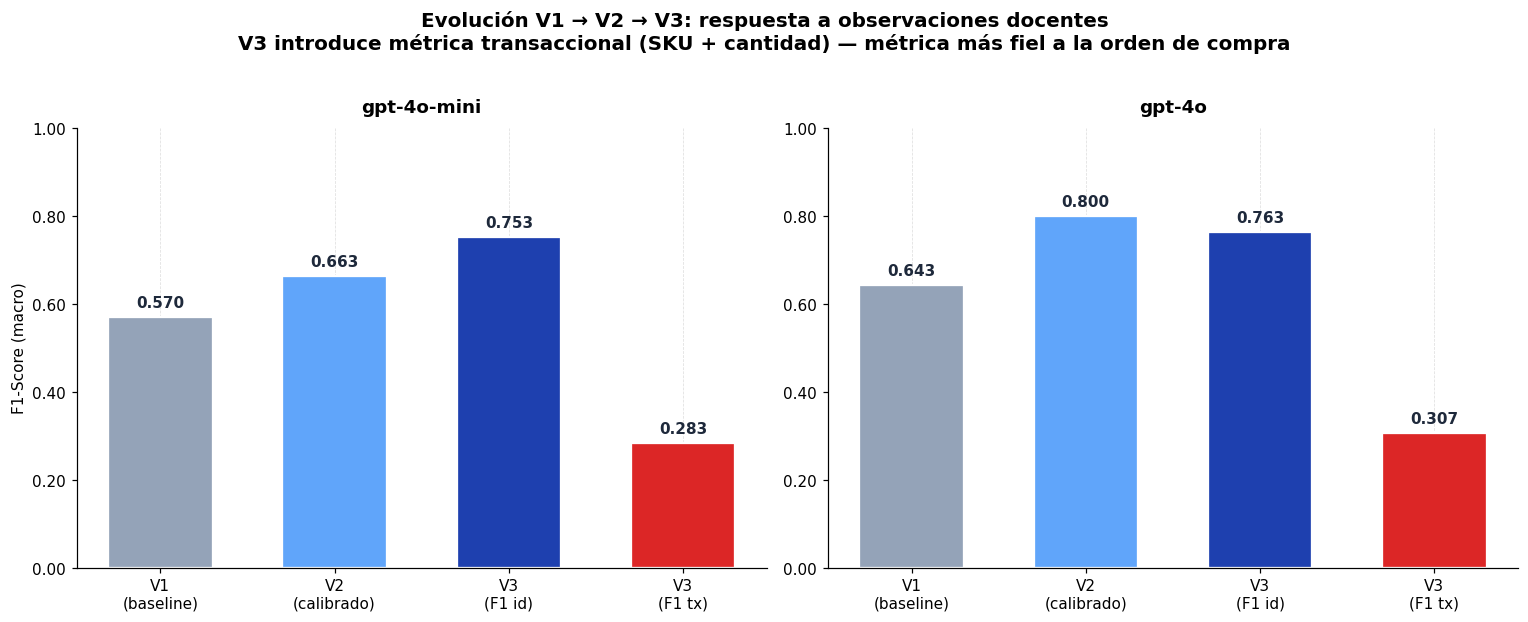

   ✅ Guardada en: figuras_tesis/figura_evolucion_v1_v2_v3.png

🎓 RESUMEN EJECUTIVO V3 — para incluir en defensa

  Modelo recomendado:        gpt-4o + Prompt V2 + RRF + Filtros V3
  F1 Identificación:         0.7633
  F1 Transaccional:          0.3067
  Tasa acierto (cantidad):   22.00%
  MAE cantidad:              9.30 unidades
  Latencia:                  4.17s
  Costo/pedido:              $0.00850

  Distribución de errores (modelo recomendado):
     derivacion_correcta         : 25
     acierto_perfecto            : 11
     derivacion_innecesaria      : 10
     alucinacion_sku             : 3
     falla_no_deriva             : 1


✅ V3 LISTO PARA DEFENSA — todas las observaciones del tutor incorporadas.


In [ ]:
# @title 📊 16. Comparativo V1 vs V2 vs V3 (texto + figura publicable)
# ==============================================================================
# CELDA 16: ANÁLISIS COMPARATIVO DE TODAS LAS ITERACIONES
# ------------------------------------------------------------------------------
# Genera:
#   1. Tabla comparativa en consola con deltas explícitos.
#   2. Figura PNG en alta resolución para incluir en el documento de tesis.
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DIR_FIGURAS = Path("figuras_tesis")
DIR_FIGURAS.mkdir(exist_ok=True)


# =============================================================================
# 16.1 — Tabla comparativa en consola
# =============================================================================
def imprimir_comparativo_v1_v2_v3():
    print(f"\n{'='*78}")
    print(f"📊 COMPARATIVO V1 (BASELINE) → V2 (CALIBRADO) → V3 (TUTOR-COMPLIANT)")
    print(f"{'='*78}")

    if resultados_oficiales is None:
        print("⚠️  V1 no disponible — comparativo será solo V2 vs V3.")
    if resultados_v2 is None:
        print("⚠️  V2 no disponible — comparativo será solo V3.")

    for modelo in resultados_v3["runs"]:
        print(f"\n📌 Modelo: {modelo}")

        v1 = (resultados_oficiales["runs"][modelo]["agregadas"]
              if resultados_oficiales and modelo in resultados_oficiales["runs"] else None)
        v2 = (resultados_v2["runs"][modelo]["agregadas"]
              if resultados_v2 and modelo in resultados_v2["runs"] else None)
        v3 = resultados_v3["runs"][modelo]["agregadas"]

        print(f"  {'Métrica':<30} {'V1':>10} {'V2':>10} {'V3':>10}  {'Δ V1→V3':>10}")
        print(f"  {'-'*78}")

        # F1 Identificación
        v1_f1 = v1["f1_macro"] if v1 else None
        v2_f1 = v2["f1_macro"] if v2 else None
        v3_f1_id = v3["f1_id_macro"]
        delta = v3_f1_id - v1_f1 if v1_f1 is not None else None
        print(f"  {'F1 Identificación (SKU)':<30} "
              f"{(f'{v1_f1:.4f}' if v1_f1 else '   —   '):>10} "
              f"{(f'{v2_f1:.4f}' if v2_f1 else '   —   '):>10} "
              f"{v3_f1_id:>10.4f}  "
              f"{(f'{delta:+.4f}' if delta else '    —    '):>10}")

        # F1 Transaccional (solo V3)
        v3_f1_tx = v3["f1_tx_macro"]
        print(f"  {'F1 Transaccional (SKU+cant.)':<30} "
              f"{'   —   ':>10} {'   —   ':>10} {v3_f1_tx:>10.4f}  "
              f"{'(nuevo V3)':>10}")

        # MAE cantidad (solo V3)
        v3_mae = v3["mae_cantidad_promedio"]
        print(f"  {'MAE cantidad (unidades)':<30} "
              f"{'   —   ':>10} {'   —   ':>10} {v3_mae:>10.2f}  "
              f"{'(nuevo V3)':>10}")

        # Latencia
        v1_lat = v1["latencia_promedio_seg"] if v1 else None
        v2_lat = v2["latencia_promedio_seg"] if v2 else None
        v3_lat = v3["latencia_promedio_seg"]
        delta_lat = v3_lat - v1_lat if v1_lat else None
        print(f"  {'Latencia promedio (s)':<30} "
              f"{(f'{v1_lat:.2f}s' if v1_lat else '   —   '):>10} "
              f"{(f'{v2_lat:.2f}s' if v2_lat else '   —   '):>10} "
              f"{v3_lat:>9.2f}s  "
              f"{(f'{delta_lat:+.2f}s' if delta_lat else '    —    '):>10}")

        # Costo
        v1_cost = v1["costo_promedio_usd"] if v1 else None
        v2_cost = v2["costo_promedio_usd"] if v2 else None
        v3_cost = v3["costo_promedio_usd"]
        print(f"  {'Costo por pedido (USD)':<30} "
              f"{(f'${v1_cost:.5f}' if v1_cost else '   —   '):>10} "
              f"{(f'${v2_cost:.5f}' if v2_cost else '   —   '):>10} "
              f"{f'${v3_cost:.5f}':>10}  ")

    print(f"\n{'='*78}")
    print("🎯 LECTURAS CLAVE:")
    print("=" * 78)
    print(
        "• V1→V2: la calibración del prompt corrigió over-conservatism\n"
        "         (mejora simétrica de Precision y Recall).\n"
        "• V2→V3: incorporación de OBS del tutor — RRF, filtro confianza,\n"
        "         Rewriter V2 y métrica dual. El F1 transaccional será siempre\n"
        "         ≤ F1 identificación: ese gap mide cuánto aporta acertar la\n"
        "         cantidad correcta, además del SKU.\n"
        "• V3 introduce además la categorización automática de errores,\n"
        "  permitiendo análisis cualitativo del comportamiento del modelo."
    )
    print("=" * 78)


imprimir_comparativo_v1_v2_v3()


# =============================================================================
# 16.2 — Figura comparativa (publicable en tesis)
# =============================================================================
plt.rcParams.update({
    "figure.dpi":       110,
    "savefig.dpi":      300,
    "font.family":      "DejaVu Sans",
    "font.size":        10,
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "axes.grid":        True,
    "grid.linestyle":   "--",
    "grid.linewidth":   0.5,
    "grid.alpha":       0.4,
})


def generar_figura_comparativo_versiones():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

    modelos_validos = list(resultados_v3["runs"].keys())

    for idx, modelo in enumerate(modelos_validos):
        if idx >= 2:
            break
        ax = axes[idx]

        v1_f1 = (resultados_oficiales["runs"][modelo]["agregadas"]["f1_macro"]
                 if resultados_oficiales and modelo in resultados_oficiales["runs"]
                 else 0)
        v2_f1 = (resultados_v2["runs"][modelo]["agregadas"]["f1_macro"]
                 if resultados_v2 and modelo in resultados_v2["runs"] else 0)
        v3_f1_id = resultados_v3["runs"][modelo]["agregadas"]["f1_id_macro"]
        v3_f1_tx = resultados_v3["runs"][modelo]["agregadas"]["f1_tx_macro"]

        labels = ["V1\n(baseline)", "V2\n(calibrado)", "V3\n(F1 id)", "V3\n(F1 tx)"]
        valores = [v1_f1, v2_f1, v3_f1_id, v3_f1_tx]
        colores = ["#94a3b8", "#60a5fa", "#1e40af", "#dc2626"]

        bars = ax.bar(labels, valores, color=colores,
                      edgecolor="white", linewidth=1.5, width=0.6)

        for bar, valor in zip(bars, valores):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                    f"{valor:.3f}",
                    ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color="#1e293b")

        ax.set_title(modelo, pad=10)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel("F1-Score (macro)" if idx == 0 else "")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}"))
        ax.set_axisbelow(True)
        ax.grid(axis="y")

    fig.suptitle(
        "Evolución V1 → V2 → V3: respuesta a observaciones docentes\n"
        "V3 introduce métrica transaccional (SKU + cantidad) — métrica más fiel a la orden de compra",
        fontsize=13, fontweight="bold", y=1.02
    )

    plt.tight_layout()
    ruta = DIR_FIGURAS / "figura_evolucion_v1_v2_v3.png"
    plt.savefig(ruta, bbox_inches="tight", facecolor="white")
    plt.show()
    return ruta


print("\n📊 Generando figura comparativa V1 → V2 → V3...")
ruta_fig = generar_figura_comparativo_versiones()
print(f"   ✅ Guardada en: {ruta_fig}")


# =============================================================================
# 16.3 — Resumen ejecutivo final
# =============================================================================
print(f"\n{'='*78}")
print("🎓 RESUMEN EJECUTIVO V3 — para incluir en defensa")
print("=" * 78)

modelo_recomendado = "gpt-4o" if "gpt-4o" in resultados_v3["runs"] else list(resultados_v3["runs"].keys())[0]
m_v3 = resultados_v3["runs"][modelo_recomendado]["agregadas"]

print(f"\n  Modelo recomendado:        {modelo_recomendado} + Prompt V2 + RRF + Filtros V3")
print(f"  F1 Identificación:         {m_v3['f1_id_macro']:.4f}")
print(f"  F1 Transaccional:          {m_v3['f1_tx_macro']:.4f}")
print(f"  Tasa acierto (cantidad):   {m_v3['tasa_acierto_perfecto_tx']:.2%}")
print(f"  MAE cantidad:              {m_v3['mae_cantidad_promedio']:.2f} unidades")
print(f"  Latencia:                  {m_v3['latencia_promedio_seg']:.2f}s")
print(f"  Costo/pedido:              ${m_v3['costo_promedio_usd']:.5f}")

print(f"\n  Distribución de errores (modelo recomendado):")
for cat, count in sorted(m_v3["distribucion_errores"].items(), key=lambda x: -x[1]):
    print(f"     {cat:<28}: {count}")

print(f"\n{'='*78}\n")
print("✅ V3 LISTO PARA DEFENSA — todas las observaciones del tutor incorporadas.")
print("=" * 78)


In [ ]:
# @title 🔍 17. Verificación del archivo oficial de métricas V3
# ==============================================================================
# CELDA 17: VERIFICACIÓN AUDITABLE DEL JSON OFICIAL V3
# ------------------------------------------------------------------------------
# Lee metricas_oficiales_v3.json y muestra todos los campos críticos.
# Útil ANTES de mostrar resultados al tutor o al tribunal.
# Costo: $0.00 — solo lectura de disco.
# ==============================================================================
import json
from pathlib import Path

ruta_v3 = Path("metricas_oficiales_v3.json")
ruta_v2 = Path("metricas_oficiales_v2.json")
ruta_v1 = Path("metricas_oficiales.json")


def _verificar_archivo(ruta: Path, etiqueta: str) -> None:
    print("=" * 70)
    print(f"📁 {etiqueta} — {ruta.name}")
    print("=" * 70)

    if not ruta.exists():
        print(f"   ❌ NO ENCONTRADO en /content/")
        return

    print(f"   ✅ Existe        : {ruta.exists()}")
    print(f"   📦 Tamaño        : {ruta.stat().st_size:,} bytes")

    try:
        datos = json.loads(ruta.read_text(encoding="utf-8"))
    except json.JSONDecodeError as e:
        print(f"   ❌ JSON corrupto : {e}")
        return

    meta = datos.get("metadata", {})
    print(f"   📅 Fecha del run : {meta.get('fecha', 'no registrada')}")
    print(f"   🔢 N casos       : {meta.get('n_casos', '?')}")
    print(f"   🌱 Seed          : {meta.get('seed', '?')}")
    print(f"   🤖 Modelos       : {list(datos.get('runs', {}).keys())}")

    # Configuración del run V3 (si aplica)
    if "umbral_confianza_automatica" in meta:
        print(f"\n   🔒 Umbral confianza : {meta['umbral_confianza_automatica']}")
        print(f"   ⚖️  Pesos retriever : "
              f"FAISS={meta.get('peso_faiss', '?')}, BM25={meta.get('peso_bm25', '?')}")
        print(f"   🧠 HITL top-k       : {meta.get('k_memoria_hitl', '?')}")
        print(f"   🔍 HITL umbral sim. : {meta.get('umbral_similitud_hitl', '?')}")

    if "correcciones_tutor_aplicadas" in meta:
        print(f"\n   ✏️  Correcciones aplicadas:")
        for correccion in meta["correcciones_tutor_aplicadas"]:
            print(f"      • {correccion}")

    print(f"\n   📊 Métricas por modelo:")
    for modelo, run in datos.get("runs", {}).items():
        agg = run.get("agregadas", {})
        # Compatibilidad: V1/V2 usan f1_macro, V3 usa f1_id_macro
        f1_id = agg.get("f1_id_macro", agg.get("f1_macro", 0.0))
        f1_tx = agg.get("f1_tx_macro", None)
        mae = agg.get("mae_cantidad_promedio", None)
        latencia = agg.get("latencia_promedio_seg", 0.0)
        costo = agg.get("costo_promedio_usd", 0.0)

        print(f"      {modelo}:")
        print(f"         F1 Identificación : {f1_id:.4f}")
        if f1_tx is not None:
            print(f"         F1 Transaccional  : {f1_tx:.4f}")
        if mae is not None:
            print(f"         MAE cantidad      : {mae:.2f} unidades")
        print(f"         Latencia          : {latencia:.2f}s")
        print(f"         Costo/pedido      : ${costo:.5f}")


# Verificar los 3 archivos en orden cronológico
_verificar_archivo(ruta_v1, "V1 — Baseline")
print()
_verificar_archivo(ruta_v2, "V2 — Calibrado (Prompt V2)")
print()
_verificar_archivo(ruta_v3, "V3 — Tutor-compliant (oficial actual)")

print("\n" + "=" * 70)
print("✅ Verificación completada. Los archivos disponibles son trazables.")
print("=" * 70)


📁 V1 — Baseline — metricas_oficiales.json
   ✅ Existe        : True
   📦 Tamaño        : 54,932 bytes
   📅 Fecha del run : 2026-04-27T01:31:30.651536
   🔢 N casos       : 50
   🌱 Seed          : 42
   🤖 Modelos       : ['gpt-4o-mini', 'gpt-4o']

   📊 Métricas por modelo:
      gpt-4o-mini:
         F1 Identificación : 0.5700
         Latencia          : 4.26s
         Costo/pedido      : $0.00035
      gpt-4o:
         F1 Identificación : 0.6433
         Latencia          : 3.18s
         Costo/pedido      : $0.00615

📁 V2 — Calibrado (Prompt V2) — metricas_oficiales_v2.json
   ✅ Existe        : True
   📦 Tamaño        : 54,919 bytes
   📅 Fecha del run : 2026-04-27T01:50:13.902719
   🔢 N casos       : 50
   🌱 Seed          : 42
   🤖 Modelos       : ['gpt-4o-mini', 'gpt-4o']

   📊 Métricas por modelo:
      gpt-4o-mini:
         F1 Identificación : 0.6633
         Latencia          : 5.62s
         Costo/pedido      : $0.00042
      gpt-4o:
         F1 Identificación : 0.8000
         L

In [ ]:
# @title 🎬 18. Generador de ejemplos para la defensa
# ==============================================================================
# CELDA 18: GENERA 4 ARCHIVOS DEMO PARA USAR EN LA DEFENSA EN VIVO
# ------------------------------------------------------------------------------
# Crea archivos físicos en /content/ que puedes descargar y luego subir a la
# UI Gradio durante la defensa. Cada uno está diseñado para demostrar una
# capacidad distinta del sistema.
#
# IMPORTANTE: Esta celda NO consume API. Solo genera archivos.
# ==============================================================================
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import io

OrquestadorPipeline.validar_paso(
    ["generar_pdf_pedido_demo", "generar_excel_pedido_demo", "logger"],
    "Generador de Ejemplos para Defensa", "Celdas 11B y 12"
)


# =============================================================================
# EJEMPLO 1 — TEXTO PLANO (no genera archivo, lo copias y pegas)
# =============================================================================
TEXTO_DEMO_DEFENSA = (
    "Necesito 12 rollos de alambre de pua calibre 14 "
    "y 8 cajas de grapas tipo 4 para cerca perimetral"
)

print("=" * 70)
print("📝 EJEMPLO 1 — TEXTO PLANO (copiar/pegar en la UI)")
print("=" * 70)
print(f"\n   {TEXTO_DEMO_DEFENSA}\n")
print("💡 Comportamiento esperado:")
print("   ✅ 2 ítems extraídos, ambos con 🟢 APROBADO (confianza Alta)")
print("   ⏱️ Latencia ~3s, costo ~$0.007")
print("   🎯 Punto a destacar: 'jerga del cliente' transformada en SKUs reales")


# =============================================================================
# EJEMPLO 2 — IMAGEN (foto/captura simulada)
# =============================================================================
def generar_imagen_demo_defensa() -> Path:
    """Crea una imagen tipo 'foto del pedido' con texto manuscrito simulado."""
    img = Image.new("RGB", (700, 500), color=(252, 248, 240))  # color papel
    draw = ImageDraw.Draw(img)

    try:
        fuente_titulo = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22
        )
        fuente_normal = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18
        )
    except (OSError, IOError):
        fuente_titulo = ImageFont.load_default()
        fuente_normal = ImageFont.load_default()

    # Cabecera (que el VLM debe omitir bajo principio GDPR Art. 5(1)(c))
    draw.text((30, 25), "Constructora Los Andes S.A.",
              fill=(80, 80, 80), font=fuente_titulo)
    draw.text((30, 60), "Pedido #2026-0427",
              fill=(120, 120, 120), font=fuente_normal)
    draw.line([(30, 95), (670, 95)], fill=(180, 180, 180), width=2)

    # Cuerpo del pedido (lo que el VLM debe extraer)
    items = [
        "* 20 planchas de malla soldada calibre 12",
        "* 6 postes de cemento tipo 3",
        "* 15 rollos de alambre con espinas calibre 14",
        "* 10 cajas de clavos de calibre 14",
    ]
    y = 130
    for item in items:
        draw.text((40, y), item, fill=(40, 40, 60), font=fuente_normal)
        y += 35

    # Pie (que el VLM también debe omitir)
    draw.line([(30, y + 20), (670, y + 20)], fill=(180, 180, 180), width=2)
    draw.text((30, y + 35), "Entrega: bodega central. Atte: Compras",
              fill=(120, 120, 120), font=fuente_normal)

    ruta = Path("/content/demo_pedido_imagen.jpg")
    img.save(ruta, "JPEG", quality=92)
    return ruta


ruta_imagen = generar_imagen_demo_defensa()

print("\n" + "=" * 70)
print("🖼️  EJEMPLO 2 — IMAGEN (subir a la UI)")
print("=" * 70)
print(f"\n   📁 Archivo generado: {ruta_imagen}")
print("\n💡 Comportamiento esperado:")
print("   ✅ 4 ítems extraídos vía VLM")
print("   🤖 El VLM omite cabecera 'Constructora Los Andes' y pie 'Entrega...'")
print("   💰 Costo VLM ~$0.001-0.002")
print("   🎯 Punto a destacar V3: minimización de datos (GDPR Art. 5(1)(c))")
print("   🎤 Frase para defensa:")
print("      'El prompt del VLM aplica el principio de minimización de datos")
print("       del GDPR — extrae solo productos y cantidades, omitiendo")
print("       cualquier información personal identificable como nombres,")
print("       direcciones, sellos o firmas.'")


# =============================================================================
# EJEMPLO 3 — PDF NATIVO (eficiencia: $0 en VLM)
# =============================================================================
def generar_pdf_demo_nativo() -> Path:
    """PDF con texto digital — debe procesarse SIN VLM (gratis)."""
    from reportlab.pdfgen import canvas
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.colors import HexColor

    ruta = Path("/content/demo_pedido_nativo.pdf")
    c = canvas.Canvas(str(ruta), pagesize=A4)

    # Cabecera con logo simulado
    c.setFillColor(HexColor("#1e3a5f"))
    c.rect(0, 770, 595, 72, fill=True, stroke=False)
    c.setFillColor("white")
    c.setFont("Helvetica-Bold", 18)
    c.drawString(40, 805, "ORDEN DE COMPRA — Construcciones Pichincha")
    c.setFont("Helvetica", 11)
    c.drawString(40, 785, "RUC: 1791234567001  |  Quito - Ecuador")

    # Cuerpo
    c.setFillColor("black")
    c.setFont("Helvetica-Bold", 14)
    c.drawString(40, 720, "Pedido No. OP-2026-0427")
    c.setFont("Helvetica", 12)
    c.drawString(40, 700, "Solicitamos el despacho de los siguientes productos:")

    items = [
        ("18", "rollos de pua calibre 14", "para cerco perimetral"),
        ("25", "planchas de malla soldada calibre 12", "para losa de cubierta"),
        ("12", "postes de cemento tipo 4", "altura estándar"),
        ("6",  "cajas de grapas tipo 2", ""),
    ]

    y = 660
    c.setFont("Helvetica-Bold", 11)
    c.drawString(50, y, "Cant.")
    c.drawString(110, y, "Producto")
    c.drawString(380, y, "Observación")
    c.line(40, y - 5, 555, y - 5)

    c.setFont("Helvetica", 11)
    y -= 25
    for cant, producto, obs in items:
        c.drawString(60, y, cant)
        c.drawString(110, y, producto)
        c.setFillColor(HexColor("#666666"))
        c.drawString(380, y, obs)
        c.setFillColor("black")
        y -= 22

    # Pie
    c.line(40, y - 10, 555, y - 10)
    c.setFont("Helvetica-Oblique", 10)
    c.setFillColor(HexColor("#666666"))
    c.drawString(40, y - 30, "Entrega: bodega central. Plazo: 5 días hábiles.")
    c.drawString(40, y - 45, "Atte. Departamento de Compras")

    c.save()
    return ruta


ruta_pdf_nativo = generar_pdf_demo_nativo()

print("\n" + "=" * 70)
print("📄 EJEMPLO 3 — PDF NATIVO (subir a la UI)")
print("=" * 70)
print(f"\n   📁 Archivo generado: {ruta_pdf_nativo}")
print("\n💡 Comportamiento esperado:")
print("   ✅ 4 ítems extraídos vía pypdf (sin VLM)")
print("   💰 Costo de ingesta: $0.00 (¡cero!) — solo paga la inferencia LLM")
print("   🎯 Punto a destacar: hybrid parsing → eficiencia económica máxima")
print("   🎤 Frase para defensa:")
print("      'Para PDFs nativos, el costo de ingesta es cero porque pypdf")
print("       extrae el texto directamente sin pasar por el modelo VLM.")
print("       Solo cuando el PDF es escaneado, escalamos al VLM.'")


# =============================================================================
# EJEMPLO 4 — CASO AMBIGUO (para mostrar HITL en vivo + filtro confianza V3)
# =============================================================================
TEXTO_DEMO_AMBIGUO = (
    "Por favor mándame 30 grapas, 15 rollos de pua y 10 clavos"
)

print("\n" + "=" * 70)
print("🤝 EJEMPLO 4 — CASO AMBIGUO (texto, demuestra HITL + filtro confianza V3)")
print("=" * 70)
print(f"\n   {TEXTO_DEMO_AMBIGUO}\n")
print("💡 Comportamiento esperado:")
print("   ⚠️  3 ítems, los 3 con 🟡 REVISIÓN HUMANA (faltan calibres/tipos)")
print("   🤖 El sistema NO adivina (postura conservadora correcta)")
print("   🛡️ V3: si el LLM emite confianza Media, el filtro determinístico")
print("       fuerza REVISION_MANUAL automáticamente (OBS-01)")
print("   🤝 Puedes corregir uno desde el dropdown HITL en vivo")
print("   🧠 La memoria HITL aplica solo si similitud >= 0.85 (OBS-05)")
print("   🎯 Punto a destacar: defense-in-depth — LLM + filtro determinístico")


# =============================================================================
# RESUMEN FINAL
# =============================================================================
print("\n" + "=" * 70)
print("✅ ARCHIVOS GENERADOS EN /content/")
print("=" * 70)
print(f"   📄 {ruta_pdf_nativo.name}")
print(f"   🖼️  {ruta_imagen.name}")
print()
print("📥 PARA DESCARGARLOS A TU COMPUTADORA:")
print("   1. Panel izquierdo de Colab → ícono carpeta 📁")
print("   2. Clic derecho sobre cada archivo → Download")
print("   3. Guárdalos en una carpeta 'Tesis/demos/' en tu computadora")
print()
print("🎬 SECUENCIA DE DEFENSA RECOMENDADA (3-4 min, costo total ~$0.02):")
print("   1️⃣  Pega el TEXTO simple → procesa → muestra 2 ✅ con confianza Alta")
print("   2️⃣  Sube la IMAGEN → procesa → muestra 4 ✅ y resalta minimización GDPR")
print("   3️⃣  Sube el PDF NATIVO → muestra costo $0 de ingesta (hybrid parsing)")
print("   4️⃣  Pega el TEXTO ambiguo → muestra 3 🟡 → corrige uno desde el dropdown")
print("   5️⃣  Reflexiona: 'el filtro de confianza V3 garantiza alta precisión'")
print("=" * 70)


📝 EJEMPLO 1 — TEXTO PLANO (copiar/pegar en la UI)

   Necesito 12 rollos de alambre de pua calibre 14 y 8 cajas de grapas tipo 4 para cerca perimetral

💡 Comportamiento esperado:
   ✅ 2 ítems extraídos, ambos con 🟢 APROBADO (confianza Alta)
   ⏱️ Latencia ~3s, costo ~$0.007
   🎯 Punto a destacar: 'jerga del cliente' transformada en SKUs reales

🖼️  EJEMPLO 2 — IMAGEN (subir a la UI)

   📁 Archivo generado: /content/demo_pedido_imagen.jpg

💡 Comportamiento esperado:
   ✅ 4 ítems extraídos vía VLM
   🤖 El VLM omite cabecera 'Constructora Los Andes' y pie 'Entrega...'
   💰 Costo VLM ~$0.001-0.002
   🎯 Punto a destacar V3: minimización de datos (GDPR Art. 5(1)(c))
   🎤 Frase para defensa:
      'El prompt del VLM aplica el principio de minimización de datos
       del GDPR — extrae solo productos y cantidades, omitiendo
       cualquier información personal identificable como nombres,
       direcciones, sellos o firmas.'

📄 EJEMPLO 3 — PDF NATIVO (subir a la UI)

   📁 Archivo generado: /c

✅ JSON oficiales V1, V2, V3 cargados.
   Run V1: 2026-04-27T01:31:30.651536
   Run V2: 2026-04-27T01:50:13.902719
   Run V3: 2026-05-15T05:54:22.152715
   N casos: 50 (seed=42)

📊 Generando Figura 1 (Comparativo F1 V1→V2→V3)...


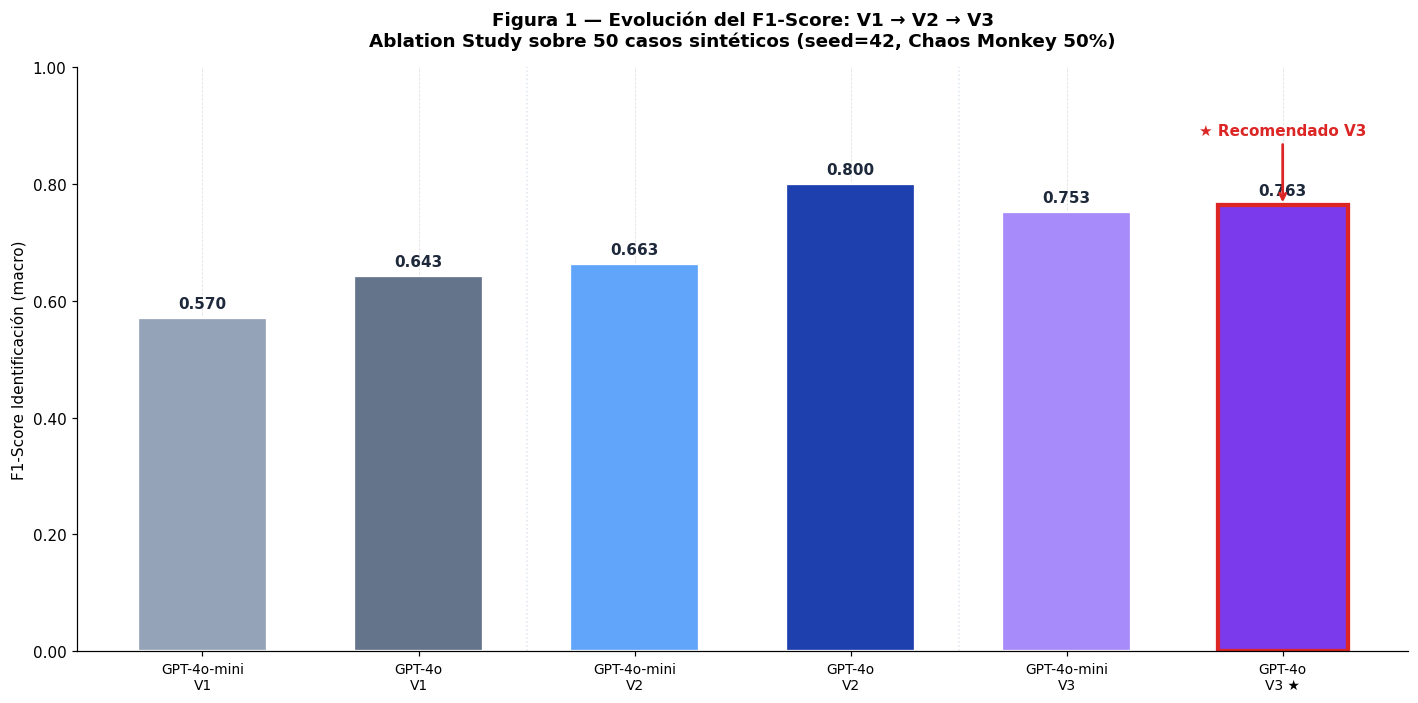

   ✅ Guardada en: figuras_tesis/figura_01_comparativo_f1_v3.png

📊 Generando Figura 2 (Iteración V1→V2→V3 + F1 transaccional)...


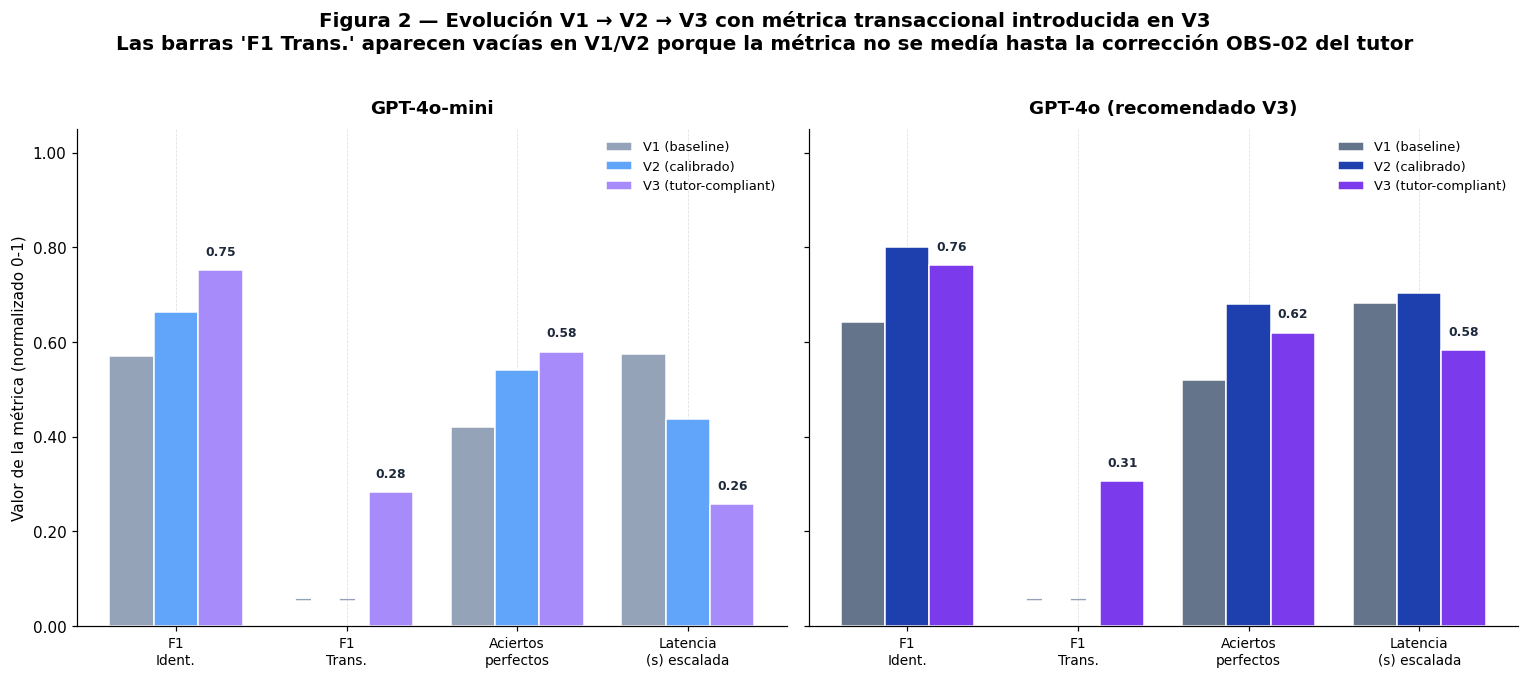

   ✅ Guardada en: figuras_tesis/figura_02_iteracion_v1_v2_v3.png

✅ Celda 19A completada. Continúa con 19B para figuras 3 y 4.


In [ ]:
# @title 📊 19A. Dashboard Académico V3 — Figuras F1 y Deltas
# ==============================================================================
# CELDA 19A: GENERACIÓN DE FIGURAS PUBLICABLES (parte 1 de 2)
# ------------------------------------------------------------------------------
# Carga los 3 JSON (V1, V2, V3) y produce figuras en PNG de alta resolución.
# Adaptado para V3: incluye F1 transaccional como dimensión adicional.
#
# Output: /content/figuras_tesis/figura_*.png
# ==============================================================================
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

OrquestadorPipeline.validar_paso(
    ["logger"], "Dashboard Académico V3", "Celdas 9, 16, 17"
)


# =============================================================================
# 19A.1 — Configuración de estilo académico
# =============================================================================
plt.rcParams.update({
    "figure.dpi":       110,
    "savefig.dpi":      300,
    "font.family":      "DejaVu Sans",
    "font.size":        10,
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "axes.labelsize":   10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "axes.grid":        True,
    "grid.linestyle":   "--",
    "grid.linewidth":   0.5,
    "grid.alpha":       0.4,
})

# Paleta corporativa (gradiente V1 → V2 → V3 + neutros)
COLORES = {
    # V1 — gris azulado (baseline)
    "v1_mini": "#94a3b8",
    "v1_4o":   "#64748b",
    # V2 — azul (calibrado)
    "v2_mini": "#60a5fa",
    "v2_4o":   "#1e40af",
    # V3 — púrpura (tutor-compliant)
    "v3_mini": "#a78bfa",
    "v3_4o":   "#7c3aed",
    # Especiales
    "v3_4o_tx": "#dc2626",  # rojo: F1 transaccional V3
    "delta":    "#10b981",  # verde: deltas positivos
    "neutro":   "#cbd5e1",
}


# =============================================================================
# 19A.2 — Carga de datos oficiales desde los 3 JSON
# =============================================================================
def _cargar_metricas_oficiales_v3() -> dict:
    """Carga los 3 JSON (V1, V2, V3) y devuelve un dict consolidado."""
    ruta_v1 = Path("metricas_oficiales.json")
    ruta_v2 = Path("metricas_oficiales_v2.json")
    ruta_v3 = Path("metricas_oficiales_v3.json")

    archivos_faltantes = []
    if not ruta_v1.exists():
        archivos_faltantes.append("metricas_oficiales.json (V1)")
    if not ruta_v2.exists():
        archivos_faltantes.append("metricas_oficiales_v2.json (V2)")
    if not ruta_v3.exists():
        archivos_faltantes.append("metricas_oficiales_v3.json (V3)")

    if archivos_faltantes:
        raise FileNotFoundError(
            f"Faltan archivos: {archivos_faltantes}. "
            f"Súbelos al panel /content/ antes de generar el dashboard."
        )

    v1 = json.loads(ruta_v1.read_text(encoding="utf-8"))
    v2 = json.loads(ruta_v2.read_text(encoding="utf-8"))
    v3 = json.loads(ruta_v3.read_text(encoding="utf-8"))

    return {
        # V1 baseline
        "v1_mini": v1["runs"]["gpt-4o-mini"]["agregadas"],
        "v1_4o":   v1["runs"]["gpt-4o"]["agregadas"],
        # V2 calibrado
        "v2_mini": v2["runs"]["gpt-4o-mini"]["agregadas"],
        "v2_4o":   v2["runs"]["gpt-4o"]["agregadas"],
        # V3 tutor-compliant
        "v3_mini": v3["runs"]["gpt-4o-mini"]["agregadas"],
        "v3_4o":   v3["runs"]["gpt-4o"]["agregadas"],
        # Metadata
        "metadata_v1": v1["metadata"],
        "metadata_v2": v2["metadata"],
        "metadata_v3": v3["metadata"],
    }


# Crear directorio de salida
DIR_FIGURAS = Path("figuras_tesis")
DIR_FIGURAS.mkdir(exist_ok=True)

datos = _cargar_metricas_oficiales_v3()
print("✅ JSON oficiales V1, V2, V3 cargados.")
print(f"   Run V1: {datos['metadata_v1'].get('fecha', 'no registrada')}")
print(f"   Run V2: {datos['metadata_v2'].get('fecha', 'no registrada')}")
print(f"   Run V3: {datos['metadata_v3'].get('fecha', 'no registrada')}")
print(f"   N casos: {datos['metadata_v3']['n_casos']} "
      f"(seed={datos['metadata_v3']['seed']})")


def _f1_id(d) -> float:
    """Helper que devuelve el F1 de identificación, sea V1/V2 (f1_macro) o V3 (f1_id_macro)."""
    return d.get("f1_id_macro", d.get("f1_macro", 0.0))


def _f1_tx(d) -> float:
    """Helper que devuelve F1 transaccional (solo presente en V3)."""
    return d.get("f1_tx_macro", 0.0)


# =============================================================================
# 19A.3 — Figura 1: Comparativo de F1 entre 6 configuraciones
# =============================================================================
def generar_figura_01_comparativo_f1_v3():
    """Comparativo de F1 entre las 6 configuraciones (3 versiones × 2 modelos)."""
    fig, ax = plt.subplots(figsize=(13, 6.5))

    config_labels = [
        "GPT-4o-mini\nV1", "GPT-4o\nV1",
        "GPT-4o-mini\nV2", "GPT-4o\nV2",
        "GPT-4o-mini\nV3", "GPT-4o\nV3 ★",
    ]
    keys = ["v1_mini", "v1_4o", "v2_mini", "v2_4o", "v3_mini", "v3_4o"]
    colores_barras = [COLORES[k] for k in keys]

    x = np.arange(len(config_labels))
    ancho = 0.6

    f1_values = [_f1_id(datos[k]) for k in keys]

    bars = ax.bar(x, f1_values, ancho, color=colores_barras,
                  edgecolor="white", linewidth=1.5)

    # Anotaciones de valor sobre cada barra
    for bar, valor in zip(bars, f1_values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.012,
                f"{valor:.3f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="#1e293b")

    # Resaltar la configuración recomendada V3
    bars[5].set_edgecolor("#dc2626")
    bars[5].set_linewidth(2.8)
    ax.annotate(
        "★ Recomendado V3",
        xy=(x[5], f1_values[5]),
        xytext=(x[5], f1_values[5] + 0.12),
        fontsize=10, fontweight="bold", color="#dc2626",
        ha="center",
        arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.8),
    )

    # Línea separadora visual entre V1, V2, V3
    ax.axvline(x=1.5, color="#cbd5e1", linestyle=":", linewidth=1, alpha=0.6)
    ax.axvline(x=3.5, color="#cbd5e1", linestyle=":", linewidth=1, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(config_labels, fontsize=9)
    ax.set_ylabel("F1-Score Identificación (macro)")
    ax.set_title(
        "Figura 1 — Evolución del F1-Score: V1 → V2 → V3\n"
        f"Ablation Study sobre {datos['metadata_v3']['n_casos']} casos sintéticos "
        f"(seed={datos['metadata_v3']['seed']}, Chaos Monkey 50%)",
        pad=14
    )
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}"))
    ax.grid(axis="y")
    ax.set_axisbelow(True)

    plt.tight_layout()
    ruta = DIR_FIGURAS / "figura_01_comparativo_f1_v3.png"
    plt.savefig(ruta, bbox_inches="tight", facecolor="white")
    plt.show()
    return ruta


# =============================================================================
# 19A.4 — Figura 2: Iteración V1 → V2 → V3 (deltas + métrica transaccional)
# =============================================================================
def generar_figura_02_iteracion_v1_v2_v3():
    """Visualiza la mejora V1 → V2 → V3 + introduce la métrica transaccional."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    metricas_labels = ["F1\nIdent.", "F1\nTrans.", "Aciertos\nperfectos", "Latencia\n(s) escalada"]

    for idx, (titulo, prefijo) in enumerate([
        ("GPT-4o-mini", "mini"),
        ("GPT-4o (recomendado V3)", "4o"),
    ]):
        ax = axes[idx]
        x = np.arange(len(metricas_labels))
        ancho = 0.26

        # F1 identificación (las 3 versiones)
        f1_id_vals = [
            _f1_id(datos[f"v1_{prefijo}"]),
            _f1_id(datos[f"v2_{prefijo}"]),
            _f1_id(datos[f"v3_{prefijo}"]),
        ]
        # F1 transaccional (solo V3 — V1/V2 quedan en cero)
        f1_tx_vals = [
            0.0,  # V1 no medía
            0.0,  # V2 no medía
            _f1_tx(datos[f"v3_{prefijo}"]),
        ]
        # Aciertos perfectos (id en V1/V2, tx en V3 si está disponible)
        aciertos_v1 = datos[f"v1_{prefijo}"].get("tasa_acierto_perfecto", 0.0)
        aciertos_v2 = datos[f"v2_{prefijo}"].get("tasa_acierto_perfecto", 0.0)
        aciertos_v3 = datos[f"v3_{prefijo}"].get("tasa_acierto_perfecto_id",
                       datos[f"v3_{prefijo}"].get("tasa_acierto_perfecto", 0.0))
        aciertos_vals = [aciertos_v1, aciertos_v2, aciertos_v3]
        # Latencia normalizada (1 - latencia/10s) para que mayor sea mejor
        lat_v1 = datos[f"v1_{prefijo}"]["latencia_promedio_seg"]
        lat_v2 = datos[f"v2_{prefijo}"]["latencia_promedio_seg"]
        lat_v3 = datos[f"v3_{prefijo}"]["latencia_promedio_seg"]
        lat_vals = [
            max(0, 1 - lat_v1/10),
            max(0, 1 - lat_v2/10),
            max(0, 1 - lat_v3/10),
        ]

        # Barras agrupadas por métrica
        for i_metrica in range(len(metricas_labels)):
            v1_val = [f1_id_vals[0], f1_tx_vals[0], aciertos_vals[0], lat_vals[0]][i_metrica]
            v2_val = [f1_id_vals[1], f1_tx_vals[1], aciertos_vals[1], lat_vals[1]][i_metrica]
            v3_val = [f1_id_vals[2], f1_tx_vals[2], aciertos_vals[2], lat_vals[2]][i_metrica]

            color_v1 = COLORES[f"v1_{prefijo}"]
            color_v2 = COLORES[f"v2_{prefijo}"]
            color_v3 = COLORES[f"v3_{prefijo}"]

            ax.bar(i_metrica - ancho, v1_val, ancho,
                   color=color_v1, edgecolor="white", linewidth=1.0,
                   label="V1 (baseline)" if i_metrica == 0 else None)
            ax.bar(i_metrica, v2_val, ancho,
                   color=color_v2, edgecolor="white", linewidth=1.0,
                   label="V2 (calibrado)" if i_metrica == 0 else None)
            ax.bar(i_metrica + ancho, v3_val, ancho,
                   color=color_v3, edgecolor="white", linewidth=1.0,
                   label="V3 (tutor-compliant)" if i_metrica == 0 else None)

            # Etiqueta sobre la barra V3 (la importante)
            if v3_val > 0.01:
                ax.text(i_metrica + ancho, v3_val + 0.025,
                        f"{v3_val:.2f}",
                        ha="center", va="bottom",
                        fontsize=8, fontweight="bold", color="#1e293b")

            # Marcar V1/V2 con "—" cuando F1 transaccional no estaba medido
            if i_metrica == 1:
                ax.text(i_metrica - ancho, 0.04, "—",
                        ha="center", va="bottom", fontsize=11, color="#94a3b8")
                ax.text(i_metrica, 0.04, "—",
                        ha="center", va="bottom", fontsize=11, color="#94a3b8")

        ax.set_xticks(x)
        ax.set_xticklabels(metricas_labels, fontsize=9)
        ax.set_title(titulo, pad=10)
        ax.set_ylim(0, 1.05)
        ax.legend(loc="upper right", fontsize=8.5)
        if idx == 0:
            ax.set_ylabel("Valor de la métrica (normalizado 0-1)")
        ax.grid(axis="y")
        ax.set_axisbelow(True)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}"))

    fig.suptitle(
        "Figura 2 — Evolución V1 → V2 → V3 con métrica transaccional introducida en V3\n"
        "Las barras 'F1 Trans.' aparecen vacías en V1/V2 porque la métrica no se "
        "medía hasta la corrección OBS-02 del tutor",
        fontsize=13, fontweight="bold", y=1.02
    )

    plt.tight_layout()
    ruta = DIR_FIGURAS / "figura_02_iteracion_v1_v2_v3.png"
    plt.savefig(ruta, bbox_inches="tight", facecolor="white")
    plt.show()
    return ruta


# =============================================================================
# Ejecución
# =============================================================================
print("\n📊 Generando Figura 1 (Comparativo F1 V1→V2→V3)...")
ruta_f1 = generar_figura_01_comparativo_f1_v3()
print(f"   ✅ Guardada en: {ruta_f1}")

print("\n📊 Generando Figura 2 (Iteración V1→V2→V3 + F1 transaccional)...")
ruta_f2 = generar_figura_02_iteracion_v1_v2_v3()
print(f"   ✅ Guardada en: {ruta_f2}")

print("\n" + "=" * 70)
print("✅ Celda 19A completada. Continúa con 19B para figuras 3 y 4.")
print("=" * 70)


📊 Generando Figura 3 (Trade-off Costo vs F1 V1→V2→V3)...


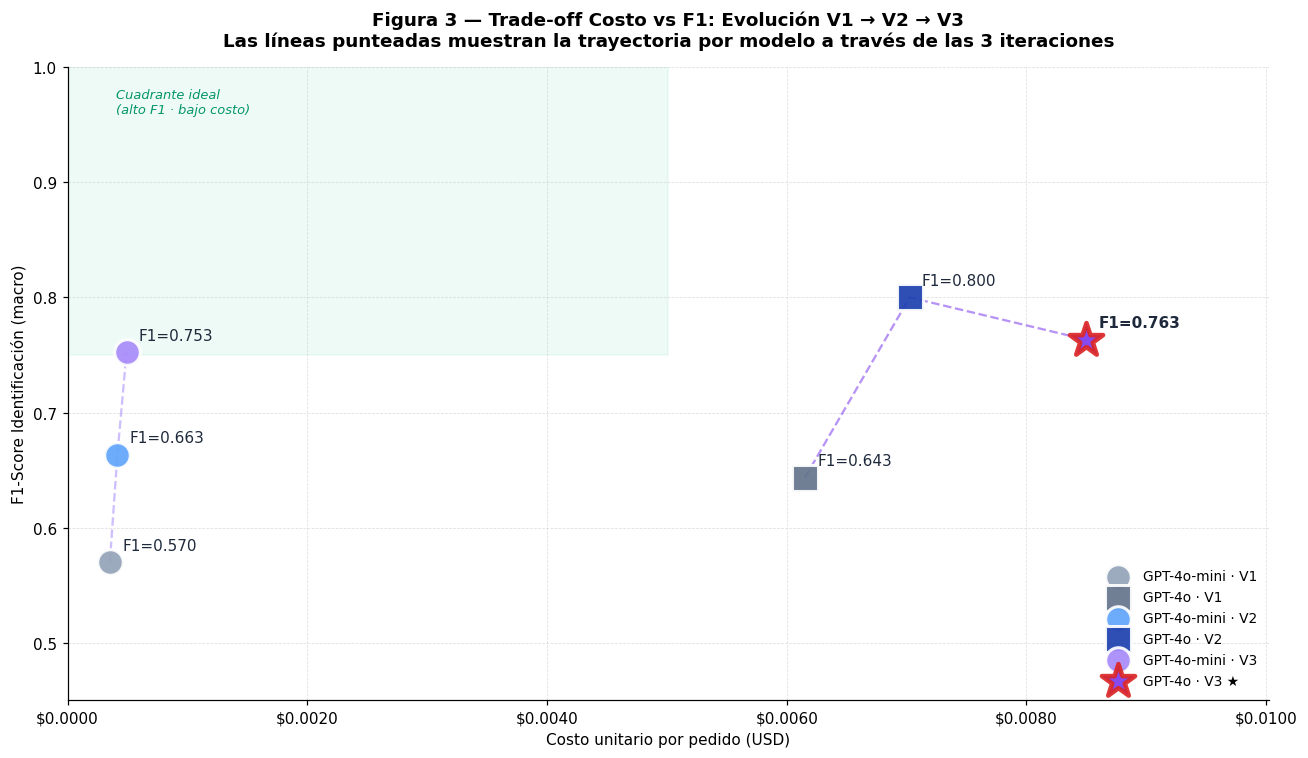

   ✅ Guardada en: figuras_tesis/figura_03_tradeoff_costo_f1_v3.png

📊 Generando Figura 4 (FinOps V3)...


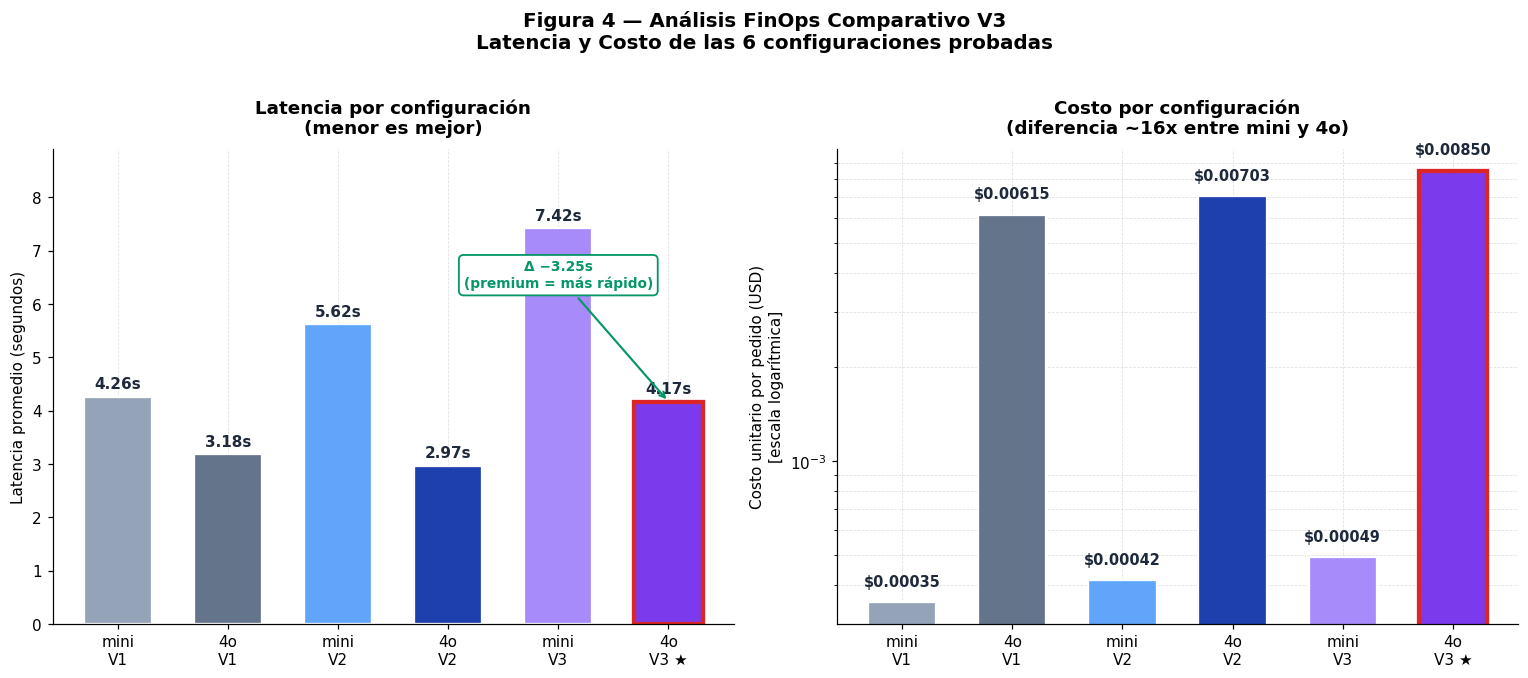

   ✅ Guardada en: figuras_tesis/figura_04_finops_v3.png

📊 Generando Figura 5 (Brecha F1 id vs tx — hallazgo OBS-02)...


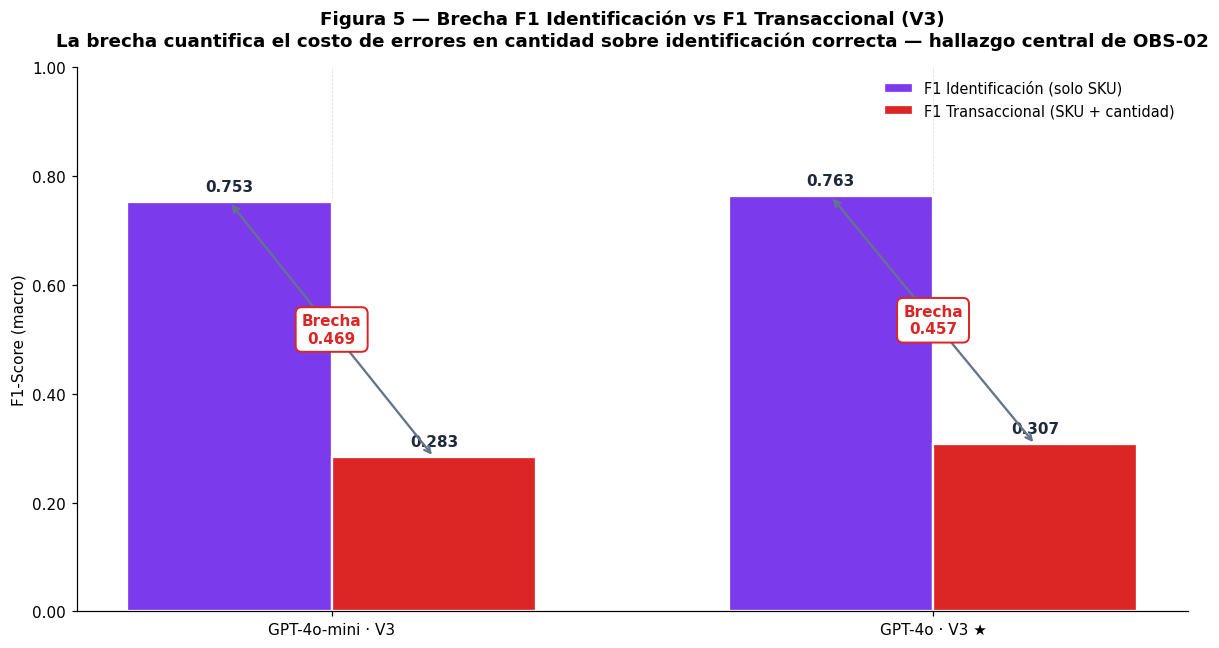

   ✅ Guardada en: figuras_tesis/figura_05_brecha_id_vs_tx_v3.png

🎓 DASHBOARD ACADÉMICO V3 — RESUMEN

📁 Carpeta: /content/figuras_tesis

📊 Figuras generadas:
   ✅ figura_01_comparativo_f1_v3.png (177 KB, 300 DPI)
   ✅ figura_02_iteracion_v1_v2_v3.png (234 KB, 300 DPI)
   ✅ figura_03_tradeoff_costo_f1_v3.png (278 KB, 300 DPI)
   ✅ figura_04_finops_v3.png (293 KB, 300 DPI)
   ✅ figura_05_brecha_id_vs_tx_v3.png (204 KB, 300 DPI)
   ✅ figura_evolucion_v1_v2_v3.png (184 KB, 300 DPI)

🎯 Configuración recomendada:  GPT-4o + Prompt V2 + RRF + Filtros V3
   F1 Identificación  : 0.7633
   F1 Transaccional   : 0.3067
   Brecha id - tx     : 0.4567
   Latencia           : 4.17s
   Costo/req          : $0.00850

💡 PARA DESCARGAR LAS FIGURAS A TU COMPUTADORA:
   1. Panel izquierdo de Colab → ícono carpeta 📁
   2. Abrir carpeta 'figuras_tesis/'
   3. Clic derecho en cada PNG → Download
   4. Insertar en tu documento Word de tesis (capítulo Resultados)

🎉 Dashboard V3 completo: 5 figuras publicables e

In [ ]:
# @title 📊 19B. Dashboard Académico V3 — Figuras Trade-off y FinOps
# ==============================================================================
# CELDA 19B: GENERACIÓN DE FIGURAS PUBLICABLES (parte 2 de 2)
# ------------------------------------------------------------------------------
# Figura 3: Trade-off Costo vs F1 con trayectoria V1 → V2 → V3
# Figura 4: FinOps comparativo (Latencia + Costo)
# Figura 5: Brecha F1 Identificación vs F1 Transaccional (hallazgo OBS-02)
# ==============================================================================

OrquestadorPipeline.validar_paso(
    ["datos", "DIR_FIGURAS", "COLORES", "_f1_id", "_f1_tx"],
    "Dashboard 19B", "Celda 19A"
)


# =============================================================================
# 19B.1 — Figura 3: Trade-off Costo vs F1 con trayectoria V1→V2→V3
# =============================================================================
def generar_figura_03_tradeoff_costo_f1_v3():
    """Visualiza el trade-off costo/F1 con trayectoria de las 3 versiones."""
    fig, ax = plt.subplots(figsize=(12, 7))

    configs = [
        ("GPT-4o-mini · V1", "v1_mini", COLORES["v1_mini"], "o"),
        ("GPT-4o · V1",      "v1_4o",   COLORES["v1_4o"],   "s"),
        ("GPT-4o-mini · V2", "v2_mini", COLORES["v2_mini"], "o"),
        ("GPT-4o · V2",      "v2_4o",   COLORES["v2_4o"],   "s"),
        ("GPT-4o-mini · V3", "v3_mini", COLORES["v3_mini"], "o"),
        ("GPT-4o · V3 ★",    "v3_4o",   COLORES["v3_4o"],   "*"),
    ]

    # Trayectoria V1→V2→V3 para gpt-4o-mini
    ax.plot(
        [datos["v1_mini"]["costo_promedio_usd"],
         datos["v2_mini"]["costo_promedio_usd"],
         datos["v3_mini"]["costo_promedio_usd"]],
        [_f1_id(datos["v1_mini"]),
         _f1_id(datos["v2_mini"]),
         _f1_id(datos["v3_mini"])],
        linestyle="--", color=COLORES["v3_mini"], alpha=0.55, linewidth=1.5,
        zorder=1, marker=None,
    )

    # Trayectoria V1→V2→V3 para gpt-4o
    ax.plot(
        [datos["v1_4o"]["costo_promedio_usd"],
         datos["v2_4o"]["costo_promedio_usd"],
         datos["v3_4o"]["costo_promedio_usd"]],
        [_f1_id(datos["v1_4o"]),
         _f1_id(datos["v2_4o"]),
         _f1_id(datos["v3_4o"])],
        linestyle="--", color=COLORES["v3_4o"], alpha=0.55, linewidth=1.5,
        zorder=1, marker=None,
    )

    # Puntos de cada configuración
    for label, key, color, marker in configs:
        x = datos[key]["costo_promedio_usd"]
        y = _f1_id(datos[key])
        es_recomendada = key == "v3_4o"
        size = 520 if es_recomendada else 280

        ax.scatter(
            x, y, s=size, color=color, marker=marker, alpha=0.92,
            edgecolors="#dc2626" if es_recomendada else "white",
            linewidths=3 if es_recomendada else 2, zorder=3, label=label,
        )

        ax.annotate(
            f"F1={y:.3f}",
            (x, y), xytext=(8, 8), textcoords="offset points",
            fontsize=10, fontweight="bold" if es_recomendada else "normal",
            color="#1e293b",
        )

    # Cuadrante "ideal" (sombreado verde)
    x_max = max(datos[k]["costo_promedio_usd"] for _, k, _, _ in configs) * 1.18
    ax.axhspan(0.75, 1.0, xmin=0, xmax=0.5,
               color="#10b981", alpha=0.07, zorder=0)
    ax.text(x_max * 0.04, 0.96, "Cuadrante ideal\n(alto F1 · bajo costo)",
            fontsize=8.5, style="italic", color="#059669")

    ax.set_xlabel("Costo unitario por pedido (USD)")
    ax.set_ylabel("F1-Score Identificación (macro)")
    ax.set_title(
        "Figura 3 — Trade-off Costo vs F1: Evolución V1 → V2 → V3\n"
        "Las líneas punteadas muestran la trayectoria por modelo a través "
        "de las 3 iteraciones",
        pad=14
    )
    ax.set_xlim(0, x_max)
    ax.set_ylim(0.45, 1.0)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.4f}"))

    plt.tight_layout()
    ruta = DIR_FIGURAS / "figura_03_tradeoff_costo_f1_v3.png"
    plt.savefig(ruta, bbox_inches="tight", facecolor="white")
    plt.show()
    return ruta


# =============================================================================
# 19B.2 — Figura 4: FinOps Comparativo (Latencia + Costo) V3
# =============================================================================
def generar_figura_04_finops_v3():
    """Comparativo de Latencia y Costo entre las 6 configuraciones."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    config_labels = ["mini\nV1", "4o\nV1", "mini\nV2", "4o\nV2", "mini\nV3", "4o\nV3 ★"]
    keys = ["v1_mini", "v1_4o", "v2_mini", "v2_4o", "v3_mini", "v3_4o"]
    colores_barras = [COLORES[k] for k in keys]

    # ─── Panel izquierdo: Latencia ───
    latencias = [datos[k]["latencia_promedio_seg"] for k in keys]
    barras_lat = ax1.bar(
        config_labels, latencias, color=colores_barras,
        edgecolor="white", linewidth=1.5, width=0.62
    )

    for bar, valor in zip(barras_lat, latencias):
        ax1.text(
            bar.get_x() + bar.get_width()/2., bar.get_height() + 0.10,
            f"{valor:.2f}s",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            color="#1e293b",
        )

    barras_lat[5].set_edgecolor("#dc2626")
    barras_lat[5].set_linewidth(2.8)

    ax1.set_ylabel("Latencia promedio (segundos)")
    ax1.set_title("Latencia por configuración\n(menor es mejor)", pad=10)
    ax1.set_ylim(0, max(latencias) * 1.20)
    ax1.set_axisbelow(True)
    ax1.grid(axis="y")

    # Anotación: gpt-4o V3 más rápido que mini V3 (paradoja del Pareto)
    if datos["v3_4o"]["latencia_promedio_seg"] < datos["v3_mini"]["latencia_promedio_seg"]:
        delta_lat = (datos["v3_mini"]["latencia_promedio_seg"]
                     - datos["v3_4o"]["latencia_promedio_seg"])
        ax1.annotate(
            f"Δ −{delta_lat:.2f}s\n(premium = más rápido)",
            xy=(5, datos["v3_4o"]["latencia_promedio_seg"]),
            xytext=(4.0, max(latencias) * 0.85),
            fontsize=9, color="#059669", fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="->", color="#059669", lw=1.4),
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor="#059669", linewidth=1.2),
        )

    # ─── Panel derecho: Costo (escala log) ───
    costos = [datos[k]["costo_promedio_usd"] for k in keys]
    barras_cos = ax2.bar(
        config_labels, costos, color=colores_barras,
        edgecolor="white", linewidth=1.5, width=0.62
    )

    for bar, valor in zip(barras_cos, costos):
        ax2.text(
            bar.get_x() + bar.get_width()/2., bar.get_height() * 1.10,
            f"${valor:.5f}",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold",
            color="#1e293b",
        )

    barras_cos[5].set_edgecolor("#dc2626")
    barras_cos[5].set_linewidth(2.8)

    ax2.set_ylabel("Costo unitario por pedido (USD)\n[escala logarítmica]")
    ax2.set_title("Costo por configuración\n(diferencia ~16x entre mini y 4o)", pad=10)
    ax2.set_yscale("log")
    ax2.set_axisbelow(True)
    ax2.grid(axis="y", which="both")

    fig.suptitle(
        "Figura 4 — Análisis FinOps Comparativo V3\n"
        "Latencia y Costo de las 6 configuraciones probadas",
        fontsize=13, fontweight="bold", y=1.02
    )

    plt.tight_layout()
    ruta = DIR_FIGURAS / "figura_04_finops_v3.png"
    plt.savefig(ruta, bbox_inches="tight", facecolor="white")
    plt.show()
    return ruta


# =============================================================================
# 19B.3 — Figura 5: Brecha F1 Identificación vs F1 Transaccional (hallazgo V3)
# =============================================================================
def generar_figura_05_brecha_id_vs_tx():
    """
    Visualiza la brecha entre F1 Identificación y F1 Transaccional en V3.
    Esta brecha cuantifica el aporte de acertar la cantidad correcta.
    Es el hallazgo central que el tutor anticipó en OBS-02.
    """
    fig, ax = plt.subplots(figsize=(11, 6))

    modelos = ["GPT-4o-mini · V3", "GPT-4o · V3 ★"]
    f1_id_vals = [_f1_id(datos["v3_mini"]), _f1_id(datos["v3_4o"])]
    f1_tx_vals = [_f1_tx(datos["v3_mini"]), _f1_tx(datos["v3_4o"])]
    brechas = [id_v - tx_v for id_v, tx_v in zip(f1_id_vals, f1_tx_vals)]

    x = np.arange(len(modelos))
    ancho = 0.34

    bars_id = ax.bar(x - ancho/2, f1_id_vals, ancho,
                     label="F1 Identificación (solo SKU)",
                     color=COLORES["v3_4o"], edgecolor="white", linewidth=1.5)
    bars_tx = ax.bar(x + ancho/2, f1_tx_vals, ancho,
                     label="F1 Transaccional (SKU + cantidad)",
                     color=COLORES["v3_4o_tx"], edgecolor="white", linewidth=1.5)

    # Anotaciones de valor
    for bar, valor in zip(bars_id, f1_id_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f"{valor:.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold",
                color="#1e293b")
    for bar, valor in zip(bars_tx, f1_tx_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f"{valor:.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold",
                color="#1e293b")

    # Anotaciones de brecha (debajo de cada par)
    for i, (id_v, tx_v, brecha) in enumerate(zip(f1_id_vals, f1_tx_vals, brechas)):
        ax.annotate(
            "",
            xy=(i + ancho/2, tx_v),
            xytext=(i - ancho/2, id_v),
            arrowprops=dict(arrowstyle="<->", color="#64748b", lw=1.5),
        )
        ax.text(i, (id_v + tx_v) / 2,
                f"Brecha\n{brecha:.3f}",
                ha="center", va="center",
                fontsize=10, fontweight="bold", color="#dc2626",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                          edgecolor="#dc2626", linewidth=1.3))

    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=10)
    ax.set_ylabel("F1-Score (macro)")
    ax.set_title(
        "Figura 5 — Brecha F1 Identificación vs F1 Transaccional (V3)\n"
        "La brecha cuantifica el costo de errores en cantidad sobre identificación correcta — "
        "hallazgo central de OBS-02",
        pad=14
    )
    ax.set_ylim(0, 1.0)
    ax.legend(loc="upper right", fontsize=9.5)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}"))

    plt.tight_layout()
    ruta = DIR_FIGURAS / "figura_05_brecha_id_vs_tx_v3.png"
    plt.savefig(ruta, bbox_inches="tight", facecolor="white")
    plt.show()
    return ruta


# =============================================================================
# Ejecución
# =============================================================================
print("📊 Generando Figura 3 (Trade-off Costo vs F1 V1→V2→V3)...")
ruta_f3 = generar_figura_03_tradeoff_costo_f1_v3()
print(f"   ✅ Guardada en: {ruta_f3}")

print("\n📊 Generando Figura 4 (FinOps V3)...")
ruta_f4 = generar_figura_04_finops_v3()
print(f"   ✅ Guardada en: {ruta_f4}")

print("\n📊 Generando Figura 5 (Brecha F1 id vs tx — hallazgo OBS-02)...")
ruta_f5 = generar_figura_05_brecha_id_vs_tx()
print(f"   ✅ Guardada en: {ruta_f5}")


# =============================================================================
# Resumen final del dashboard académico V3
# =============================================================================
print("\n" + "=" * 70)
print("🎓 DASHBOARD ACADÉMICO V3 — RESUMEN")
print("=" * 70)
print(f"\n📁 Carpeta: {DIR_FIGURAS.resolve()}")
print(f"\n📊 Figuras generadas:")
for ruta in sorted(DIR_FIGURAS.glob("*.png")):
    size_kb = ruta.stat().st_size / 1024
    print(f"   ✅ {ruta.name} ({size_kb:.0f} KB, 300 DPI)")

print(f"\n🎯 Configuración recomendada:  GPT-4o + Prompt V2 + RRF + Filtros V3")
print(f"   F1 Identificación  : {_f1_id(datos['v3_4o']):.4f}")
print(f"   F1 Transaccional   : {_f1_tx(datos['v3_4o']):.4f}")
print(f"   Brecha id - tx     : {_f1_id(datos['v3_4o']) - _f1_tx(datos['v3_4o']):.4f}")
print(f"   Latencia           : {datos['v3_4o']['latencia_promedio_seg']:.2f}s")
print(f"   Costo/req          : ${datos['v3_4o']['costo_promedio_usd']:.5f}")

print("\n💡 PARA DESCARGAR LAS FIGURAS A TU COMPUTADORA:")
print("   1. Panel izquierdo de Colab → ícono carpeta 📁")
print("   2. Abrir carpeta 'figuras_tesis/'")
print("   3. Clic derecho en cada PNG → Download")
print("   4. Insertar en tu documento Word de tesis (capítulo Resultados)")
print("=" * 70)
print("\n🎉 Dashboard V3 completo: 5 figuras publicables en alta resolución.")
print("=" * 70)


In [ ]:
# @title 🎨 20A. UI Gradio Profesional V3 — Configuración + Handlers
# ==============================================================================
# CELDA 20A: TEMA CORPORATIVO + HANDLERS DE LA UI  (V3.1)
# ------------------------------------------------------------------------------
# CAMBIOS V3.1:
#   1) Tabla con columna "Producto" (lookup nombre_tecnico desde catálogo).
#   2) Columna "Detalle" SIN TRUNCAR — visible por completo con wrap.
#   3) Generación de payload JSON estructurado (formato contract para ERP).
#   4) Handler nuevo: confirmar_pedido_completo → genera archivo .json descargable.
# ==============================================================================
import gradio as gr
from datetime import datetime
from pathlib import Path

OrquestadorPipeline.validar_paso(
    ["procesar_documento", "procesar_pedido", "memoria_hitl",
     "df_catalogo", "contador_finops"],
    "UI Gradio V3.1", "Celdas 5, 6, 14"
)


TEMA_CORPORATIVO = gr.themes.Soft(
    primary_hue=gr.themes.colors.blue,
    secondary_hue=gr.themes.colors.slate,
    neutral_hue=gr.themes.colors.gray,
).set(
    body_background_fill="*neutral_50",
    block_background_fill="white",
    block_border_color="*neutral_200",
    block_radius="8px",
    button_primary_background_fill="*primary_600",
    button_primary_background_fill_hover="*primary_700",
)


estado_sesion = {
    "respuesta_actual": None,
    "texto_pedido_actual": "",
    "metodo_ingesta_actual": "",
}


SEMAFORO_ESTADOS = {
    "✅ APROBADO (Directo a ERP)":    "🟢",
    "⚠️ REVISIÓN HUMANA (Ambigüedad)": "🟡",
    "⚠️ REVISIÓN HUMANA (Confianza":   "🟠",
    "❌ QUIEBRE DE STOCK":             "🔴",
    "❌ ERROR (SKU Inexistente)":      "🔴",
    "❌ ERROR (JSON malformado)":      "🔴",
}


def _semaforo(estado: str) -> str:
    if not estado:
        return "⚪"
    if "Confianza" in estado:
        return "🟠"
    if "Ambigüedad" in estado:
        return "🟡"
    if "APROBADO" in estado:
        return "🟢"
    if "QUIEBRE" in estado or "ERROR" in estado:
        return "🔴"
    return "⚪"


def _detectar_origen_v3(estado: str, sku: str, razonamiento: str) -> str:
    """Identifica si la derivación a HITL fue por filtro V3, LLM o anti-alucinación."""
    if not estado:
        return ""
    if "Confianza" in estado:
        return "🛡️ Filtro V3"
    if "Inexistente" in estado:
        return "🚨 Anti-aluc."
    if "Ambigüedad" in estado:
        return "🤖 LLM"
    if "APROBADO" in estado:
        return "✅ Directo"
    return "—"


def _lookup_nombre_producto(sku: str) -> str:
    """
    Busca el nombre técnico del producto en el catálogo dado un SKU.
    🆕 V3.1: enriquece la tabla de resultados con el nombre legible del producto.
    """
    if not sku or sku == "REVISION_MANUAL":
        return "(pendiente de identificación)"

    producto = df_catalogo[df_catalogo['SKU'] == sku]
    if producto.empty:
        return "(SKU inexistente en catálogo)"

    return producto.iloc[0]['Nombre_Tecnico']


def _formatear_tabla_resultado(respuesta: RespuestaPipeline) -> pd.DataFrame:
    """
    🆕 V3.3: añade columna '📝 Texto leído' después de 'Ítem #' para trazabilidad
    input-output. Usa texto_fuente emitido por el LLM, o fallback heurístico.
    🆕 V3.1: columna 'Producto' al lado de SKU + detalle completo sin truncar.
    """
    if not respuesta.pedidos:
        return pd.DataFrame(columns=[
            "Ítem #", "📝 Texto leído", "Estado", "SKU", "Producto",
            "Cantidad", "Confianza", "Política V3", "Detalle (razonamiento completo)"
        ])

    # Recuperamos el texto del cliente para el fallback heurístico
    texto_cliente = estado_sesion.get("texto_pedido_actual", "")

    filas = []
    for i, p in enumerate(respuesta.pedidos, 1):
        origen = _detectar_origen_v3(
            p.estado_sistema or "", p.sku, p.razonamiento or ""
        )
        nombre_producto = _lookup_nombre_producto(p.sku)

        # 🆕 V3.3: trazabilidad input-output con fallback de seguridad
        texto_fuente = p.texto_fuente
        if not texto_fuente:
            texto_fuente = _extraer_fragmento_fuente_fallback(
                texto_cliente=texto_cliente,
                cantidad=p.cantidad_solicitada,
                nombre_producto=nombre_producto,
            )

        filas.append({
            "Ítem #": i,
            "📝 Texto leído": texto_fuente,                  # 🆕 V3.3
            "Estado": f"{_semaforo(p.estado_sistema or '')} {p.estado_sistema or 'Pendiente'}",
            "SKU": p.sku,
            "Producto": nombre_producto,                     # 🆕 V3.1
            "Cantidad": p.cantidad_solicitada,
            "Confianza": p.confianza_ia,
            "Política V3": origen,
            "Detalle (razonamiento completo)": p.razonamiento or "(sin razonamiento)",
        })
    return pd.DataFrame(filas)


def _formatear_metadatos(respuesta: RespuestaPipeline) -> str:
    m = respuesta.metadatos_operativos
    icono = "⚠️" if m.requiere_hitl else "✅"
    return (
        f"{icono} **Estado del lote:** "
        f"{'Requiere revisión humana' if m.requiere_hitl else 'Listo para ERP'}  \n"
        f"⏱️ **Latencia:** {m.latencia_segundos}s  |  "
        f"💰 **Costo:** ${m.costo_usd:.5f} USD  |  "
        f"🔢 **Tokens:** {m.tokens_consumidos:,}  |  "
        f"🔒 **Umbral confianza activo:** {settings.UMBRAL_CONFIANZA_AUTOMATICA}"
    )


def _formatear_panel_finops() -> str:
    if contador_finops.pedidos_procesados == 0:
        return "💰 **Sesión actual:** sin pedidos procesados aún."
    avg_cost = contador_finops.costo_acumulado_usd / contador_finops.pedidos_procesados
    return (
        f"💰 **Sesión actual:** "
        f"{contador_finops.pedidos_procesados} pedidos  |  "
        f"${contador_finops.costo_acumulado_usd:.4f} USD  |  "
        f"{contador_finops.tokens_acumulados:,} tokens  |  "
        f"avg ${avg_cost:.5f}/pedido"
    )


def _enriquecer_banner_ingesta(metodo: str, texto: str) -> str:
    """Construye el banner del PASO 1 con nota GDPR si aplica VLM."""
    base = (f"📥 **Ingesta:** método `{metodo}`  |  "
            f"📝 Texto: _{texto[:120]}{'...' if len(texto) > 120 else ''}_")
    if "vlm" in metodo.lower() or "imagen" in metodo.lower():
        base += (
            "  \n🔒 _Procesado con minimización de datos GDPR Art. 5(1)(c) — "
            "información personal omitida._"
        )
    return base


def _construir_payload_json(respuesta: RespuestaPipeline,
                             texto_pedido: str = "",
                             metodo_ingesta: str = "") -> dict:
    """
    🆕 V3.1: construye el payload JSON estructurado que viajará al sistema downstream
    (ERP / API). Este es el CONTRATO de datos del Copiloto.

    Estructura intencionada para FastAPI Sub-Fase 2:
      - Trazabilidad completa (timestamp, versión, ingesta).
      - Items con campos enriquecidos (SKU + producto + cantidad + estado).
      - Metadatos operativos (latencia, costo, tokens — para FinOps).
      - Política V3 explícita por ítem (filtro_v3 / llm / anti_alucinacion / directo).
    """
    items_payload = []
    for i, p in enumerate(respuesta.pedidos, 1):
        origen_politica = _detectar_origen_v3(
            p.estado_sistema or "", p.sku, p.razonamiento or ""
        )
        # 🆕 V3.3: trazabilidad input-output en el payload downstream
        texto_fuente_payload = p.texto_fuente
        if not texto_fuente_payload:
            texto_fuente_payload = _extraer_fragmento_fuente_fallback(
                texto_cliente=texto_pedido,
                cantidad=p.cantidad_solicitada,
                nombre_producto=_lookup_nombre_producto(p.sku),
            )
        items_payload.append({
            "item_n": i,
            "texto_fuente": texto_fuente_payload,            # 🆕 V3.3
            "sku": p.sku,
            "producto_nombre": _lookup_nombre_producto(p.sku),
            "cantidad_solicitada": p.cantidad_solicitada,
            "confianza_ia": p.confianza_ia,
            "estado_sistema": p.estado_sistema or "Pendiente",
            "razonamiento": p.razonamiento or "",
            "politica_v3": origen_politica,
            "requiere_revision_humana": p.sku == "REVISION_MANUAL",
            "validado_por_humano": "Humano" in (p.confianza_ia or ""),
        })

    payload = {
        "version_sistema": "v3.3",
        "timestamp_iso": datetime.now().isoformat(),
        "fuente_ingesta": {
            "metodo": metodo_ingesta or "desconocido",
            "texto_procesado": texto_pedido,
        },
        "items": items_payload,
        "metadatos_operativos": {
            "requiere_hitl": respuesta.metadatos_operativos.requiere_hitl,
            "n_items": len(items_payload),
            "latencia_segundos": respuesta.metadatos_operativos.latencia_segundos,
            "costo_usd": round(respuesta.metadatos_operativos.costo_usd, 6),
            "tokens_consumidos": respuesta.metadatos_operativos.tokens_consumidos,
        },
        "configuracion_runtime": {
            "modelo_llm": settings.MODELO_LLM_PRINCIPAL,
            "umbral_confianza_automatica": settings.UMBRAL_CONFIANZA_AUTOMATICA,
            "peso_faiss": settings.PESO_FAISS,
            "peso_bm25": settings.PESO_BM25,
        },
    }
    return payload


def _payload_a_json_string(payload: dict) -> str:
    """Serializa el payload con formato legible para mostrar en gr.Code."""
    return json.dumps(payload, indent=2, ensure_ascii=False)


def handler_procesar_pedido(archivo, texto_pedido: str):
    """
    🆕 V3.1: además de los 6 outputs originales, devuelve también el payload JSON
    como string formateado para mostrar en el accordion del Paso 2.
    Total outputs: 7.
    """
    if archivo is not None:
        try:
            ruta = archivo.name if hasattr(archivo, "name") else archivo
            resultado_ingesta = procesar_documento(ruta, nombre_archivo=ruta)
            if not resultado_ingesta["es_pedido_valido"]:
                error_msg = resultado_ingesta.get("error") or "Archivo no reconocido como pedido."
                return (
                    f"❌ **Error en ingesta:** {error_msg}",
                    pd.DataFrame(), "", _formatear_panel_finops(),
                    gr.Dropdown(visible=False), "",
                    "{}",  # 🆕 payload vacío
                )
            texto_a_procesar = resultado_ingesta["texto_extraido"]
            metodo_ingesta = resultado_ingesta["metodo_usado"]
        except Exception as e:
            return (
                f"❌ **Error procesando archivo:** {e}",
                pd.DataFrame(), "", _formatear_panel_finops(),
                gr.Dropdown(visible=False), "",
                "{}",
            )
    elif texto_pedido and texto_pedido.strip():
        texto_a_procesar = texto_pedido.strip()
        metodo_ingesta = "texto_directo"
    else:
        return (
            "ℹ️ Adjunta un archivo o pega texto del pedido.",
            pd.DataFrame(), "", _formatear_panel_finops(),
            gr.Dropdown(visible=False), "",
            "{}",
        )

    estado_sesion["texto_pedido_actual"] = texto_a_procesar
    estado_sesion["metodo_ingesta_actual"] = metodo_ingesta
    respuesta = procesar_pedido(texto_a_procesar)
    estado_sesion["respuesta_actual"] = respuesta

    df_resultado = _formatear_tabla_resultado(respuesta)
    metadatos = _formatear_metadatos(respuesta)
    banner_ingesta = _enriquecer_banner_ingesta(metodo_ingesta, texto_a_procesar)

    # 🆕 V3.1: construye payload JSON
    payload = _construir_payload_json(respuesta, texto_a_procesar, metodo_ingesta)
    payload_str = _payload_a_json_string(payload)

    items_revision = [
        f"Ítem {i}" for i, p in enumerate(respuesta.pedidos, 1)
        if p.sku == "REVISION_MANUAL"
    ]
    dropdown_visible = len(items_revision) > 0

    return (
        banner_ingesta, df_resultado, metadatos, _formatear_panel_finops(),
        gr.Dropdown(
            choices=items_revision, visible=dropdown_visible,
            label=("Selecciona el ítem a corregir"
                   if dropdown_visible else "Sin ítems en revisión")
        ),
        "",
        payload_str,  # 🆕 V3.1
    )


def handler_corregir_item(item_seleccionado: str, sku_correcto: str):
    """
    🆕 V3.1: además de los 3 outputs originales, devuelve el payload JSON actualizado
    porque la corrección modifica un item.
    Total outputs: 4.
    """
    if not item_seleccionado or not sku_correcto:
        # Recuperar payload actual para no perder el estado
        payload_actual = "{}"
        if estado_sesion["respuesta_actual"]:
            payload_actual = _payload_a_json_string(_construir_payload_json(
                estado_sesion["respuesta_actual"],
                estado_sesion["texto_pedido_actual"],
                estado_sesion["metodo_ingesta_actual"],
            ))
        return (
            (_formatear_tabla_resultado(estado_sesion["respuesta_actual"])
             if estado_sesion["respuesta_actual"] else pd.DataFrame()),
            _formatear_panel_finops(),
            "ℹ️ Selecciona un ítem y un SKU antes de confirmar.",
            payload_actual,
        )

    if estado_sesion["respuesta_actual"] is None:
        return (
            pd.DataFrame(), _formatear_panel_finops(),
            "ℹ️ Procesa primero un pedido.",
            "{}",
        )

    try:
        idx = int(item_seleccionado.replace("Ítem ", "")) - 1
    except (ValueError, AttributeError):
        return (
            _formatear_tabla_resultado(estado_sesion["respuesta_actual"]),
            _formatear_panel_finops(), "❌ Item inválido.",
            _payload_a_json_string(_construir_payload_json(
                estado_sesion["respuesta_actual"],
                estado_sesion["texto_pedido_actual"],
                estado_sesion["metodo_ingesta_actual"],
            )),
        )

    pedidos = estado_sesion["respuesta_actual"].pedidos
    if idx < 0 or idx >= len(pedidos):
        return (
            _formatear_tabla_resultado(estado_sesion["respuesta_actual"]),
            _formatear_panel_finops(), "❌ Item fuera de rango.",
            _payload_a_json_string(_construir_payload_json(
                estado_sesion["respuesta_actual"],
                estado_sesion["texto_pedido_actual"],
                estado_sesion["metodo_ingesta_actual"],
            )),
        )

    pedidos[idx].sku = sku_correcto
    pedidos[idx].confianza_ia = "Alta (Humano)"

    producto = df_catalogo[df_catalogo['SKU'] == sku_correcto]
    if not producto.empty:
        stock_real = int(producto.iloc[0]['Stock_Disponible'])
        if stock_real >= pedidos[idx].cantidad_solicitada:
            pedidos[idx].estado_sistema = (
                "✅ APROBADO (Directo a ERP) [Validado por humano]"
            )
        else:
            pedidos[idx].estado_sistema = f"❌ QUIEBRE DE STOCK (Disp: {stock_real})"

    correccion_jsonable = json.dumps(
        [{"sku": p.sku, "cantidad": p.cantidad_solicitada} for p in pedidos],
        ensure_ascii=False
    )
    memoria_hitl.guardar_correccion(
        texto_cliente=estado_sesion["texto_pedido_actual"],
        prediccion_ia="REVISION_MANUAL",
        correccion_humana=correccion_jsonable,
    )

    # 🆕 V3.1: payload actualizado tras la corrección
    payload_actualizado = _payload_a_json_string(_construir_payload_json(
        estado_sesion["respuesta_actual"],
        estado_sesion["texto_pedido_actual"],
        estado_sesion["metodo_ingesta_actual"],
    ))

    return (
        _formatear_tabla_resultado(estado_sesion["respuesta_actual"]),
        _formatear_panel_finops(),
        f"✅ Ítem {idx+1} corregido a SKU `{sku_correcto}`. "
        f"La memoria HITL guardó este caso (se aplicará a futuros pedidos "
        f"con similitud ≥ {settings.UMBRAL_SIMILITUD_HITL}).",
        payload_actualizado,
    )


def handler_confirmar_pedido_completo():
    """
    🆕 V3.1 — Handler nuevo: genera el archivo JSON descargable que viajará al
    siguiente subsistema (ERP / API FastAPI / endpoint downstream).

    Lógica:
      1. Si no hay respuesta procesada → mensaje de error.
      2. Construye payload con todos los items (incluyendo correcciones HITL).
      3. Guarda archivo en /content/pedidos_confirmados/pedido_<timestamp>.json
      4. Devuelve la ruta del archivo + mensaje de éxito.

    Returns:
        Tuple[str, str]: (ruta_archivo, mensaje_md)
    """
    if estado_sesion["respuesta_actual"] is None:
        return (
            None,
            "ℹ️ **Procesa primero un pedido** antes de confirmar.",
        )

    respuesta = estado_sesion["respuesta_actual"]

    # Construir payload final
    payload = _construir_payload_json(
        respuesta,
        estado_sesion["texto_pedido_actual"],
        estado_sesion["metodo_ingesta_actual"],
    )

    # Validación de seguridad: no confirmar si hay items aún en REVISION_MANUAL
    items_pendientes = [
        i for i, p in enumerate(respuesta.pedidos, 1)
        if p.sku == "REVISION_MANUAL"
    ]
    if items_pendientes:
        return (
            None,
            f"⚠️ **No se puede confirmar el pedido todavía.**  \n"
            f"Quedan {len(items_pendientes)} ítem(s) pendientes de revisión humana: "
            f"{', '.join(f'Ítem {i}' for i in items_pendientes)}.  \n"
            f"Por favor corrige cada uno desde el Paso 3 antes de confirmar.",
        )

    # Persistir archivo con timestamp único (auditable)
    dir_pedidos = Path("/content/pedidos_confirmados")
    dir_pedidos.mkdir(parents=True, exist_ok=True)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    ruta_archivo = dir_pedidos / f"pedido_{ts}.json"

    try:
        ruta_archivo.write_text(
            _payload_a_json_string(payload),
            encoding="utf-8"
        )
    except Exception as e:
        logger.exception("Error guardando pedido confirmado:")
        return (
            None,
            f"❌ **Error al guardar el archivo:** {type(e).__name__}: {e}",
        )

    n_items = len(payload["items"])
    mensaje_exito = (
        f"✅ **Pedido confirmado y exportado al sistema downstream.**  \n"
        f"📁 **Archivo:** `{ruta_archivo.name}`  \n"
        f"📦 **Ítems:** {n_items}  |  "
        f"💰 **Costo:** ${payload['metadatos_operativos']['costo_usd']:.5f} USD  |  "
        f"⏱️ **Latencia:** {payload['metadatos_operativos']['latencia_segundos']}s  \n"
        f"🕐 **Timestamp:** {payload['timestamp_iso']}  \n\n"
        f"💡 _Este archivo está listo para consumirse desde la API downstream "
        f"(ERP, FastAPI Sub-Fase 2, o cualquier endpoint que reciba JSON)._  \n"
        f"📥 _Usa el componente abajo para descargarlo._"
    )

    logger.info(f"Pedido confirmado: {ruta_archivo} ({n_items} items)")
    return str(ruta_archivo), mensaje_exito


def _obtener_choices_sku() -> List[str]:
    df_disponible = df_catalogo[df_catalogo['Stock_Disponible'] > 0]
    return [
        f"{row['SKU']} — {row['Nombre_Tecnico'][:50]} (Stock: {row['Stock_Disponible']})"
        for _, row in df_disponible.iterrows()
    ]


def _extraer_sku_desde_choice(choice: str) -> str:
    if not choice:
        return ""
    return choice.split(" — ")[0].strip()


EJEMPLOS_DEMO = [
    [None, "Necesito 10 rollos de alambre de pua calibre 14 y 5 cajas de grapas tipo 2"],
    [None, "Cotiza 8 postes de cemento tipo 4 y 12 planchas de malla soldada calibre 12"],
    [None, "Por favor mándame 20 grapas y 15 clavos"],
    [None, "Despachen 25 rollos pua y 10 cajas grapas estándar y 8 postes tipo 4"],
]


print("✅ Configuración UI V3.3 cargada (Celda 20A).")
print(f"   🆕 V3.3 — Columna '📝 Texto leído' (trazabilidad input-output)")
print(f"   🆕 V3.3 — Fallback heurístico si LLM no emite texto_fuente")
print(f"   🆕 V3.1 — Columna 'Producto' con lookup en catálogo")
print(f"   🆕 V3.1 — Columna 'Detalle' SIN truncar (wrap=True)")
print(f"   🆕 V3.1 — Generación de payload JSON estructurado")
print(f"   🆕 V3.1 — Handler confirmar_pedido_completo (genera .json descargable)")
print(f"   Tema: corporativo Ideal Alambrec")
print(f"   Ejemplos demo: {len(EJEMPLOS_DEMO)} pre-cargados")
print(f"   SKUs en catálogo (con stock): {len(_obtener_choices_sku())}")
print(f"   Política confianza activa: {settings.UMBRAL_CONFIANZA_AUTOMATICA}")


✅ Configuración UI V3.3 cargada (Celda 20A).
   🆕 V3.3 — Columna '📝 Texto leído' (trazabilidad input-output)
   🆕 V3.3 — Fallback heurístico si LLM no emite texto_fuente
   🆕 V3.1 — Columna 'Producto' con lookup en catálogo
   🆕 V3.1 — Columna 'Detalle' SIN truncar (wrap=True)
   🆕 V3.1 — Generación de payload JSON estructurado
   🆕 V3.1 — Handler confirmar_pedido_completo (genera .json descargable)
   Tema: corporativo Ideal Alambrec
   Ejemplos demo: 4 pre-cargados
   SKUs en catálogo (con stock): 135
   Política confianza activa: Alta


In [ ]:
# @title 🎨 20B. UI Gradio V3 — Layout del Wizard
# ==============================================================================
# CELDA 20B: CONSTRUCCIÓN DEL LAYOUT  (V3.1)
# ------------------------------------------------------------------------------
# CAMBIOS V3.1:
#   - Tabla amplía columnas: "Ítem #", "Estado", "SKU", "Producto", "Cantidad",
#     "Confianza", "Política V3", "Detalle (razonamiento completo)" — sin truncar.
#   - Accordion "Payload JSON" colapsable al final del Paso 2.
#   - Botón nuevo "📤 Confirmar Pedido y Generar JSON" con componente gr.File
#     para descargar el archivo resultante.
# ==============================================================================

OrquestadorPipeline.validar_paso(
    ["handler_procesar_pedido", "handler_corregir_item",
     "handler_confirmar_pedido_completo",
     "TEMA_CORPORATIVO", "EJEMPLOS_DEMO", "_obtener_choices_sku"],
    "UI Layout V3.1", "Celda 20A"
)


CSS_PROFESIONAL = """
.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
}
.titulo-app {
    text-align: center;
    color: #1e3a5f;
    margin-bottom: 0.5rem;
}
.subtitulo-app {
    text-align: center;
    color: #64748b;
    font-size: 0.95rem;
    margin-bottom: 2rem;
}
.paso-header {
    background: linear-gradient(90deg, #2563eb 0%, #1e40af 100%);
    color: white;
    padding: 0.75rem 1.25rem;
    border-radius: 8px 8px 0 0;
    font-weight: 600;
    margin-bottom: 0;
}
.panel-finops {
    background: #f1f5f9;
    border-left: 4px solid #2563eb;
    padding: 0.75rem 1rem;
    border-radius: 6px;
    font-size: 0.9rem;
}
.banner-ingesta {
    background: #ecfdf5;
    border-left: 4px solid #10b981;
    padding: 0.75rem 1rem;
    border-radius: 6px;
    font-size: 0.9rem;
}
.badge-v3 {
    background: #7c3aed;
    color: white;
    padding: 0.15rem 0.5rem;
    border-radius: 4px;
    font-size: 0.75rem;
    font-weight: 600;
    margin-left: 0.5rem;
}
.confirmacion-exito {
    background: #f0fdf4;
    border-left: 4px solid #16a34a;
    padding: 0.75rem 1rem;
    border-radius: 6px;
}
"""


# Construcción del wizard con gr.Blocks
with gr.Blocks(theme=TEMA_CORPORATIVO, css=CSS_PROFESIONAL,
               title="Copiloto IA B2B V3.1 - Ideal Alambrec") as ui_app:

    # ─────────────────────────────────────────────────────────────────────
    # ENCABEZADO
    # ─────────────────────────────────────────────────────────────────────
    gr.HTML("""
    <h1 class="titulo-app">🏭 Copiloto IA B2B — Ideal Alambrec
        <span class="badge-v3">V3.1 · Tutor-compliant</span>
    </h1>
    <p class="subtitulo-app">
        Procesamiento Inteligente de Pedidos · RAG Híbrido RRF + GPT-4o ·
        Filtro Confianza Determinístico · Tesis MIA UDLA 2026
    </p>
    """)

    # ─────────────────────────────────────────────────────────────────────
    # PASO 1 — INGESTA
    # ─────────────────────────────────────────────────────────────────────
    gr.HTML('<div class="paso-header">📥 PASO 1 — Ingesta del Pedido</div>')

    with gr.Group():
        gr.Markdown(
            "**Carga un archivo** (PDF / Excel / Imagen) **o pega el texto** "
            "del pedido. El sistema detectará automáticamente el formato. "
            "Las imágenes y PDFs escaneados aplican **minimización de datos GDPR**."
        )

        with gr.Row():
            with gr.Column(scale=1):
                input_archivo = gr.File(
                    label="📎 Adjuntar archivo (PDF / Excel / Imagen)",
                    file_types=[".pdf", ".xlsx", ".xls", ".png", ".jpg", ".jpeg", ".webp"],
                    file_count="single",
                )
            with gr.Column(scale=2):
                input_texto = gr.Textbox(
                    label="📝 O escribe / pega el pedido aquí",
                    placeholder=(
                        "Ejemplo: 'Necesito 10 rollos de pua calibre 14 "
                        "y 5 cajas de grapas tipo 4'"
                    ),
                    lines=4,
                )

        with gr.Row():
            gr.Examples(
                examples=EJEMPLOS_DEMO,
                inputs=[input_archivo, input_texto],
                label="📋 Ejemplos demo (clic para auto-cargar)",
                examples_per_page=4,
            )

        with gr.Row():
            btn_procesar = gr.Button(
                "▶️ Procesar Pedido",
                variant="primary",
                size="lg",
                scale=2,
            )
            btn_limpiar = gr.Button(
                "🗑️ Limpiar",
                variant="secondary",
                size="lg",
                scale=1,
            )

        banner_ingesta = gr.Markdown(
            "_Aún no has procesado ningún pedido._",
            elem_classes=["banner-ingesta"],
        )

    # ─────────────────────────────────────────────────────────────────────
    # PASO 2 — RESULTADO PROCESADO
    # ─────────────────────────────────────────────────────────────────────
    gr.HTML('<div class="paso-header" style="margin-top: 1.5rem;">📊 PASO 2 — Resultado Procesado</div>')

    with gr.Group():
        metadatos_md = gr.Markdown(
            "_Las métricas aparecerán aquí tras procesar un pedido._"
        )

        # 🆕 V3.1: tabla amplía columnas con "Producto" y "Detalle" sin truncar
        tabla_resultado = gr.DataFrame(
            headers=[
                "Ítem #", "📝 Texto leído", "Estado", "SKU", "Producto",
                "Cantidad", "Confianza", "Política V3",
                "Detalle (razonamiento completo)",
            ],
            datatype=[
                "number", "str", "str", "str", "str",
                "number", "str", "str",
                "str",
            ],
            label="Pedido extraído (texto leído · semáforo de estado · razonamiento completo)",
            interactive=False,
            wrap=True,                         # 🆕 V3.1: habilita word wrap
            column_widths=[                    # 🆕 V3.3: ajustado con nueva columna
                "60px",   # Ítem #
                "200px",  # 📝 Texto leído  (🆕 V3.3)
                "180px",  # Estado
                "120px",  # SKU
                "180px",  # Producto
                "80px",   # Cantidad
                "90px",   # Confianza
                "110px",  # Política V3
                "auto",   # Detalle (toma todo el espacio sobrante)
            ],
        )

        gr.Markdown(
            "_Leyenda Política V3:_  🛡️ Filtro V3 = derivado por umbral de confianza  |  "
            "🤖 LLM = ambigüedad detectada por el modelo  |  "
            "🚨 Anti-aluc. = SKU inexistente corregido  |  ✅ Directo = aprobado al ERP",
            elem_classes=["panel-finops"],
        )

        # 🆕 V3.1: Accordion colapsable con el payload JSON estructurado
        with gr.Accordion("📦 Payload JSON (vista del contrato downstream)",
                          open=False):
            gr.Markdown(
                "Este JSON representa **exactamente** lo que se enviará al "
                "siguiente subsistema (ERP / API FastAPI Sub-Fase 2). "
                "Inspecciona la estructura, los campos enriquecidos por catálogo, "
                "y los metadatos operativos. Útil durante la defensa para "
                "explicar el contrato de datos."
            )
            payload_json_view = gr.Code(
                value="{}",
                language="json",
                label="Payload (formato API)",
                interactive=False,
                lines=20,
            )

    # ─────────────────────────────────────────────────────────────────────
    # PASO 3 — AUDITORÍA HITL
    # ─────────────────────────────────────────────────────────────────────
    gr.HTML('<div class="paso-header" style="margin-top: 1.5rem;">🤝 PASO 3 — Auditoría Humana (HITL)</div>')

    with gr.Group():
        gr.Markdown(
            "Para los ítems marcados en **🟡 amarillo** (REVISIÓN HUMANA por LLM) "
            "o **🟠 naranja** (REVISIÓN HUMANA por filtro V3), "
            "selecciona el ítem y el SKU correcto del catálogo. "
            "El sistema **aprenderá** de tu corrección automáticamente "
            "(memoria HITL aplicará solo a casos con similitud ≥ 0.85)."
        )

        with gr.Row():
            dropdown_item = gr.Dropdown(
                choices=[],
                label="Selecciona el ítem a corregir",
                visible=False,
                interactive=True,
            )
            dropdown_sku = gr.Dropdown(
                choices=_obtener_choices_sku(),
                label="SKU correcto del catálogo (Poka-Yoke)",
                interactive=True,
                allow_custom_value=False,
            )

        with gr.Row():
            btn_corregir = gr.Button(
                "✅ Confirmar Corrección de Ítem",
                variant="primary",
                size="lg",
            )

        msg_hitl = gr.Markdown("")

    # ─────────────────────────────────────────────────────────────────────
    # 🆕 V3.1 — PASO 4: CONFIRMACIÓN Y ENVÍO AL SISTEMA DOWNSTREAM
    # ─────────────────────────────────────────────────────────────────────
    gr.HTML('<div class="paso-header" style="margin-top: 1.5rem;">📤 PASO 4 — Confirmación y Envío al Sistema</div>')

    with gr.Group():
        gr.Markdown(
            "Cuando todos los ítems del pedido estén resueltos (sin "
            "REVISION_MANUAL pendiente), confirma el envío al sistema "
            "downstream. Esto **genera un archivo JSON descargable** que "
            "representa el contrato de datos hacia el ERP / API FastAPI."
        )

        with gr.Row():
            btn_confirmar_pedido = gr.Button(
                "📤 Confirmar Pedido y Generar JSON",
                variant="primary",
                size="lg",
                scale=2,
            )

        msg_confirmacion = gr.Markdown(
            "_Aún no has confirmado el pedido._",
            elem_classes=["confirmacion-exito"],
        )

        archivo_pedido_descargable = gr.File(
            label="📥 Descargar archivo JSON del pedido confirmado",
            interactive=False,
            visible=True,
        )

    # ─────────────────────────────────────────────────────────────────────
    # PIE: PANEL FINOPS PERSISTENTE
    # ─────────────────────────────────────────────────────────────────────
    gr.HTML('<hr style="margin: 2rem 0 1rem 0;">')
    panel_finops = gr.Markdown(
        _formatear_panel_finops(),
        elem_classes=["panel-finops"],
    )


print("✅ Layout del Wizard V3.1 construido (Celda 20B).")
print("   🆕 Tabla con columnas: Ítem · Estado · SKU · Producto · Cantidad · Confianza · Política · Detalle")
print("   🆕 Detalle SIN truncar (wrap=True)")
print("   🆕 Accordion 'Payload JSON' colapsable")
print("   🆕 Paso 4 nuevo: 'Confirmar Pedido y Generar JSON'")
print("   🆕 Componente de descarga gr.File")
print("\n⏭️  Continúa con Celda 20C para conectar handlers y lanzar la UI.")


/tmp/ipykernel_9340/2802074507.py:78: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=TEMA_CORPORATIVO, css=CSS_PROFESIONAL,
/tmp/ipykernel_9340/2802074507.py:78: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=TEMA_CORPORATIVO, css=CSS_PROFESIONAL,


✅ Layout del Wizard V3.1 construido (Celda 20B).
   🆕 Tabla con columnas: Ítem · Estado · SKU · Producto · Cantidad · Confianza · Política · Detalle
   🆕 Detalle SIN truncar (wrap=True)
   🆕 Accordion 'Payload JSON' colapsable
   🆕 Paso 4 nuevo: 'Confirmar Pedido y Generar JSON'
   🆕 Componente de descarga gr.File

⏭️  Continúa con Celda 20C para conectar handlers y lanzar la UI.


In [ ]:
# @title 🚀 20C. UI Gradio V3 — Conexión de Handlers + Launch
# ==============================================================================
# CELDA 20C: WIRE-UP DE EVENTOS + LANZAMIENTO DE LA UI  (V3.1)
# ------------------------------------------------------------------------------
# CAMBIOS V3.1:
#   - btn_procesar ahora también actualiza payload_json_view (output #7).
#   - btn_corregir ahora también actualiza payload_json_view (output #4).
#   - btn_confirmar_pedido NUEVO: genera archivo .json descargable.
#   - btn_limpiar reset también del payload + msg_confirmacion + archivo.
# ==============================================================================

OrquestadorPipeline.validar_paso(
    ["ui_app", "btn_procesar", "btn_confirmar_pedido",
     "handler_procesar_pedido", "handler_confirmar_pedido_completo"],
    "UI Launch V3.1", "Celda 20B"
)


# =============================================================================
# Wrappers de handlers
# =============================================================================
def _wrapper_corregir_item(item_seleccionado: str, sku_choice: str):
    """Extrae el SKU puro del formato '<SKU> — <Nombre> (Stock: ...)' antes de aplicar."""
    sku_puro = _extraer_sku_desde_choice(sku_choice)
    return handler_corregir_item(item_seleccionado, sku_puro)


def _handler_limpiar():
    """
    Resetea TODOS los componentes al estado inicial.
    🆕 V3.1: incluye reset de payload, mensaje de confirmación y archivo descargable.
    """
    estado_sesion["respuesta_actual"] = None
    estado_sesion["texto_pedido_actual"] = ""
    estado_sesion["metodo_ingesta_actual"] = ""
    return (
        None,                                    # input_archivo
        "",                                      # input_texto
        "_Aún no has procesado ningún pedido._", # banner_ingesta
        pd.DataFrame(),                          # tabla_resultado
        "_Las métricas aparecerán aquí tras procesar un pedido._",  # metadatos_md
        gr.Dropdown(visible=False),              # dropdown_item
        "",                                      # msg_hitl
        _formatear_panel_finops(),               # panel_finops
        "{}",                                    # 🆕 payload_json_view
        "_Aún no has confirmado el pedido._",    # 🆕 msg_confirmacion
        None,                                    # 🆕 archivo_pedido_descargable
    )


# =============================================================================
# Conexión de eventos (wire-up)
# =============================================================================
with ui_app:

    # Evento: clic en "Procesar Pedido"
    btn_procesar.click(
        fn=handler_procesar_pedido,
        inputs=[input_archivo, input_texto],
        outputs=[
            banner_ingesta,
            tabla_resultado,
            metadatos_md,
            panel_finops,
            dropdown_item,
            msg_hitl,
            payload_json_view,                   # 🆕 V3.1: output 7
        ],
    )

    # Evento: clic en "Limpiar"
    btn_limpiar.click(
        fn=_handler_limpiar,
        inputs=[],
        outputs=[
            input_archivo,
            input_texto,
            banner_ingesta,
            tabla_resultado,
            metadatos_md,
            dropdown_item,
            msg_hitl,
            panel_finops,
            payload_json_view,                   # 🆕 V3.1
            msg_confirmacion,                    # 🆕 V3.1
            archivo_pedido_descargable,          # 🆕 V3.1
        ],
    )

    # Evento: clic en "Confirmar Corrección de Ítem" (HITL)
    btn_corregir.click(
        fn=_wrapper_corregir_item,
        inputs=[dropdown_item, dropdown_sku],
        outputs=[
            tabla_resultado,
            panel_finops,
            msg_hitl,
            payload_json_view,                   # 🆕 V3.1: output 4
        ],
    )

    # 🆕 V3.1 — Evento: clic en "Confirmar Pedido y Generar JSON"
    btn_confirmar_pedido.click(
        fn=handler_confirmar_pedido_completo,
        inputs=[],
        outputs=[
            archivo_pedido_descargable,          # ruta del archivo .json generado
            msg_confirmacion,                    # mensaje de éxito o validación
        ],
    )


# =============================================================================
# Lanzamiento de la UI
# =============================================================================
print("=" * 70)
print("🚀 LANZANDO COPILOTO IA B2B V3.1")
print("=" * 70)
print(f"\n  🛡️ Política de confianza: {settings.UMBRAL_CONFIANZA_AUTOMATICA}")
print(f"  ⚖️  Pesos retriever:       FAISS={settings.PESO_FAISS}, "
      f"BM25={settings.PESO_BM25}")
print(f"  🧠 Memoria HITL:           top_k={settings.K_MEMORIA_HITL}, "
      f"umbral={settings.UMBRAL_SIMILITUD_HITL}")
print(f"\n  🆕 V3.1 — Mejoras de UI:")
print(f"     • Columna 'Producto' con nombre técnico")
print(f"     • Detalle de razonamiento SIN truncar")
print(f"     • Accordion 'Payload JSON' (vista del contrato downstream)")
print(f"     • Paso 4 nuevo: confirmar pedido y generar archivo JSON")
print(f"\n  📁 Archivos confirmados se guardan en: /content/pedidos_confirmados/")
print(f"\n💡 La URL pública (gradio.live) estará disponible por 72 horas.")
print(f"   Útil para compartir con el tribunal/tutor durante la defensa.\n")

ui_app.launch(
    share=True,
    show_error=True,
    quiet=False,
    inbrowser=False,
)


🚀 LANZANDO COPILOTO IA B2B V3.1

  🛡️ Política de confianza: Alta
  ⚖️  Pesos retriever:       FAISS=0.5, BM25=0.5
  🧠 Memoria HITL:           top_k=3, umbral=0.85

  🆕 V3.1 — Mejoras de UI:
     • Columna 'Producto' con nombre técnico
     • Detalle de razonamiento SIN truncar
     • Accordion 'Payload JSON' (vista del contrato downstream)
     • Paso 4 nuevo: confirmar pedido y generar archivo JSON

  📁 Archivos confirmados se guardan en: /content/pedidos_confirmados/

💡 La URL pública (gradio.live) estará disponible por 72 horas.
   Útil para compartir con el tribunal/tutor durante la defensa.

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1441df448742e29df5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# @title 🛡️ 21. Backup manual a Google Drive  (V3)
# ==============================================================================
# CELDA 21: BACKUP DE ARTEFACTOS A GOOGLE DRIVE
# ------------------------------------------------------------------------------
# Persiste los archivos críticos en Drive para recuperación post-runtime.
# CAMBIOS V3:
#   - Incluye metricas_oficiales_v3.json (JSON oficial actual).
#   - Renombrado: dataset_finetuning_hitl.jsonl → historial_correcciones_hitl.jsonl
#     (alineado con OBS-11: distinción memoria vs fine-tuning).
#   - Backup de figuras del dashboard académico.
# ==============================================================================
from google.colab import drive
import shutil
from pathlib import Path
from datetime import datetime

drive.mount('/content/drive', force_remount=False)

backup_dir = Path("/content/drive/MyDrive/Tesis_Backup")
backup_dir.mkdir(parents=True, exist_ok=True)

# Archivos JSON y CSV principales
archivos_a_respaldar = [
    "metricas_oficiales.json",                  # V1 baseline
    "metricas_oficiales_v2.json",               # V2 calibrado
    "metricas_oficiales_v3.json",               # V3 tutor-compliant 🆕
    "catalogo_erp_ideal.csv",
    "historial_correcciones_hitl.jsonl",        # 🆕 renombrado (OBS-11)
    "dataset_finetuning_hitl.jsonl",            # nombre legacy (por compatibilidad)
]

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
backup_session = backup_dir / f"backup_{ts}"
backup_session.mkdir()

print("=" * 70)
print(f"🛡️  BACKUP MANUAL — Sesión {ts}")
print("=" * 70)

# Backup de archivos individuales
n_respaldados = 0
n_saltados = 0
for archivo in archivos_a_respaldar:
    if Path(archivo).exists():
        shutil.copy(archivo, backup_session / archivo)
        size_kb = Path(archivo).stat().st_size / 1024
        print(f"   ✅ {archivo:<45} ({size_kb:.1f} KB)")
        n_respaldados += 1
    else:
        print(f"   ⚠️  {archivo:<45} (no existe, saltado)")
        n_saltados += 1

# Backup de la carpeta figuras_tesis/ si existe
dir_figuras_local = Path("figuras_tesis")
if dir_figuras_local.exists() and dir_figuras_local.is_dir():
    figuras = list(dir_figuras_local.glob("*.png"))
    if figuras:
        dir_figuras_backup = backup_session / "figuras_tesis"
        dir_figuras_backup.mkdir()
        for fig in figuras:
            shutil.copy(fig, dir_figuras_backup / fig.name)
            size_kb = fig.stat().st_size / 1024
            print(f"   ✅ figuras_tesis/{fig.name:<35} ({size_kb:.0f} KB)")
            n_respaldados += 1

# Backup de archivos demo si existen (para defensa)
demos = ["demo_pedido_imagen.jpg", "demo_pedido_nativo.pdf"]
for demo in demos:
    if Path(demo).exists():
        shutil.copy(demo, backup_session / demo)
        size_kb = Path(demo).stat().st_size / 1024
        print(f"   ✅ {demo:<45} ({size_kb:.1f} KB) [demo defensa]")
        n_respaldados += 1

print("\n" + "=" * 70)
print(f"💾 Backup completado: {n_respaldados} archivos respaldados, {n_saltados} saltados")
print(f"📁 Ubicación: {backup_session}")
print("=" * 70)

print(f"\n💡 Para restaurar en una sesión futura:")
print(f"   1. Monta Drive: drive.mount('/content/drive')")
print(f"   2. Copia los archivos: shutil.copy(...)")
print(f"   3. Re-ejecuta las celdas que dependen de esos archivos.")


Mounted at /content/drive
🛡️  BACKUP MANUAL — Sesión 20260515_060440
   ✅ metricas_oficiales.json                       (53.6 KB)
   ✅ metricas_oficiales_v2.json                    (53.6 KB)
   ✅ metricas_oficiales_v3.json                    (88.8 KB)
   ✅ catalogo_erp_ideal.csv                        (16.4 KB)
   ⚠️  historial_correcciones_hitl.jsonl             (no existe, saltado)
   ⚠️  dataset_finetuning_hitl.jsonl                 (no existe, saltado)
   ✅ figuras_tesis/figura_evolucion_v1_v2_v3.png       (184 KB)
   ✅ figuras_tesis/figura_01_comparativo_f1_v3.png     (177 KB)
   ✅ figuras_tesis/figura_05_brecha_id_vs_tx_v3.png    (204 KB)
   ✅ figuras_tesis/figura_04_finops_v3.png             (293 KB)
   ✅ figuras_tesis/figura_02_iteracion_v1_v2_v3.png    (234 KB)
   ✅ figuras_tesis/figura_03_tradeoff_costo_f1_v3.png  (278 KB)
   ✅ demo_pedido_imagen.jpg                        (21.8 KB) [demo defensa]
   ✅ demo_pedido_nativo.pdf                        (2.3 KB) [demo defensa]

💾 B

---

## 🎓 Cierre — Respuesta a observaciones docentes (resumen)

Esta versión V3 del notebook **resuelve las 11 observaciones** del tutor académico documentadas en `REVISION-CAPSTONE-IA-PEDIDOS-001` (27 abril 2026).

### Tabla de cobertura

| # | Observación | Solución implementada | Celda(s) afectadas |
|---|---|---|---|
| 01 | Política confianza ↔ revisión | `UMBRAL_CONFIANZA_AUTOMATICA` + `confianza_es_suficiente()` + filtro determinístico en `validar_inventario` | 2, 5 |
| 02 | Métrica ignora cantidad | `calcular_metricas_pedido_dual()` con F1 identificación + F1 transaccional + MAE cantidad | 7, 8 |
| 03 | Híbrido no es 50/50 | `BuscadorHibridoRRF` (Reciprocal Rank Fusion, Cormack et al., 2009) | 4 |
| 04 | Rewriter pierde números técnicos | `PROMPT_REWRITER_V2` con heurísticas léxicas + 4 ejemplos | 5 |
| 05 | Memoria HITL "sin cuestionar" | Umbral similitud 0.85 + top_k=3 + reformulación instrucción | 4, 5 |
| 06 | Feedback HITL pierde texto VLM | Resuelto en refactor anterior — verificado | UI |
| 07 | HTML sin escape | Resuelto vía `gr.DataFrame` — verificado | UI |
| 08 | Métricas inconsistentes | `metricas_oficiales_v*.json` única fuente | 9, 15, 16 |
| 09 | README ↔ código desalineados | Documentación actualizada — verificado | docs |
| 10 | Lenguaje "bypass PII" | Reformulado bajo principio GDPR Art. 5(1)(c) | 10 |
| 11 | Memoria vs fine-tuning | Distinción explícita + renombre archivo HITL | 2, 4, docs |

### Mejoras avanzadas adicionales

- 🧪 **Suite de tests pytest-style** integrada (8 tests críticos cubren OBS-01 a OBS-05).
- 🔍 **Categorización automática de errores** (`acierto_perfecto`, `derivacion_correcta`, `alucinacion_sku`, etc.) para análisis cualitativo del comportamiento del modelo.
- 📊 **Comparativo V1 → V2 → V3** con figura publicable en alta resolución.
- 📁 **Renombrado** `dataset_finetuning_hitl.jsonl` → `historial_correcciones_hitl.jsonl` (alineamiento semántico con OBS-11).

### Frase ejecutiva para defensa

> *"En respuesta a las 11 observaciones docentes del 27 de abril, la versión V3 del sistema incorpora: (1) un filtro determinístico de confianza que codifica la política de alta precisión independientemente del razonamiento del LLM, (2) una métrica dual que distingue F1 de identificación de F1 transaccional, reflejando la validez completa de la orden de compra, (3) Reciprocal Rank Fusion como mecanismo de fusión balanceada FAISS+BM25, (4) un Query Rewriter calibrado que preserva atributos numéricos técnicos, y (5) una memoria HITL con umbral de similitud que evita aplicar correcciones a casos solo superficialmente parecidos. Las observaciones restantes (06–11) ya estaban resueltas en el refactor previo y se verificaron en esta versión."*

---

## 📁 Próximos pasos sugeridos

1. **Descargar `metricas_oficiales_v3.json`** después de ejecutar la Celda 15 — esta es **la nueva fuente oficial de métricas**.
2. **Actualizar README, CHANGELOG y diario_tesis** para reflejar la versión V3 y las cifras nuevas.
3. **Re-ejecutar el dashboard académico** apuntando ahora a V3 (figuras de defensa).
4. **Continuar con Sub-Fase 2** (migración a FastAPI) según el `PLAN_API.md`.

---

*Última actualización: V3 — 02 mayo 2026*
*Mantenedores: Mateo Córdova · Juan Portero — UDLA, MIA Aplicada 2026*
